# Smart Retail Supply Chain Analytics
## Inventory Optimization, Demand Forecasting & Pricing Intelligence

### Project Overview

This project develops an end-to-end retail supply chain analytics and machine learning workflow for analyzing sales demand, inventory, products, stores, regions, pricing, promotions, and seasonal patterns.

The project combines exploratory and business analytics, inventory segmentation, demand forecasting, and inventory decision-support techniques to identify operational patterns and evaluate how forecast quality can affect inventory decisions.

> **Dataset Note:** The dataset used in this project is synthetic. Therefore, the business findings demonstrate analytical methodology and decision-support techniques rather than the actual performance of a real retail organization.

### Key Objectives

- Analyze historical retail demand and sales patterns
- Evaluate inventory performance and stock availability
- Identify high-performing products, categories, stores, and regions
- Analyze pricing, competitor pricing, discounts, and promotions
- Study seasonal and external factors associated with demand
- Perform ABC-XYZ inventory segmentation
- Build and compare machine learning models for demand forecasting
- Evaluate forecast errors and model limitations
- Identify potential stock shortages and excess inventory
- Generate data-driven inventory and replenishment decision-support insights
- Compare the independently trained ML model with the dataset-provided demand forecast benchmark
- Prepare reusable analytical outputs and model artifacts for reporting, GitHub documentation, and optional downstream dashboard development

### Cell 1 — Import Required Libraries

In [3]:
# ============================================================
# CELL 1: IMPORT REQUIRED LIBRARIES
# Smart Retail Supply Chain Analytics
# ============================================================

# Core data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# System utilities
import os
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully!")

Libraries imported successfully!


### Cell 2 — Locate and Load the Dataset.

In [4]:
# ============================================================
# CELL 2: LOCATE AND LOAD THE DATASET
# ============================================================

# This notebook supports two execution environments:
#
# 1. Local / VS Code
#    -> Uses data/retail_cleaned_data.csv
#
# 2. Kaggle
#    -> Searches /kaggle/input for the original dataset

local_data_path = os.path.join(
    "data",
    "retail_cleaned_data.csv"
)

kaggle_input_path = "/kaggle/input"

data_path = None


# ------------------------------------------------------------
# 1. CHECK LOCAL / VS CODE DATASET
# ------------------------------------------------------------

if os.path.exists(local_data_path):

    data_path = local_data_path

    print("Environment detected: Local / VS Code")
    print(f"Dataset path: {data_path}")


# ------------------------------------------------------------
# 2. CHECK KAGGLE DATASET
# ------------------------------------------------------------

elif os.path.exists(kaggle_input_path):

    csv_files = []

    for dirname, _, filenames in os.walk(
        kaggle_input_path
    ):

        for filename in filenames:

            if filename.lower().endswith(".csv"):

                csv_files.append(
                    os.path.join(
                        dirname,
                        filename
                    )
                )

    print(
        f"CSV files found in Kaggle input: "
        f"{len(csv_files)}"
    )


    if not csv_files:

        raise FileNotFoundError(
            "No CSV dataset found inside /kaggle/input."
        )


    # Prefer the expected retail inventory dataset
    matching_files = [
        file
        for file in csv_files
        if os.path.basename(file)
        == "retail_store_inventory.csv"
    ]


    if matching_files:

        data_path = matching_files[0]

    else:

        data_path = csv_files[0]


    print("Environment detected: Kaggle")
    print(f"Dataset path: {data_path}")


# ------------------------------------------------------------
# 3. DATASET NOT FOUND
# ------------------------------------------------------------

else:

    raise FileNotFoundError(
        "Retail dataset could not be located.\n\n"
        "For local execution, expected:\n"
        "data/retail_cleaned_data.csv\n\n"
        "For Kaggle execution, expected the dataset "
        "inside /kaggle/input."
    )


# ------------------------------------------------------------
# 4. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_csv(
    data_path
)


# ------------------------------------------------------------
# 5. VALIDATE DATASET
# ------------------------------------------------------------

expected_columns = [
    "Date",
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Demand Forecast",
    "Price",
    "Discount",
    "Weather Condition",
    "Holiday/Promotion",
    "Competitor Pricing",
    "Seasonality"
]


missing_columns = [
    column
    for column in expected_columns
    if column not in df.columns
]


if missing_columns:

    raise ValueError(
        "Dataset is missing expected columns: "
        + ", ".join(missing_columns)
    )


# ------------------------------------------------------------
# 6. DATASET INFORMATION
# ------------------------------------------------------------

print("\nDataset loaded successfully!")

print(
    f"Dataset shape: "
    f"{df.shape[0]:,} rows × "
    f"{df.shape[1]} columns"
)

print(
    f"Expected columns present: "
    f"{len(expected_columns)}/{len(expected_columns)}"
)


# ------------------------------------------------------------
# 7. PREVIEW
# ------------------------------------------------------------

display(
    df.head()
)

Environment detected: Local / VS Code
Dataset path: data\retail_cleaned_data.csv

Dataset loaded successfully!
Dataset shape: 73,100 rows × 15 columns
Expected columns present: 15/15


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


### Cell 3 — Dataset Structure & Schema Inspection

In [5]:
# ============================================================
# CELL 3: DATASET STRUCTURE & SCHEMA INSPECTION
# ============================================================

print("=" * 70)
print("DATASET STRUCTURE")
print("=" * 70)

print(f"\nNumber of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]}")

print("\n" + "=" * 70)
print("COLUMN NAMES")
print("=" * 70)

for i, column in enumerate(df.columns, start=1):
    print(f"{i:>2}. {column}")

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)

print(df.dtypes)

print("\n" + "=" * 70)
print("DATAFRAME INFORMATION")
print("=" * 70)

df.info()

DATASET STRUCTURE

Number of rows    : 73,100
Number of columns : 15

COLUMN NAMES
 1. Date
 2. Store ID
 3. Product ID
 4. Category
 5. Region
 6. Inventory Level
 7. Units Sold
 8. Units Ordered
 9. Demand Forecast
10. Price
11. Discount
12. Weather Condition
13. Holiday/Promotion
14. Competitor Pricing
15. Seasonality

DATA TYPES
Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Demand Forecast       float64
Price                 float64
Discount                int64
Weather Condition      object
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality            object
dtype: object

DATAFRAME INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------         

### Cell 4 — Data Quality Audit

In [6]:
# ============================================================
# CELL 4: DATA QUALITY AUDIT
# Missing Values, Duplicates & Unique Values
# ============================================================

print("=" * 75)
print("DATA QUALITY AUDIT")
print("=" * 75)

# ------------------------------------------------------------
# 1. Missing Values
# ------------------------------------------------------------
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing (%)": missing_percent
})

print("\n1. MISSING VALUE REPORT")
print("-" * 75)
display(missing_report)

print(f"Total missing values in dataset: {df.isnull().sum().sum():,}")


# ------------------------------------------------------------
# 2. Duplicate Records
# ------------------------------------------------------------
duplicate_count = df.duplicated().sum()

print("\n2. DUPLICATE RECORD REPORT")
print("-" * 75)
print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {(duplicate_count / len(df)) * 100:.2f}%")


# ------------------------------------------------------------
# 3. Unique Values Per Column
# ------------------------------------------------------------
unique_report = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique(dropna=False) for col in df.columns]
})

print("\n3. UNIQUE VALUE REPORT")
print("-" * 75)
display(unique_report)


# ------------------------------------------------------------
# 4. Important Dataset Entities
# ------------------------------------------------------------
print("\n4. IMPORTANT DATASET ENTITIES")
print("-" * 75)

print(f"Unique dates      : {df['Date'].nunique():,}")
print(f"Unique stores     : {df['Store ID'].nunique():,}")
print(f"Unique products   : {df['Product ID'].nunique():,}")
print(f"Unique categories : {df['Category'].nunique():,}")
print(f"Unique regions    : {df['Region'].nunique():,}")


# ------------------------------------------------------------
# 5. Exact Categorical Values
# ------------------------------------------------------------
categorical_columns = [
    "Category",
    "Region",
    "Weather Condition",
    "Holiday/Promotion",
    "Seasonality"
]

print("\n5. CATEGORICAL VALUE CHECK")
print("-" * 75)

for col in categorical_columns:
    print(f"\n{col}:")
    print(sorted(df[col].dropna().unique().tolist()))

DATA QUALITY AUDIT

1. MISSING VALUE REPORT
---------------------------------------------------------------------------


,Missing Values,Missing (%)
Date,0,0.00
Store ID,0,0.00
Product ID,0,0.00
Category,0,0.00
Region,0,0.00
Inventory Level,0,0.00
Units Sold,0,0.00
Units Ordered,0,0.00
Demand Forecast,0,0.00
Price,0,0.00


Total missing values in dataset: 0

2. DUPLICATE RECORD REPORT
---------------------------------------------------------------------------
Duplicate rows: 0
Duplicate percentage: 0.00%

3. UNIQUE VALUE REPORT
---------------------------------------------------------------------------


,Column,Unique Values
0,Date,731
1,Store ID,5
2,Product ID,20
3,Category,5
4,Region,4
5,Inventory Level,451
6,Units Sold,498
7,Units Ordered,181
8,Demand Forecast,31608
9,Price,8999



4. IMPORTANT DATASET ENTITIES
---------------------------------------------------------------------------
Unique dates      : 731
Unique stores     : 5
Unique products   : 20
Unique categories : 5
Unique regions    : 4

5. CATEGORICAL VALUE CHECK
---------------------------------------------------------------------------

Category:
['Clothing', 'Electronics', 'Furniture', 'Groceries', 'Toys']

Region:
['East', 'North', 'South', 'West']

Weather Condition:
['Cloudy', 'Rainy', 'Snowy', 'Sunny']

Holiday/Promotion:
[0, 1]

Seasonality:
['Autumn', 'Spring', 'Summer', 'Winter']


### Cell 5 — Numerical Validity & Date Coverage Audit

In [7]:
# ============================================================
# CELL 5: NUMERICAL VALIDITY & DATE COVERAGE AUDIT
# ============================================================

print("=" * 75)
print("NUMERICAL VALIDITY & DATE COVERAGE AUDIT")
print("=" * 75)


# ------------------------------------------------------------
# 1. Numerical Statistical Summary
# ------------------------------------------------------------
numeric_columns = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Demand Forecast",
    "Price",
    "Discount",
    "Competitor Pricing"
]

print("\n1. NUMERICAL STATISTICAL SUMMARY")
print("-" * 75)

display(df[numeric_columns].describe().T)


# ------------------------------------------------------------
# 2. Negative Value Check
# ------------------------------------------------------------
print("\n2. NEGATIVE VALUE CHECK")
print("-" * 75)

for col in numeric_columns:
    negative_count = (df[col] < 0).sum()
    print(f"{col:<22}: {negative_count:,}")


# ------------------------------------------------------------
# 3. Zero Value Check
# ------------------------------------------------------------
print("\n3. ZERO VALUE CHECK")
print("-" * 75)

for col in numeric_columns:
    zero_count = (df[col] == 0).sum()
    print(f"{col:<22}: {zero_count:,}")


# ------------------------------------------------------------
# 4. Date Validation
# ------------------------------------------------------------
print("\n4. DATE VALIDATION")
print("-" * 75)

date_check = pd.to_datetime(df["Date"], errors="coerce")

print(f"Invalid date values : {date_check.isna().sum():,}")
print(f"Earliest date       : {date_check.min().date()}")
print(f"Latest date         : {date_check.max().date()}")
print(f"Unique dates        : {date_check.nunique():,}")

expected_days = (date_check.max() - date_check.min()).days + 1

print(f"Expected calendar days : {expected_days:,}")
print(f"Missing calendar days  : {expected_days - date_check.nunique():,}")


# ------------------------------------------------------------
# 5. Store-Product-Date Coverage
# ------------------------------------------------------------
print("\n5. STORE-PRODUCT-DATE COVERAGE")
print("-" * 75)

n_dates = date_check.nunique()
n_stores = df["Store ID"].nunique()
n_products = df["Product ID"].nunique()

expected_rows = n_dates * n_stores * n_products

print(f"Dates                    : {n_dates:,}")
print(f"Stores                   : {n_stores:,}")
print(f"Products                 : {n_products:,}")
print(f"Expected combinations    : {expected_rows:,}")
print(f"Actual rows              : {len(df):,}")
print(f"Difference               : {len(df) - expected_rows:,}")


# ------------------------------------------------------------
# 6. Duplicate Store-Product-Date Combination Check
# ------------------------------------------------------------
combination_duplicates = df.duplicated(
    subset=["Date", "Store ID", "Product ID"]
).sum()

print("\n6. STORE-PRODUCT-DATE DUPLICATE CHECK")
print("-" * 75)

print(f"Duplicate combinations: {combination_duplicates:,}")

NUMERICAL VALIDITY & DATE COVERAGE AUDIT

1. NUMERICAL STATISTICAL SUMMARY
---------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
Inventory Level,"73,100.00",274.47,129.95,50.00,162.00,273.00,387.00,500.00
Units Sold,"73,100.00",136.46,108.92,0.00,49.00,107.00,203.00,499.00
Units Ordered,"73,100.00",110.00,52.28,20.00,65.00,110.00,155.00,200.00
Demand Forecast,"73,100.00",141.49,109.25,-9.99,53.67,113.02,208.05,518.55
Price,"73,100.00",55.14,26.02,10.00,32.65,55.05,77.86,100.00
Discount,"73,100.00",10.01,7.08,0.00,5.00,10.00,15.00,20.00
Competitor Pricing,"73,100.00",55.15,26.19,5.03,32.68,55.01,77.82,104.94



2. NEGATIVE VALUE CHECK
---------------------------------------------------------------------------
Inventory Level       : 0
Units Sold            : 0
Units Ordered         : 0
Demand Forecast       : 673
Price                 : 0
Discount              : 0
Competitor Pricing    : 0

3. ZERO VALUE CHECK
---------------------------------------------------------------------------
Inventory Level       : 0
Units Sold            : 360
Units Ordered         : 0
Demand Forecast       : 0
Price                 : 0
Discount              : 14,662
Competitor Pricing    : 0

4. DATE VALIDATION
---------------------------------------------------------------------------
Invalid date values : 0
Earliest date       : 2022-01-01
Latest date         : 2024-01-01
Unique dates        : 731
Expected calendar days : 731
Missing calendar days  : 0

5. STORE-PRODUCT-DATE COVERAGE
---------------------------------------------------------------------------
Dates                    : 731
Stores                

### Cell 6 — Investigate Negative Demand Forecast Values

In [8]:
# ============================================================
# CELL 6: INVESTIGATE NEGATIVE DEMAND FORECAST VALUES
# ============================================================

print("=" * 75)
print("NEGATIVE DEMAND FORECAST INVESTIGATION")
print("=" * 75)

# Filter records with negative demand forecast
negative_forecast = df[df["Demand Forecast"] < 0].copy()

print(f"\nTotal negative forecasts : {len(negative_forecast):,}")
print(
    f"Percentage of dataset    : "
    f"{(len(negative_forecast) / len(df)) * 100:.2f}%"
)


# ------------------------------------------------------------
# 1. Statistical Summary
# ------------------------------------------------------------
print("\n1. NEGATIVE FORECAST STATISTICAL SUMMARY")
print("-" * 75)

display(
    negative_forecast[
        ["Units Sold", "Demand Forecast"]
    ].describe().T
)


# ------------------------------------------------------------
# 2. Sample Negative Forecast Records
# ------------------------------------------------------------
print("\n2. SAMPLE NEGATIVE FORECAST RECORDS")
print("-" * 75)

display(
    negative_forecast[
        [
            "Date",
            "Store ID",
            "Product ID",
            "Category",
            "Units Sold",
            "Demand Forecast",
            "Inventory Level",
            "Price",
            "Discount",
            "Holiday/Promotion"
        ]
    ].head(10)
)


# ------------------------------------------------------------
# 3. Actual Units Sold for Negative Forecast Records
# ------------------------------------------------------------
print("\n3. ACTUAL DEMAND WHEN FORECAST IS NEGATIVE")
print("-" * 75)

print(
    f"Minimum Units Sold : "
    f"{negative_forecast['Units Sold'].min():,}"
)

print(
    f"Maximum Units Sold : "
    f"{negative_forecast['Units Sold'].max():,}"
)

print(
    f"Average Units Sold : "
    f"{negative_forecast['Units Sold'].mean():.2f}"
)

print(
    f"Median Units Sold  : "
    f"{negative_forecast['Units Sold'].median():.2f}"
)

print(
    f"Records with 0 Units Sold : "
    f"{(negative_forecast['Units Sold'] == 0).sum():,}"
)


# ------------------------------------------------------------
# 4. Forecast Error
# ------------------------------------------------------------
negative_forecast["Forecast Error"] = (
    negative_forecast["Demand Forecast"]
    - negative_forecast["Units Sold"]
)

print("\n4. FORECAST ERROR FOR THESE RECORDS")
print("-" * 75)

display(
    negative_forecast[
        ["Units Sold", "Demand Forecast", "Forecast Error"]
    ].describe().T
)


# ------------------------------------------------------------
# 5. Distribution by Category
# ------------------------------------------------------------
print("\n5. NEGATIVE FORECASTS BY CATEGORY")
print("-" * 75)

category_negative = (
    negative_forecast["Category"]
    .value_counts()
    .rename_axis("Category")
    .reset_index(name="Negative Forecast Records")
)

category_negative["Percentage"] = (
    category_negative["Negative Forecast Records"]
    / len(negative_forecast)
    * 100
)

display(category_negative)

NEGATIVE DEMAND FORECAST INVESTIGATION

Total negative forecasts : 673
Percentage of dataset    : 0.92%

1. NEGATIVE FORECAST STATISTICAL SUMMARY
---------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
Units Sold,673.00,2.91,2.53,0.00,1.00,2.00,5.00,9.00
Demand Forecast,673.00,-3.69,2.54,-9.99,-5.47,-3.38,-1.54,-0.01



2. SAMPLE NEGATIVE FORECAST RECORDS
---------------------------------------------------------------------------


,Date,Store ID,Product ID,Category,Units Sold,Demand Forecast,Inventory Level,Price,Discount,Holiday/Promotion
63,2022-01-01,S004,P0004,Groceries,0,-2.40,437,87.23,10,0
141,2022-01-02,S003,P0002,Groceries,2,-3.40,175,87.50,0,0
278,2022-01-03,S004,P0019,Toys,1,-3.91,140,80.41,0,0
511,2022-01-06,S001,P0012,Groceries,1,-8.37,59,63.21,0,0
730,2022-01-08,S002,P0011,Electronics,7,-2.99,64,92.43,0,0
844,2022-01-09,S003,P0005,Furniture,4,-1.33,418,60.22,0,1
1011,2022-01-11,S001,P0012,Toys,3,-6.05,205,38.97,20,1
1107,2022-01-12,S001,P0008,Clothing,0,-3.55,432,55.07,0,0
1149,2022-01-12,S003,P0010,Furniture,6,-0.11,74,34.77,15,0
1180,2022-01-12,S005,P0001,Toys,6,-2.04,132,60.36,5,1



3. ACTUAL DEMAND WHEN FORECAST IS NEGATIVE
---------------------------------------------------------------------------
Minimum Units Sold : 0
Maximum Units Sold : 9
Average Units Sold : 2.91
Median Units Sold  : 2.00
Records with 0 Units Sold : 132

4. FORECAST ERROR FOR THESE RECORDS
---------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
Units Sold,673.00,2.91,2.53,0.00,1.00,2.00,5.00,9.00
Demand Forecast,673.00,-3.69,2.54,-9.99,-5.47,-3.38,-1.54,-0.01
Forecast Error,673.00,-6.61,2.53,-9.99,-8.73,-7.16,-4.94,-0.03



5. NEGATIVE FORECASTS BY CATEGORY
---------------------------------------------------------------------------


,Category,Negative Forecast Records,Percentage
0,Groceries,143,21.25
1,Toys,140,20.80
2,Clothing,132,19.61
3,Electronics,129,19.17
4,Furniture,129,19.17


### Cell 7 — Data Cleaning & Standardization

In [9]:
# ============================================================
# CELL 7: DATA CLEANING & STANDARDIZATION
# ============================================================

print("=" * 75)
print("DATA CLEANING & STANDARDIZATION")
print("=" * 75)

# Preserve the original loaded dataset
df_raw = df.copy()

# Create working copy for cleaning and analysis
df_clean = df.copy()


# ------------------------------------------------------------
# 1. Convert Date to datetime
# ------------------------------------------------------------
df_clean["Date"] = pd.to_datetime(
    df_clean["Date"],
    errors="raise"
)


# ------------------------------------------------------------
# 2. Clean text columns
# Remove accidental leading/trailing whitespace
# ------------------------------------------------------------
text_columns = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

for col in text_columns:
    df_clean[col] = df_clean[col].str.strip()


# ------------------------------------------------------------
# 3. Remove exact duplicates if any
# Audit found zero, but this makes preprocessing robust.
# ------------------------------------------------------------
rows_before = len(df_clean)

df_clean = df_clean.drop_duplicates().copy()

rows_after = len(df_clean)
duplicates_removed = rows_before - rows_after


# ------------------------------------------------------------
# 4. Sort chronologically
# Important for later time-series feature engineering
# ------------------------------------------------------------
df_clean = (
    df_clean
    .sort_values(
        by=["Date", "Store ID", "Product ID"]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. Create benchmark-safe forecast
# Physical demand cannot be negative.
#
# IMPORTANT:
# We preserve the original Demand Forecast column.
# This new column is only for benchmark/analytical comparison.
# ------------------------------------------------------------
df_clean["Demand Forecast Clipped"] = (
    df_clean["Demand Forecast"].clip(lower=0)
)


# ------------------------------------------------------------
# 6. Cleaning Verification
# ------------------------------------------------------------
print("\nCLEANING SUMMARY")
print("-" * 75)

print(f"Original rows                 : {len(df_raw):,}")
print(f"Cleaned rows                  : {len(df_clean):,}")
print(f"Duplicates removed            : {duplicates_removed:,}")
print(f"Missing values after cleaning : {df_clean.isnull().sum().sum():,}")

print(
    f"Negative original forecasts   : "
    f"{(df_clean['Demand Forecast'] < 0).sum():,}"
)

print(
    f"Negative clipped forecasts    : "
    f"{(df_clean['Demand Forecast Clipped'] < 0).sum():,}"
)

print(f"Date datatype                 : {df_clean['Date'].dtype}")
print(f"Earliest date                 : {df_clean['Date'].min().date()}")
print(f"Latest date                   : {df_clean['Date'].max().date()}")


# ------------------------------------------------------------
# 7. Final Cleaned Dataset Preview
# ------------------------------------------------------------
print("\nCLEANED DATASET PREVIEW")
print("-" * 75)

display(df_clean.head())


# ------------------------------------------------------------
# 8. Final Shape
# ------------------------------------------------------------
print(
    f"\nFinal cleaned dataset shape: "
    f"{df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns"
)

DATA CLEANING & STANDARDIZATION

CLEANING SUMMARY
---------------------------------------------------------------------------
Original rows                 : 73,100
Cleaned rows                  : 73,100
Duplicates removed            : 0
Missing values after cleaning : 0
Negative original forecasts   : 673
Negative clipped forecasts    : 0
Date datatype                 : datetime64[ns]
Earliest date                 : 2022-01-01
Latest date                   : 2024-01-01

CLEANED DATASET PREVIEW
---------------------------------------------------------------------------


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Demand Forecast Clipped
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,135.47
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn,144.04
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer,74.02
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn,62.18
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer,9.26



Final cleaned dataset shape: 73,100 rows × 16 columns


### Cell 8 — Business & Time Feature Engineering

In [10]:
# ============================================================
# CELL 8: BUSINESS & TIME FEATURE ENGINEERING
# ============================================================

print("=" * 75)
print("BUSINESS & TIME FEATURE ENGINEERING")
print("=" * 75)

# Create a new analysis dataframe
df_analysis = df_clean.copy()


# ------------------------------------------------------------
# 1. Calendar / Time Features
# ------------------------------------------------------------
df_analysis["Year"] = df_analysis["Date"].dt.year
df_analysis["Month"] = df_analysis["Date"].dt.month
df_analysis["Month Name"] = df_analysis["Date"].dt.month_name()
df_analysis["Quarter"] = df_analysis["Date"].dt.quarter
df_analysis["Day of Week"] = df_analysis["Date"].dt.day_name()
df_analysis["Week of Year"] = df_analysis["Date"].dt.isocalendar().week.astype(int)

# Weekend indicator
df_analysis["Is Weekend"] = (
    df_analysis["Date"].dt.dayofweek >= 5
).astype(int)


# ------------------------------------------------------------
# 2. Sales Value
# Approximate gross sales before discount adjustment
# ------------------------------------------------------------
df_analysis["Gross Sales"] = (
    df_analysis["Units Sold"] * df_analysis["Price"]
)


# ------------------------------------------------------------
# 3. Estimated Net Sales
# Price adjusted for the recorded discount percentage
# ------------------------------------------------------------
df_analysis["Effective Price"] = (
    df_analysis["Price"] *
    (1 - df_analysis["Discount"] / 100)
)

df_analysis["Estimated Net Sales"] = (
    df_analysis["Units Sold"] *
    df_analysis["Effective Price"]
)


# ------------------------------------------------------------
# 4. Competitor Price Difference
# Positive = our price is higher than competitor
# Negative = our price is lower than competitor
# ------------------------------------------------------------
df_analysis["Competitor Price Gap"] = (
    df_analysis["Price"] -
    df_analysis["Competitor Pricing"]
)


# ------------------------------------------------------------
# 5. Inventory-to-Sales Ratio
# Add NaN where Units Sold = 0 to avoid division by zero
# ------------------------------------------------------------
df_analysis["Inventory to Sales Ratio"] = np.where(
    df_analysis["Units Sold"] > 0,
    df_analysis["Inventory Level"] / df_analysis["Units Sold"],
    np.nan
)


# ------------------------------------------------------------
# 6. Inventory Coverage After Incoming Orders
# ------------------------------------------------------------
df_analysis["Available Inventory"] = (
    df_analysis["Inventory Level"] +
    df_analysis["Units Ordered"]
)

df_analysis["Available Inventory to Sales Ratio"] = np.where(
    df_analysis["Units Sold"] > 0,
    df_analysis["Available Inventory"] / df_analysis["Units Sold"],
    np.nan
)


# ------------------------------------------------------------
# 7. Verify Created Features
# ------------------------------------------------------------
new_features = [
    "Year",
    "Month",
    "Month Name",
    "Quarter",
    "Day of Week",
    "Week of Year",
    "Is Weekend",
    "Gross Sales",
    "Effective Price",
    "Estimated Net Sales",
    "Competitor Price Gap",
    "Inventory to Sales Ratio",
    "Available Inventory",
    "Available Inventory to Sales Ratio"
]

print(f"\nNew features created : {len(new_features)}")
print(f"Original clean columns: {df_clean.shape[1]}")
print(f"Analysis columns      : {df_analysis.shape[1]}")


print("\nNEW FEATURE DATA TYPES")
print("-" * 75)

display(
    df_analysis[new_features]
    .dtypes
    .to_frame(name="Data Type")
)


print("\nFEATURE PREVIEW")
print("-" * 75)

display(
    df_analysis[
        [
            "Date",
            "Store ID",
            "Product ID",
            "Units Sold",
            "Price",
            "Discount",
            "Gross Sales",
            "Effective Price",
            "Estimated Net Sales",
            "Competitor Price Gap",
            "Inventory to Sales Ratio",
            "Available Inventory"
        ]
    ].head(10)
)


print("\nVALIDATION")
print("-" * 75)

print(
    f"Infinite values in Inventory to Sales Ratio: "
    f"{np.isinf(df_analysis['Inventory to Sales Ratio']).sum():,}"
)

print(
    f"Undefined ratios due to zero sales: "
    f"{df_analysis['Inventory to Sales Ratio'].isna().sum():,}"
)

print(
    f"Weekend records: "
    f"{df_analysis['Is Weekend'].sum():,}"
)

print(
    f"\nFinal analysis dataset shape: "
    f"{df_analysis.shape[0]:,} rows × {df_analysis.shape[1]} columns"
)

BUSINESS & TIME FEATURE ENGINEERING

New features created : 14
Original clean columns: 16
Analysis columns      : 30

NEW FEATURE DATA TYPES
---------------------------------------------------------------------------


,Data Type
Year,int32
Month,int32
Month Name,object
Quarter,int32
Day of Week,object
Week of Year,int64
Is Weekend,int64
Gross Sales,float64
Effective Price,float64
Estimated Net Sales,float64



FEATURE PREVIEW
---------------------------------------------------------------------------


,Date,Store ID,Product ID,Units Sold,Price,Discount,Gross Sales,Effective Price,Estimated Net Sales,Competitor Price Gap,Inventory to Sales Ratio,Available Inventory
0,2022-01-01,S001,P0001,127,33.50,20,"4,254.50",26.80,"3,403.60",3.81,1.82,286
1,2022-01-01,S001,P0002,150,63.01,20,"9,451.50",50.41,"7,561.20",-3.15,1.36,270
2,2022-01-01,S001,P0003,65,27.99,10,"1,819.35",25.19,"1,637.41",-3.33,1.57,153
3,2022-01-01,S001,P0004,61,32.72,10,"1,995.92",29.45,"1,796.33",-2.02,7.69,633
4,2022-01-01,S001,P0005,14,73.64,0,"1,030.96",73.64,"1,030.96",4.69,11.86,301
5,2022-01-01,S001,P0006,128,76.83,10,"9,834.24",69.15,"8,850.82",-2.52,1.08,240
6,2022-01-01,S001,P0007,97,34.16,10,"3,313.52",30.74,"2,982.17",-2.39,3.70,526
7,2022-01-01,S001,P0008,312,97.99,5,"30,572.88",93.09,"29,044.24",-2.10,1.22,434
8,2022-01-01,S001,P0009,175,20.74,10,"3,629.50",18.67,"3,266.55",3.08,1.05,318
9,2022-01-01,S001,P0010,28,59.99,0,"1,679.72",59.99,"1,679.72",-1.22,3.86,304



VALIDATION
---------------------------------------------------------------------------
Infinite values in Inventory to Sales Ratio: 0
Undefined ratios due to zero sales: 360
Weekend records: 21,000

Final analysis dataset shape: 73,100 rows × 30 columns


# Exploratory Data Analysis & Business Insights

This section analyzes the retail supply chain dataset from multiple business perspectives, including overall sales performance, demand trends, product and category performance, store and regional performance, inventory efficiency, pricing, promotions, seasonality, and external demand factors.

The objective is to transform the cleaned dataset into actionable business insights before developing the machine learning demand forecasting model.

### Cell 9 — Overall Business KPI Summary

In [11]:
# ============================================================
# CELL 9: OVERALL BUSINESS KPI SUMMARY
# ============================================================

print("=" * 75)
print("OVERALL BUSINESS KPI SUMMARY")
print("=" * 75)

# ------------------------------------------------------------
# 1. Core Business KPIs
# ------------------------------------------------------------
total_units_sold = df_analysis["Units Sold"].sum()
total_units_ordered = df_analysis["Units Ordered"].sum()
average_daily_units = df_analysis.groupby("Date")["Units Sold"].sum().mean()

gross_sales = df_analysis["Gross Sales"].sum()
estimated_net_sales = df_analysis["Estimated Net Sales"].sum()

average_inventory = df_analysis["Inventory Level"].mean()
average_units_sold = df_analysis["Units Sold"].mean()
average_price = df_analysis["Price"].mean()
average_discount = df_analysis["Discount"].mean()

unique_stores = df_analysis["Store ID"].nunique()
unique_products = df_analysis["Product ID"].nunique()
unique_categories = df_analysis["Category"].nunique()
unique_regions = df_analysis["Region"].nunique()


# ------------------------------------------------------------
# 2. Display KPI Table
# ------------------------------------------------------------
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Units Sold",
        "Total Units Ordered",
        "Average Daily Units Sold",
        "Gross Sales Value",
        "Estimated Net Sales",
        "Average Inventory Level",
        "Average Units Sold per Record",
        "Average Product Price",
        "Average Discount",
        "Number of Stores",
        "Number of Products",
        "Number of Categories",
        "Number of Regions"
    ],
    
    "Value": [
        f"{total_units_sold:,.0f}",
        f"{total_units_ordered:,.0f}",
        f"{average_daily_units:,.2f}",
        f"${gross_sales:,.2f}",
        f"${estimated_net_sales:,.2f}",
        f"{average_inventory:,.2f}",
        f"{average_units_sold:,.2f}",
        f"${average_price:,.2f}",
        f"{average_discount:.2f}%",
        f"{unique_stores}",
        f"{unique_products}",
        f"{unique_categories}",
        f"{unique_regions}"
    ]
})

display(kpi_summary)


# ------------------------------------------------------------
# 3. Additional Operational Indicators
# ------------------------------------------------------------
print("\nOPERATIONAL INDICATORS")
print("-" * 75)

zero_sales_records = (df_analysis["Units Sold"] == 0).sum()

promotion_records = (
    df_analysis["Holiday/Promotion"] == 1
).sum()

no_promotion_records = (
    df_analysis["Holiday/Promotion"] == 0
).sum()

our_price_lower = (
    df_analysis["Price"] <
    df_analysis["Competitor Pricing"]
).sum()

our_price_higher = (
    df_analysis["Price"] >
    df_analysis["Competitor Pricing"]
).sum()

print(
    f"Zero-sales records                  : "
    f"{zero_sales_records:,} "
    f"({zero_sales_records / len(df_analysis) * 100:.2f}%)"
)

print(
    f"Promotion/Holiday records           : "
    f"{promotion_records:,} "
    f"({promotion_records / len(df_analysis) * 100:.2f}%)"
)

print(
    f"Non-promotion records               : "
    f"{no_promotion_records:,} "
    f"({no_promotion_records / len(df_analysis) * 100:.2f}%)"
)

print(
    f"Our price lower than competitor     : "
    f"{our_price_lower:,} "
    f"({our_price_lower / len(df_analysis) * 100:.2f}%)"
)

print(
    f"Our price higher than competitor    : "
    f"{our_price_higher:,} "
    f"({our_price_higher / len(df_analysis) * 100:.2f}%)"
)


# ------------------------------------------------------------
# 4. Dataset Time Coverage
# ------------------------------------------------------------
print("\nDATASET COVERAGE")
print("-" * 75)

print(
    f"Analysis period : "
    f"{df_analysis['Date'].min().date()} "
    f"to {df_analysis['Date'].max().date()}"
)

print(
    f"Total days      : "
    f"{df_analysis['Date'].nunique():,}"
)

OVERALL BUSINESS KPI SUMMARY


,KPI,Value
0,Total Units Sold,"9,975,582"
1,Total Units Ordered,"8,041,327"
2,Average Daily Units Sold,"13,646.49"
3,Gross Sales Value,"$550,228,884.91"
4,Estimated Net Sales,"$494,971,374.95"
5,Average Inventory Level,274.47
6,Average Units Sold per Record,136.46
7,Average Product Price,$55.14
8,Average Discount,10.01%
9,Number of Stores,5



OPERATIONAL INDICATORS
---------------------------------------------------------------------------
Zero-sales records                  : 360 (0.49%)
Promotion/Holiday records           : 36,353 (49.73%)
Non-promotion records               : 36,747 (50.27%)
Our price lower than competitor     : 36,527 (49.97%)
Our price higher than competitor    : 36,511 (49.95%)

DATASET COVERAGE
---------------------------------------------------------------------------
Analysis period : 2022-01-01 to 2024-01-01
Total days      : 731


### Cell 10 — Demand Trend Analysis Over Time

DEMAND TREND ANALYSIS OVER TIME


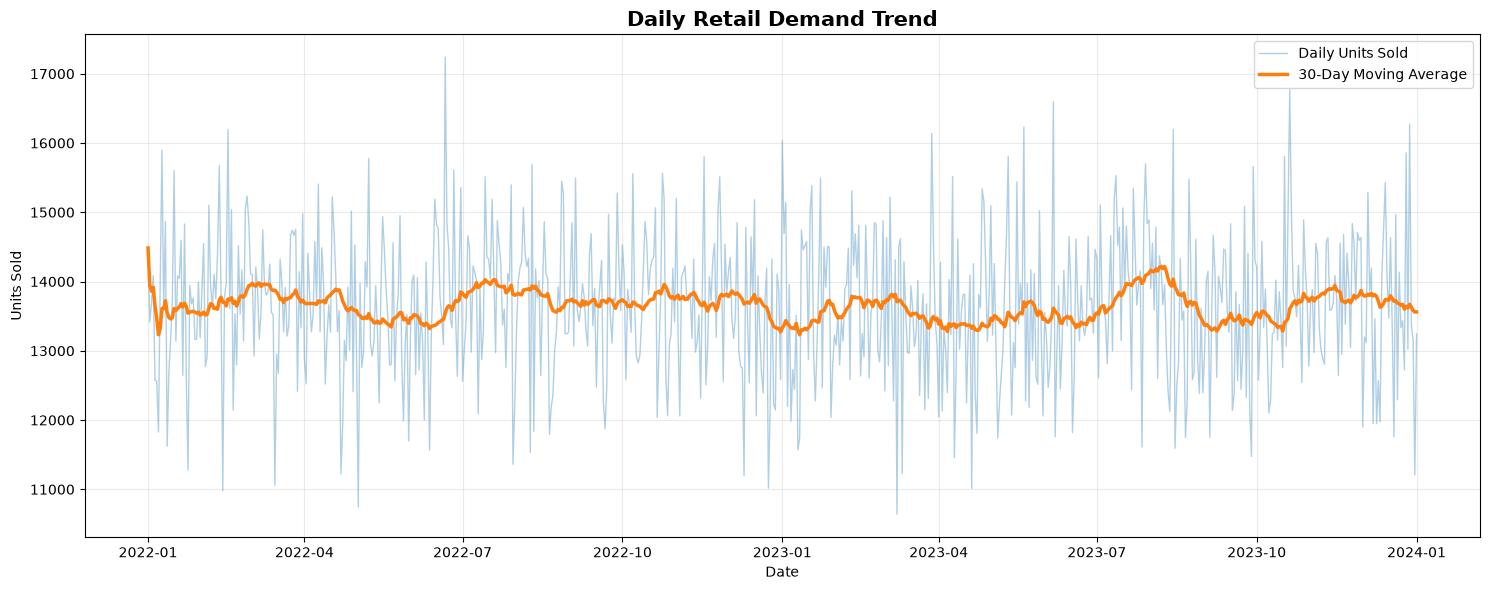

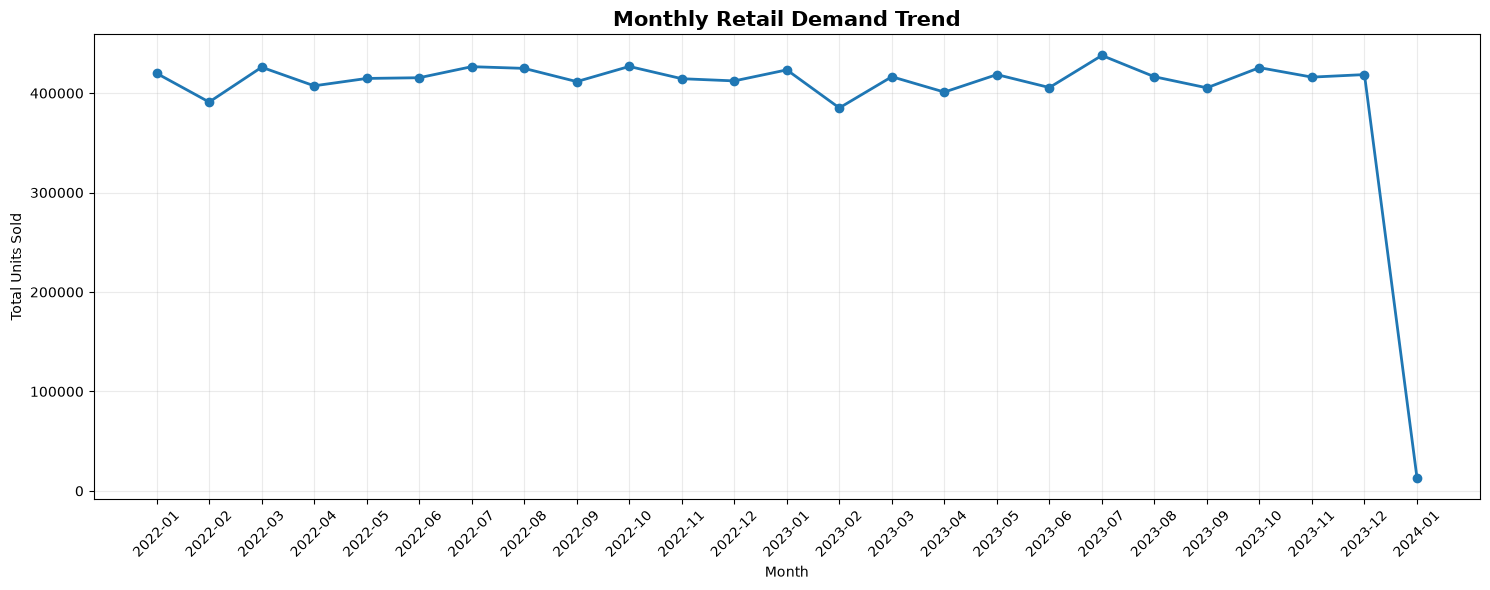


DEMAND TREND SUMMARY
---------------------------------------------------------------------------
Average daily demand          : 13,646.49 units
Highest daily demand          : 17,239 units
Highest demand date           : 2022-06-21
Lowest daily demand           : 10,642 units
Lowest demand date            : 2023-03-08
Highest full-demand month     : 2023-07 (437,919 units)
Lowest full-demand month      : 2023-02 (385,168 units)

MONTHLY DEMAND TABLE
---------------------------------------------------------------------------


,Year_Month,Units_Sold,Units_Ordered,Estimated_Net_Sales
0,2022-01,419938,340861,"20,919,532.62"
1,2022-02,391052,309042,"19,061,033.49"
2,2022-03,426073,342307,"21,522,683.07"
3,2022-04,407380,332595,"20,314,402.68"
4,2022-05,414799,339976,"20,542,562.41"
5,2022-06,415509,329740,"20,981,786.82"
6,2022-07,426628,334875,"21,293,910.20"
7,2022-08,424916,341378,"21,055,281.19"
8,2022-09,411610,329867,"20,628,910.98"
9,2022-10,426863,342970,"21,147,496.16"


In [12]:
# ============================================================
# CELL 10: DEMAND TREND ANALYSIS OVER TIME
# ============================================================

print("=" * 75)
print("DEMAND TREND ANALYSIS OVER TIME")
print("=" * 75)


# ------------------------------------------------------------
# 1. Aggregate Daily Demand
# ------------------------------------------------------------
daily_demand = (
    df_analysis
    .groupby("Date", as_index=False)
    .agg(
        Units_Sold=("Units Sold", "sum"),
        Units_Ordered=("Units Ordered", "sum")
    )
    .sort_values("Date")
)

# 30-day moving average to show the underlying trend
daily_demand["30_Day_Moving_Avg"] = (
    daily_demand["Units_Sold"]
    .rolling(window=30, min_periods=1)
    .mean()
)


# ------------------------------------------------------------
# 2. Daily Demand Visualization
# ------------------------------------------------------------
plt.figure(figsize=(15, 6))

plt.plot(
    daily_demand["Date"],
    daily_demand["Units_Sold"],
    alpha=0.35,
    linewidth=1,
    label="Daily Units Sold"
)

plt.plot(
    daily_demand["Date"],
    daily_demand["30_Day_Moving_Avg"],
    linewidth=2.5,
    label="30-Day Moving Average"
)

plt.title(
    "Daily Retail Demand Trend",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Monthly Demand Aggregation
# ------------------------------------------------------------
monthly_demand = (
    df_analysis
    .assign(
        Year_Month=df_analysis["Date"].dt.to_period("M")
    )
    .groupby("Year_Month", as_index=False)
    .agg(
        Units_Sold=("Units Sold", "sum"),
        Units_Ordered=("Units Ordered", "sum"),
        Estimated_Net_Sales=("Estimated Net Sales", "sum")
    )
)

monthly_demand["Year_Month"] = (
    monthly_demand["Year_Month"].astype(str)
)


# ------------------------------------------------------------
# 4. Monthly Demand Visualization
# ------------------------------------------------------------
plt.figure(figsize=(15, 6))

plt.plot(
    monthly_demand["Year_Month"],
    monthly_demand["Units_Sold"],
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Retail Demand Trend",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Total Units Sold")

plt.xticks(rotation=45)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Full-Month Comparison
# Exclude January 2024 because only one day exists for that month
# ------------------------------------------------------------
full_months = monthly_demand[
    monthly_demand["Year_Month"] != "2024-01"
].copy()

highest_month = full_months.loc[
    full_months["Units_Sold"].idxmax()
]

lowest_month = full_months.loc[
    full_months["Units_Sold"].idxmin()
]


# ------------------------------------------------------------
# 6. Demand Trend Summary
# ------------------------------------------------------------
print("\nDEMAND TREND SUMMARY")
print("-" * 75)

print(
    f"Average daily demand          : "
    f"{daily_demand['Units_Sold'].mean():,.2f} units"
)

print(
    f"Highest daily demand          : "
    f"{daily_demand['Units_Sold'].max():,.0f} units"
)

highest_day = daily_demand.loc[
    daily_demand["Units_Sold"].idxmax(), "Date"
]

print(
    f"Highest demand date           : "
    f"{highest_day.date()}"
)

print(
    f"Lowest daily demand           : "
    f"{daily_demand['Units_Sold'].min():,.0f} units"
)

lowest_day = daily_demand.loc[
    daily_demand["Units_Sold"].idxmin(), "Date"
]

print(
    f"Lowest demand date            : "
    f"{lowest_day.date()}"
)

print(
    f"Highest full-demand month     : "
    f"{highest_month['Year_Month']} "
    f"({highest_month['Units_Sold']:,.0f} units)"
)

print(
    f"Lowest full-demand month      : "
    f"{lowest_month['Year_Month']} "
    f"({lowest_month['Units_Sold']:,.0f} units)"
)


# ------------------------------------------------------------
# 7. Monthly Demand Table
# ------------------------------------------------------------
print("\nMONTHLY DEMAND TABLE")
print("-" * 75)

display(
    monthly_demand[
        [
            "Year_Month",
            "Units_Sold",
            "Units_Ordered",
            "Estimated_Net_Sales"
        ]
    ]
)

### Cell 11 — Normalized Monthly Demand & Year-over-Year Analysis

NORMALIZED MONTHLY DEMAND & YEAR-OVER-YEAR ANALYSIS


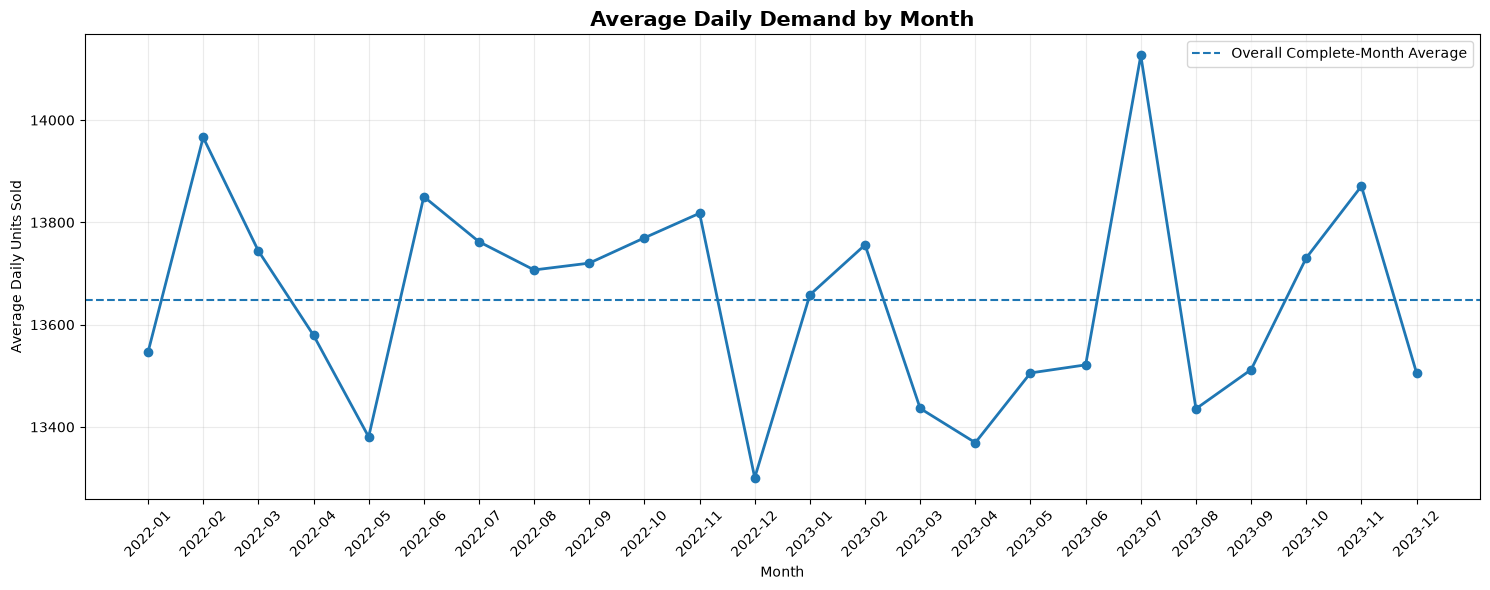


NORMALIZED MONTHLY DEMAND SUMMARY
---------------------------------------------------------------------------
Highest average-demand month : 2023-07 (14,126.42 units/day)
Lowest average-demand month  : 2022-12 (13,300.68 units/day)
Complete months analyzed     : 24
Incomplete months excluded   : 1

FULL-YEAR DEMAND COMPARISON
---------------------------------------------------------------------------


,Year,Total_Units_Sold,Total_Units_Ordered,Days_Observed,Estimated_Net_Sales,Average_Daily_Demand
0,2022,4991624,4010105,365,"248,454,874.34","13,675.68"
1,2023,4970714,4019988,365,"245,888,357.83","13,618.39"


2023 vs 2022 total demand change : -0.42%
2023 vs 2022 daily demand change : -0.42%

NORMALIZED MONTHLY TABLE
---------------------------------------------------------------------------


,Year_Month_Label,Total_Units_Sold,Days_Observed,Calendar_Days,Complete_Month,Average_Daily_Demand
0,2022-01,419938,31,31,True,"13,546.39"
1,2022-02,391052,28,28,True,"13,966.14"
2,2022-03,426073,31,31,True,"13,744.29"
3,2022-04,407380,30,30,True,"13,579.33"
4,2022-05,414799,31,31,True,"13,380.61"
5,2022-06,415509,30,30,True,"13,850.30"
6,2022-07,426628,31,31,True,"13,762.19"
7,2022-08,424916,31,31,True,"13,706.97"
8,2022-09,411610,30,30,True,"13,720.33"
9,2022-10,426863,31,31,True,"13,769.77"


In [13]:
# ============================================================
# CELL 11: NORMALIZED MONTHLY DEMAND & YEAR-OVER-YEAR ANALYSIS
# ============================================================

print("=" * 75)
print("NORMALIZED MONTHLY DEMAND & YEAR-OVER-YEAR ANALYSIS")
print("=" * 75)


# ------------------------------------------------------------
# 1. Monthly Demand with Number of Observed Days
# ------------------------------------------------------------
monthly_normalized = (
    df_analysis
    .assign(
        Year_Month=df_analysis["Date"].dt.to_period("M")
    )
    .groupby("Year_Month", as_index=False)
    .agg(
        Total_Units_Sold=("Units Sold", "sum"),
        Days_Observed=("Date", "nunique"),
        Estimated_Net_Sales=("Estimated Net Sales", "sum")
    )
)


# Number of calendar days that should exist in each month
monthly_normalized["Calendar_Days"] = (
    monthly_normalized["Year_Month"].dt.days_in_month
)


# Identify whether each month is complete
monthly_normalized["Complete_Month"] = (
    monthly_normalized["Days_Observed"]
    == monthly_normalized["Calendar_Days"]
)


# Average daily demand removes the effect of different month lengths
monthly_normalized["Average_Daily_Demand"] = (
    monthly_normalized["Total_Units_Sold"]
    / monthly_normalized["Days_Observed"]
)


# String version for plotting
monthly_normalized["Year_Month_Label"] = (
    monthly_normalized["Year_Month"].astype(str)
)


# ------------------------------------------------------------
# 2. Keep Only Complete Months for Fair Comparison
# ------------------------------------------------------------
complete_months = monthly_normalized[
    monthly_normalized["Complete_Month"]
].copy()


# ------------------------------------------------------------
# 3. Plot Normalized Monthly Demand
# ------------------------------------------------------------
plt.figure(figsize=(15, 6))

plt.plot(
    complete_months["Year_Month_Label"],
    complete_months["Average_Daily_Demand"],
    marker="o",
    linewidth=2
)

plt.axhline(
    complete_months["Average_Daily_Demand"].mean(),
    linestyle="--",
    linewidth=1.5,
    label="Overall Complete-Month Average"
)

plt.title(
    "Average Daily Demand by Month",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Average Daily Units Sold")

plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Highest and Lowest Normalized Demand Months
# ------------------------------------------------------------
highest_normalized = complete_months.loc[
    complete_months["Average_Daily_Demand"].idxmax()
]

lowest_normalized = complete_months.loc[
    complete_months["Average_Daily_Demand"].idxmin()
]


print("\nNORMALIZED MONTHLY DEMAND SUMMARY")
print("-" * 75)

print(
    f"Highest average-demand month : "
    f"{highest_normalized['Year_Month_Label']} "
    f"({highest_normalized['Average_Daily_Demand']:,.2f} units/day)"
)

print(
    f"Lowest average-demand month  : "
    f"{lowest_normalized['Year_Month_Label']} "
    f"({lowest_normalized['Average_Daily_Demand']:,.2f} units/day)"
)

print(
    f"Complete months analyzed     : "
    f"{len(complete_months)}"
)

print(
    f"Incomplete months excluded   : "
    f"{(~monthly_normalized['Complete_Month']).sum()}"
)


# ------------------------------------------------------------
# 5. Full-Year Comparison
# Only 2022 and 2023 are complete years
# ------------------------------------------------------------
full_year_data = df_analysis[
    df_analysis["Year"].isin([2022, 2023])
].copy()

yearly_summary = (
    full_year_data
    .groupby("Year", as_index=False)
    .agg(
        Total_Units_Sold=("Units Sold", "sum"),
        Total_Units_Ordered=("Units Ordered", "sum"),
        Days_Observed=("Date", "nunique"),
        Estimated_Net_Sales=("Estimated Net Sales", "sum")
    )
)

yearly_summary["Average_Daily_Demand"] = (
    yearly_summary["Total_Units_Sold"]
    / yearly_summary["Days_Observed"]
)


# ------------------------------------------------------------
# 6. Year-over-Year Change: 2023 vs 2022
# ------------------------------------------------------------
sales_2022 = yearly_summary.loc[
    yearly_summary["Year"] == 2022,
    "Total_Units_Sold"
].iloc[0]

sales_2023 = yearly_summary.loc[
    yearly_summary["Year"] == 2023,
    "Total_Units_Sold"
].iloc[0]

daily_2022 = yearly_summary.loc[
    yearly_summary["Year"] == 2022,
    "Average_Daily_Demand"
].iloc[0]

daily_2023 = yearly_summary.loc[
    yearly_summary["Year"] == 2023,
    "Average_Daily_Demand"
].iloc[0]

yoy_units_change = (
    (sales_2023 - sales_2022)
    / sales_2022
) * 100

yoy_daily_change = (
    (daily_2023 - daily_2022)
    / daily_2022
) * 100


print("\nFULL-YEAR DEMAND COMPARISON")
print("-" * 75)

display(yearly_summary)

print(
    f"2023 vs 2022 total demand change : "
    f"{yoy_units_change:+.2f}%"
)

print(
    f"2023 vs 2022 daily demand change : "
    f"{yoy_daily_change:+.2f}%"
)


# ------------------------------------------------------------
# 7. Complete Monthly Table
# ------------------------------------------------------------
print("\nNORMALIZED MONTHLY TABLE")
print("-" * 75)

display(
    monthly_normalized[
        [
            "Year_Month_Label",
            "Total_Units_Sold",
            "Days_Observed",
            "Calendar_Days",
            "Complete_Month",
            "Average_Daily_Demand"
        ]
    ]
)

### Cell 12 — Category Performance Analysis

CATEGORY PERFORMANCE ANALYSIS


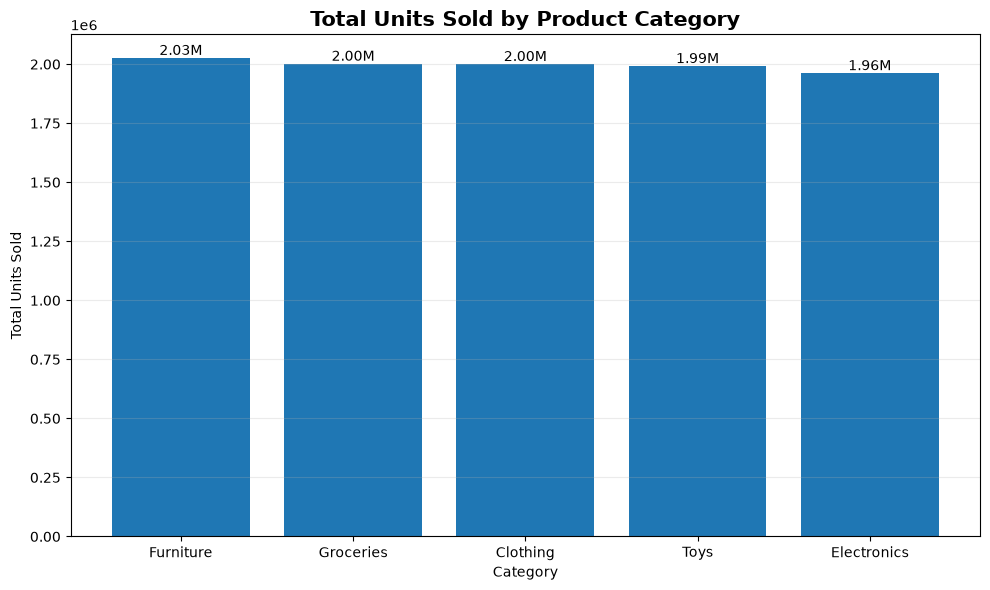

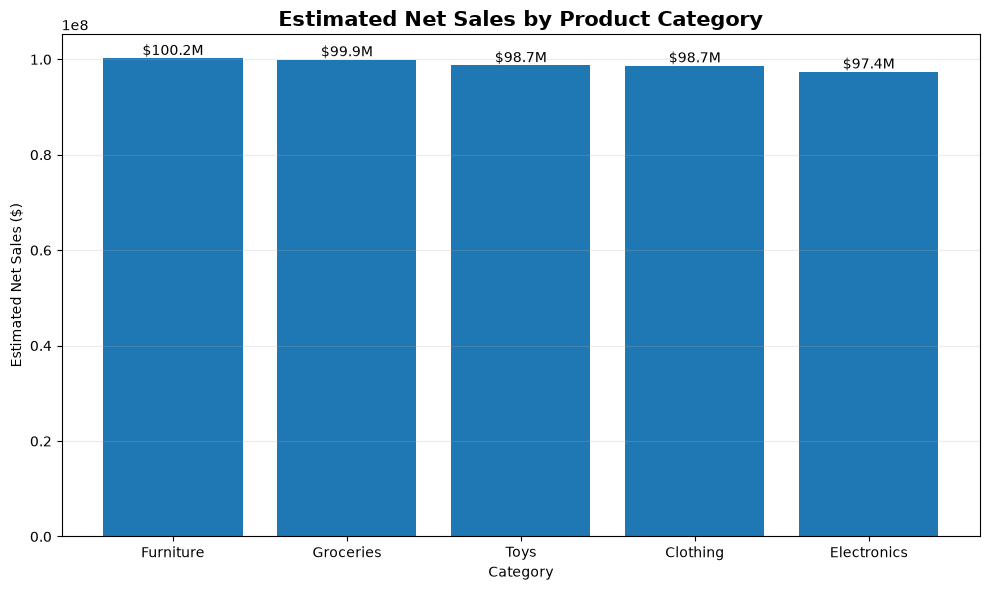


CATEGORY PERFORMANCE TABLE
---------------------------------------------------------------------------


,Category,Total_Units_Sold,Total_Units_Ordered,Average_Inventory,Estimated_Net_Sales,Average_Price,Average_Discount,Demand_Share_%,Sales_Share_%
0,Furniture,"2,025,017","1,617,699",275.82,"$100,230,824.04",$55.18,10.03%,20.30%,20.25%
1,Groceries,"2,000,482","1,606,188",275.76,"$99,948,968.32",$55.27,9.98%,20.05%,20.19%
2,Clothing,"1,999,166","1,614,885",274.60,"$98,676,779.98",$54.89,10.01%,20.04%,19.94%
3,Toys,"1,990,485","1,610,222",273.65,"$98,729,216.66",$55.03,9.99%,19.95%,19.95%
4,Electronics,"1,960,432","1,592,333",272.51,"$97,385,585.94",$55.31,10.04%,19.65%,19.67%



CATEGORY INSIGHT SUMMARY
---------------------------------------------------------------------------
Highest-demand category       : Furniture (2,025,017 units)
Lowest-demand category        : Electronics (1,960,432 units)
Highest estimated-sales category: Furniture ($100,230,824.04)
Highest average inventory     : Furniture (275.82 units)


In [14]:
# ============================================================
# CELL 12: CATEGORY PERFORMANCE ANALYSIS
# ============================================================

print("=" * 75)
print("CATEGORY PERFORMANCE ANALYSIS")
print("=" * 75)


# ------------------------------------------------------------
# 1. Aggregate Category-Level Performance
# ------------------------------------------------------------
category_performance = (
    df_analysis
    .groupby("Category", as_index=False)
    .agg(
        Total_Units_Sold=("Units Sold", "sum"),
        Total_Units_Ordered=("Units Ordered", "sum"),
        Average_Inventory=("Inventory Level", "mean"),
        Estimated_Net_Sales=("Estimated Net Sales", "sum"),
        Average_Price=("Price", "mean"),
        Average_Discount=("Discount", "mean")
    )
)


# ------------------------------------------------------------
# 2. Calculate Contribution Shares
# ------------------------------------------------------------
category_performance["Demand_Share_%"] = (
    category_performance["Total_Units_Sold"]
    / category_performance["Total_Units_Sold"].sum()
    * 100
)

category_performance["Sales_Share_%"] = (
    category_performance["Estimated_Net_Sales"]
    / category_performance["Estimated_Net_Sales"].sum()
    * 100
)


# ------------------------------------------------------------
# 3. Sort by Demand
# ------------------------------------------------------------
category_performance = (
    category_performance
    .sort_values(
        "Total_Units_Sold",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 4. Category Demand Chart
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

bars = plt.bar(
    category_performance["Category"],
    category_performance["Total_Units_Sold"]
)

plt.title(
    "Total Units Sold by Product Category",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Category")
plt.ylabel("Total Units Sold")

plt.grid(
    axis="y",
    alpha=0.25
)

# Add values above bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height / 1_000_000:.2f}M",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Estimated Net Sales Chart
# ------------------------------------------------------------
sales_sorted = category_performance.sort_values(
    "Estimated_Net_Sales",
    ascending=False
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    sales_sorted["Category"],
    sales_sorted["Estimated_Net_Sales"]
)

plt.title(
    "Estimated Net Sales by Product Category",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Category")
plt.ylabel("Estimated Net Sales ($)")

plt.grid(
    axis="y",
    alpha=0.25
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"${height / 1_000_000:.1f}M",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Category Performance Table
# ------------------------------------------------------------
print("\nCATEGORY PERFORMANCE TABLE")
print("-" * 75)

display(
    category_performance.style.format({
        "Total_Units_Sold": "{:,.0f}",
        "Total_Units_Ordered": "{:,.0f}",
        "Average_Inventory": "{:,.2f}",
        "Estimated_Net_Sales": "${:,.2f}",
        "Average_Price": "${:,.2f}",
        "Average_Discount": "{:.2f}%",
        "Demand_Share_%": "{:.2f}%",
        "Sales_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 7. Identify Category Leaders
# ------------------------------------------------------------
top_demand_category = category_performance.loc[
    category_performance["Total_Units_Sold"].idxmax()
]

lowest_demand_category = category_performance.loc[
    category_performance["Total_Units_Sold"].idxmin()
]

top_sales_category = category_performance.loc[
    category_performance["Estimated_Net_Sales"].idxmax()
]

highest_inventory_category = category_performance.loc[
    category_performance["Average_Inventory"].idxmax()
]


print("\nCATEGORY INSIGHT SUMMARY")
print("-" * 75)

print(
    f"Highest-demand category       : "
    f"{top_demand_category['Category']} "
    f"({top_demand_category['Total_Units_Sold']:,.0f} units)"
)

print(
    f"Lowest-demand category        : "
    f"{lowest_demand_category['Category']} "
    f"({lowest_demand_category['Total_Units_Sold']:,.0f} units)"
)

print(
    f"Highest estimated-sales category: "
    f"{top_sales_category['Category']} "
    f"(${top_sales_category['Estimated_Net_Sales']:,.2f})"
)

print(
    f"Highest average inventory     : "
    f"{highest_inventory_category['Category']} "
    f"({highest_inventory_category['Average_Inventory']:,.2f} units)"
)

### Cell 13 — Product Structure & Product Performance Analysis

PRODUCT STRUCTURE & PRODUCT PERFORMANCE ANALYSIS

PRODUCT STRUCTURE CHECK
---------------------------------------------------------------------------
Total unique Product IDs             : 20
Products linked to >1 category       : 20
Maximum categories for one Product ID: 5


,Product ID,Unique_Categories,Unique_Regions
0,P0001,5,4
1,P0002,5,4
2,P0003,5,4
3,P0004,5,4
4,P0005,5,4
5,P0006,5,4
6,P0007,5,4
7,P0008,5,4
8,P0009,5,4
9,P0010,5,4


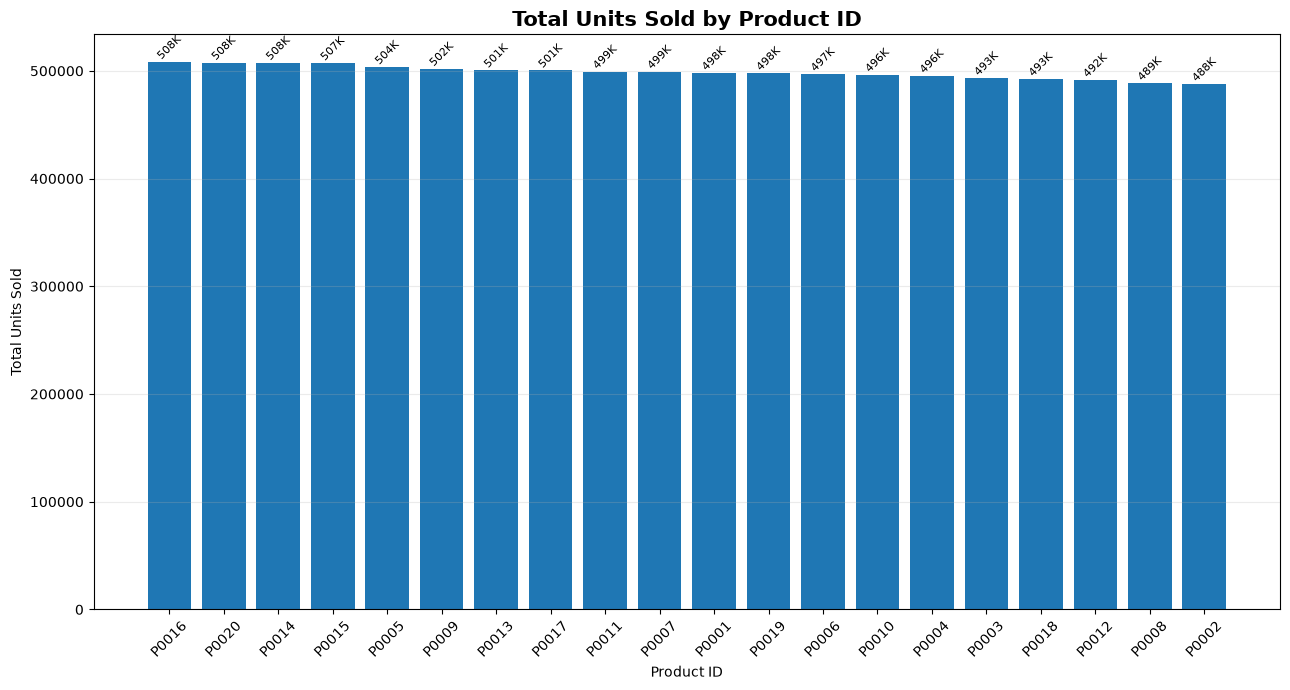


TOP 5 PRODUCTS BY DEMAND
---------------------------------------------------------------------------


,Demand_Rank,Product ID,Total_Units_Sold,Demand_Share_%,Estimated_Net_Sales,Average_Inventory
0,1,P0016,"508,472",5.10%,"$25,319,508.16",277.51
1,2,P0020,"507,708",5.09%,"$25,502,319.53",276.80
2,3,P0014,"507,622",5.09%,"$25,268,814.93",277.89
3,4,P0015,"507,283",5.09%,"$24,946,850.89",276.41
4,5,P0005,"503,648",5.05%,"$25,164,517.37",273.04



BOTTOM 5 PRODUCTS BY DEMAND
---------------------------------------------------------------------------


,Demand_Rank,Product ID,Total_Units_Sold,Demand_Share_%,Estimated_Net_Sales,Average_Inventory
19,20,P0002,"487,827",4.89%,"$24,166,487.24",271.15
18,19,P0008,"488,563",4.90%,"$24,220,929.18",272.77
17,18,P0012,"491,670",4.93%,"$24,105,234.94",272.51
16,17,P0018,"492,551",4.94%,"$24,483,516.15",272.54
15,16,P0003,"493,279",4.94%,"$24,364,478.70",274.93



COMPLETE PRODUCT PERFORMANCE TABLE
---------------------------------------------------------------------------


,Product ID,Total_Units_Sold,Total_Units_Ordered,Average_Inventory,Estimated_Net_Sales,Average_Price,Average_Discount,Demand_Share_%,Sales_Share_%,Demand_Rank
0,P0016,"508,472","403,376",277.51,"$25,319,508.16",$54.83,10.03%,5.10%,5.12%,1
1,P0020,"507,708","407,810",276.80,"$25,502,319.53",$55.52,9.93%,5.09%,5.15%,2
2,P0014,"507,622","402,485",277.89,"$25,268,814.93",$55.76,9.98%,5.09%,5.11%,3
3,P0015,"507,283","400,720",276.41,"$24,946,850.89",$54.77,9.98%,5.09%,5.04%,4
4,P0005,"503,648","400,964",273.04,"$25,164,517.37",$55.02,9.87%,5.05%,5.08%,5
5,P0009,"502,086","398,726",275.32,"$24,829,627.13",$55.16,10.22%,5.03%,5.02%,6
6,P0013,"500,619","405,275",275.11,"$25,117,342.08",$55.06,10.02%,5.02%,5.07%,7
7,P0017,"500,510","403,335",278.32,"$24,330,052.91",$54.65,10.00%,5.02%,4.92%,8
8,P0011,"499,362","400,625",272.81,"$25,456,723.62",$56.43,9.62%,5.01%,5.14%,9
9,P0007,"499,321","397,638",274.71,"$24,782,959.75",$54.92,10.11%,5.01%,5.01%,10



PRODUCT INSIGHT SUMMARY
---------------------------------------------------------------------------
Highest-demand Product ID : P0016 (508,472 units, 5.10% share)
Lowest-demand Product ID  : P0002 (487,827 units, 4.89% share)
Top-to-bottom demand gap  : 4.23%


In [15]:
# ============================================================
# CELL 13: PRODUCT STRUCTURE & PRODUCT PERFORMANCE ANALYSIS
# ============================================================

print("=" * 75)
print("PRODUCT STRUCTURE & PRODUCT PERFORMANCE ANALYSIS")
print("=" * 75)


# ------------------------------------------------------------
# 1. Check Product-to-Category Relationship
# ------------------------------------------------------------
product_category_check = (
    df_analysis
    .groupby("Product ID")
    .agg(
        Unique_Categories=("Category", "nunique"),
        Unique_Regions=("Region", "nunique")
    )
    .reset_index()
)

print("\nPRODUCT STRUCTURE CHECK")
print("-" * 75)

print(
    f"Total unique Product IDs             : "
    f"{df_analysis['Product ID'].nunique():,}"
)

print(
    f"Products linked to >1 category       : "
    f"{(product_category_check['Unique_Categories'] > 1).sum():,}"
)

print(
    f"Maximum categories for one Product ID: "
    f"{product_category_check['Unique_Categories'].max():,}"
)

display(product_category_check)


# ------------------------------------------------------------
# 2. Aggregate Product Performance
# ------------------------------------------------------------
product_performance = (
    df_analysis
    .groupby("Product ID", as_index=False)
    .agg(
        Total_Units_Sold=("Units Sold", "sum"),
        Total_Units_Ordered=("Units Ordered", "sum"),
        Average_Inventory=("Inventory Level", "mean"),
        Estimated_Net_Sales=("Estimated Net Sales", "sum"),
        Average_Price=("Price", "mean"),
        Average_Discount=("Discount", "mean")
    )
)


# ------------------------------------------------------------
# 3. Contribution Shares
# ------------------------------------------------------------
product_performance["Demand_Share_%"] = (
    product_performance["Total_Units_Sold"]
    / product_performance["Total_Units_Sold"].sum()
    * 100
)

product_performance["Sales_Share_%"] = (
    product_performance["Estimated_Net_Sales"]
    / product_performance["Estimated_Net_Sales"].sum()
    * 100
)


# ------------------------------------------------------------
# 4. Rank Products by Demand
# ------------------------------------------------------------
product_performance = (
    product_performance
    .sort_values(
        "Total_Units_Sold",
        ascending=False
    )
    .reset_index(drop=True)
)

product_performance["Demand_Rank"] = (
    product_performance["Total_Units_Sold"]
    .rank(method="dense", ascending=False)
    .astype(int)
)


# ------------------------------------------------------------
# 5. Product Demand Chart
# ------------------------------------------------------------
plt.figure(figsize=(13, 7))

bars = plt.bar(
    product_performance["Product ID"],
    product_performance["Total_Units_Sold"]
)

plt.title(
    "Total Units Sold by Product ID",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Product ID")
plt.ylabel("Total Units Sold")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height / 1000:.0f}K",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=45
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Top 5 vs Bottom 5 Products
# ------------------------------------------------------------
top_5_products = product_performance.head(5)

bottom_5_products = (
    product_performance
    .tail(5)
    .sort_values("Total_Units_Sold")
)


print("\nTOP 5 PRODUCTS BY DEMAND")
print("-" * 75)

display(
    top_5_products[
        [
            "Demand_Rank",
            "Product ID",
            "Total_Units_Sold",
            "Demand_Share_%",
            "Estimated_Net_Sales",
            "Average_Inventory"
        ]
    ].style.format({
        "Total_Units_Sold": "{:,.0f}",
        "Demand_Share_%": "{:.2f}%",
        "Estimated_Net_Sales": "${:,.2f}",
        "Average_Inventory": "{:,.2f}"
    })
)


print("\nBOTTOM 5 PRODUCTS BY DEMAND")
print("-" * 75)

display(
    bottom_5_products[
        [
            "Demand_Rank",
            "Product ID",
            "Total_Units_Sold",
            "Demand_Share_%",
            "Estimated_Net_Sales",
            "Average_Inventory"
        ]
    ].style.format({
        "Total_Units_Sold": "{:,.0f}",
        "Demand_Share_%": "{:.2f}%",
        "Estimated_Net_Sales": "${:,.2f}",
        "Average_Inventory": "{:,.2f}"
    })
)


# ------------------------------------------------------------
# 7. Complete Product Performance Table
# ------------------------------------------------------------
print("\nCOMPLETE PRODUCT PERFORMANCE TABLE")
print("-" * 75)

display(
    product_performance.style.format({
        "Total_Units_Sold": "{:,.0f}",
        "Total_Units_Ordered": "{:,.0f}",
        "Average_Inventory": "{:,.2f}",
        "Estimated_Net_Sales": "${:,.2f}",
        "Average_Price": "${:,.2f}",
        "Average_Discount": "{:.2f}%",
        "Demand_Share_%": "{:.2f}%",
        "Sales_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 8. Product Performance Summary
# ------------------------------------------------------------
top_product = product_performance.iloc[0]
bottom_product = product_performance.iloc[-1]

print("\nPRODUCT INSIGHT SUMMARY")
print("-" * 75)

print(
    f"Highest-demand Product ID : "
    f"{top_product['Product ID']} "
    f"({top_product['Total_Units_Sold']:,.0f} units, "
    f"{top_product['Demand_Share_%']:.2f}% share)"
)

print(
    f"Lowest-demand Product ID  : "
    f"{bottom_product['Product ID']} "
    f"({bottom_product['Total_Units_Sold']:,.0f} units, "
    f"{bottom_product['Demand_Share_%']:.2f}% share)"
)

product_gap = (
    (top_product["Total_Units_Sold"] - bottom_product["Total_Units_Sold"])
    / bottom_product["Total_Units_Sold"]
    * 100
)

print(
    f"Top-to-bottom demand gap  : "
    f"{product_gap:.2f}%"
)

### Cell 14 — Store & Regional Performance Analysis

STORE & REGIONAL PERFORMANCE ANALYSIS


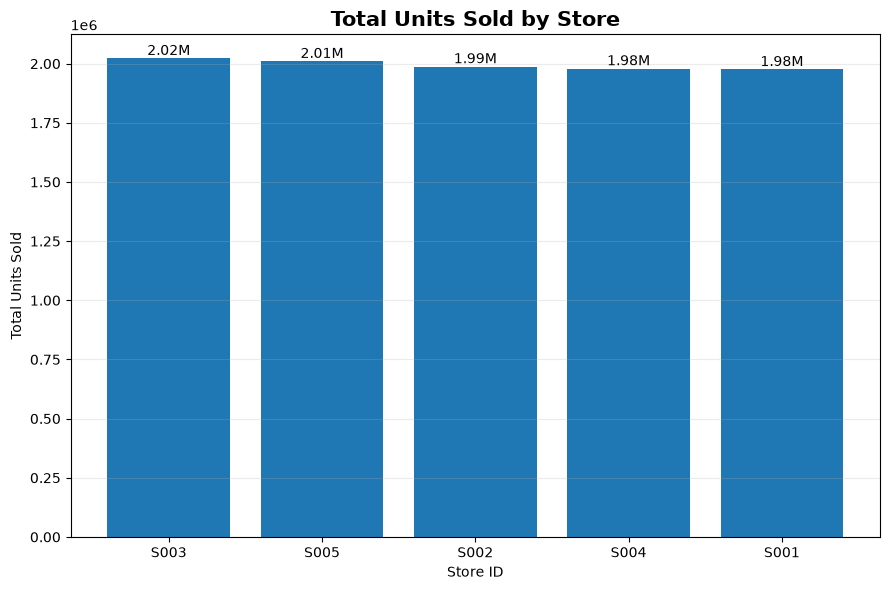


STORE PERFORMANCE TABLE
---------------------------------------------------------------------------


,Store ID,Total_Units_Sold,Total_Units_Ordered,Average_Inventory,Estimated_Net_Sales,Average_Price,Average_Discount,Demand_Share_%,Sales_Share_%
0,S003,"2,022,696","1,605,039",276.87,"$100,034,402.46",$55.08,10.11%,20.28%,20.21%
1,S005,"2,010,176","1,608,902",276.50,"$100,503,639.43",$55.25,9.97%,20.15%,20.30%
2,S002,"1,987,715","1,605,169",273.33,"$98,950,004.10",$55.11,10.04%,19.93%,19.99%
3,S004,"1,979,245","1,608,340",272.30,"$98,057,140.26",$55.12,10.01%,19.84%,19.81%
4,S001,"1,975,750","1,613,877",273.34,"$97,426,188.70",$55.11,9.92%,19.81%,19.68%


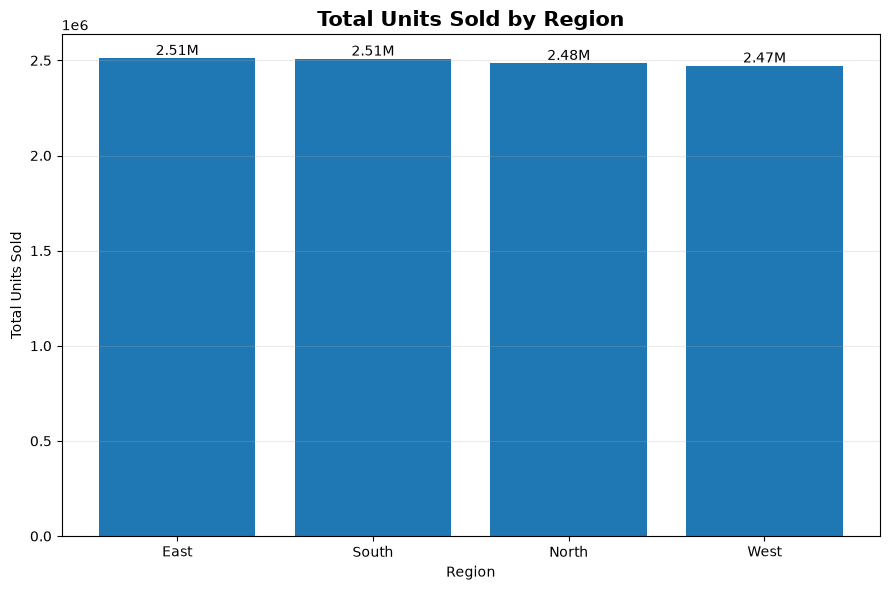


REGIONAL PERFORMANCE TABLE
---------------------------------------------------------------------------


,Region,Total_Units_Sold,Total_Units_Ordered,Average_Inventory,Estimated_Net_Sales,Average_Price,Average_Discount,Demand_Share_%,Sales_Share_%
0,East,"2,511,265","2,017,919",275.29,"$124,792,242.69",$55.18,10.04%,25.17%,25.21%
1,South,"2,507,799","2,015,826",275.31,"$124,567,388.37",$55.04,9.99%,25.14%,25.17%
2,North,"2,484,966","1,997,677",274.80,"$123,543,662.35",$55.32,10.01%,24.91%,24.96%
3,West,"2,471,552","2,009,905",272.47,"$122,068,081.53",$55.00,9.99%,24.78%,24.66%



STORE & REGION INSIGHT SUMMARY
---------------------------------------------------------------------------
Highest-demand store     : S003 (2,022,696 units)
Lowest-demand store      : S001 (1,975,750 units)
Store demand gap         : 2.38%

Highest-demand region    : East (2,511,265 units)
Lowest-demand region     : West (2,471,552 units)
Regional demand gap      : 1.61%


In [16]:
# ============================================================
# CELL 14: STORE & REGIONAL PERFORMANCE ANALYSIS
# ============================================================

print("=" * 75)
print("STORE & REGIONAL PERFORMANCE ANALYSIS")
print("=" * 75)


# ------------------------------------------------------------
# 1. Store-Level Performance
# ------------------------------------------------------------
store_performance = (
    df_analysis
    .groupby("Store ID", as_index=False)
    .agg(
        Total_Units_Sold=("Units Sold", "sum"),
        Total_Units_Ordered=("Units Ordered", "sum"),
        Average_Inventory=("Inventory Level", "mean"),
        Estimated_Net_Sales=("Estimated Net Sales", "sum"),
        Average_Price=("Price", "mean"),
        Average_Discount=("Discount", "mean")
    )
)

store_performance["Demand_Share_%"] = (
    store_performance["Total_Units_Sold"]
    / store_performance["Total_Units_Sold"].sum()
    * 100
)

store_performance["Sales_Share_%"] = (
    store_performance["Estimated_Net_Sales"]
    / store_performance["Estimated_Net_Sales"].sum()
    * 100
)

store_performance = (
    store_performance
    .sort_values("Total_Units_Sold", ascending=False)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 2. Store Demand Chart
# ------------------------------------------------------------
plt.figure(figsize=(9, 6))

bars = plt.bar(
    store_performance["Store ID"],
    store_performance["Total_Units_Sold"]
)

plt.title(
    "Total Units Sold by Store",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Store ID")
plt.ylabel("Total Units Sold")
plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height / 1_000_000:.2f}M",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Store Performance Table
# ------------------------------------------------------------
print("\nSTORE PERFORMANCE TABLE")
print("-" * 75)

display(
    store_performance.style.format({
        "Total_Units_Sold": "{:,.0f}",
        "Total_Units_Ordered": "{:,.0f}",
        "Average_Inventory": "{:,.2f}",
        "Estimated_Net_Sales": "${:,.2f}",
        "Average_Price": "${:,.2f}",
        "Average_Discount": "{:.2f}%",
        "Demand_Share_%": "{:.2f}%",
        "Sales_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 4. Regional Performance
# ------------------------------------------------------------
region_performance = (
    df_analysis
    .groupby("Region", as_index=False)
    .agg(
        Total_Units_Sold=("Units Sold", "sum"),
        Total_Units_Ordered=("Units Ordered", "sum"),
        Average_Inventory=("Inventory Level", "mean"),
        Estimated_Net_Sales=("Estimated Net Sales", "sum"),
        Average_Price=("Price", "mean"),
        Average_Discount=("Discount", "mean")
    )
)

region_performance["Demand_Share_%"] = (
    region_performance["Total_Units_Sold"]
    / region_performance["Total_Units_Sold"].sum()
    * 100
)

region_performance["Sales_Share_%"] = (
    region_performance["Estimated_Net_Sales"]
    / region_performance["Estimated_Net_Sales"].sum()
    * 100
)

region_performance = (
    region_performance
    .sort_values("Total_Units_Sold", ascending=False)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. Regional Demand Chart
# ------------------------------------------------------------
plt.figure(figsize=(9, 6))

bars = plt.bar(
    region_performance["Region"],
    region_performance["Total_Units_Sold"]
)

plt.title(
    "Total Units Sold by Region",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Region")
plt.ylabel("Total Units Sold")
plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height / 1_000_000:.2f}M",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Regional Performance Table
# ------------------------------------------------------------
print("\nREGIONAL PERFORMANCE TABLE")
print("-" * 75)

display(
    region_performance.style.format({
        "Total_Units_Sold": "{:,.0f}",
        "Total_Units_Ordered": "{:,.0f}",
        "Average_Inventory": "{:,.2f}",
        "Estimated_Net_Sales": "${:,.2f}",
        "Average_Price": "${:,.2f}",
        "Average_Discount": "{:.2f}%",
        "Demand_Share_%": "{:.2f}%",
        "Sales_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 7. Store & Region Insight Summary
# ------------------------------------------------------------
top_store = store_performance.iloc[0]
bottom_store = store_performance.iloc[-1]

top_region = region_performance.iloc[0]
bottom_region = region_performance.iloc[-1]


store_gap = (
    (top_store["Total_Units_Sold"]
     - bottom_store["Total_Units_Sold"])
    / bottom_store["Total_Units_Sold"]
    * 100
)

region_gap = (
    (top_region["Total_Units_Sold"]
     - bottom_region["Total_Units_Sold"])
    / bottom_region["Total_Units_Sold"]
    * 100
)


print("\nSTORE & REGION INSIGHT SUMMARY")
print("-" * 75)

print(
    f"Highest-demand store     : "
    f"{top_store['Store ID']} "
    f"({top_store['Total_Units_Sold']:,.0f} units)"
)

print(
    f"Lowest-demand store      : "
    f"{bottom_store['Store ID']} "
    f"({bottom_store['Total_Units_Sold']:,.0f} units)"
)

print(
    f"Store demand gap         : "
    f"{store_gap:.2f}%"
)

print(
    f"\nHighest-demand region    : "
    f"{top_region['Region']} "
    f"({top_region['Total_Units_Sold']:,.0f} units)"
)

print(
    f"Lowest-demand region     : "
    f"{bottom_region['Region']} "
    f"({bottom_region['Total_Units_Sold']:,.0f} units)"
)

print(
    f"Regional demand gap      : "
    f"{region_gap:.2f}%"
)

### Cell 15 — Inventory Efficiency & Demand Coverage Analysis

INVENTORY EFFICIENCY & DEMAND COVERAGE ANALYSIS

OVERALL INVENTORY SUMMARY
---------------------------------------------------------------------------


,Metric,Value
0,Average Inventory Level,274.47
1,Average Daily Units Sold per Record,136.46
2,Average Units Ordered,110.00
3,Median Inventory Level,273.00
4,Median Units Sold,107.00
5,Maximum Inventory Level,500.00
6,Maximum Units Sold,499.00



INVENTORY RELATIONSHIPS
---------------------------------------------------------------------------
Correlation: Inventory Level vs Units Sold : 0.5900
Correlation: Units Ordered vs Units Sold   : -0.0009


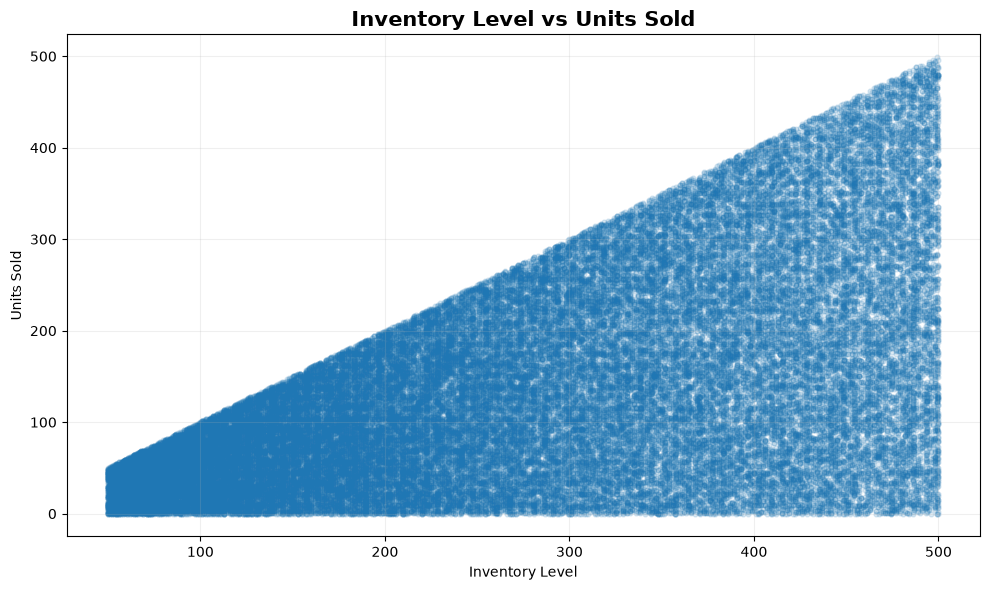


INVENTORY-TO-SALES COVERAGE RATIO
---------------------------------------------------------------------------


,Inventory_to_Sales_Ratio
count,"72,740.00"
mean,6.17
std,21.06
min,1.00
10%,1.11
25%,1.33
50%,2.01
75%,4.00
90%,9.78
95%,19.20



INVENTORY COVERAGE BAND SUMMARY
---------------------------------------------------------------------------


,Inventory Coverage Band,Records,Average_Inventory,Average_Units_Sold,Average_Units_Ordered,Record_Share_%
0,High Coverage,"18,116",277.05,34.95,109.73,24.78%
1,Low Coverage,"18,136",273.80,239.83,110.06,24.81%
2,Moderate Coverage,"36,488",274.22,136.84,110.13,49.92%
3,Undefined (Zero Sales),360,203.69,0.00,108.23,0.49%


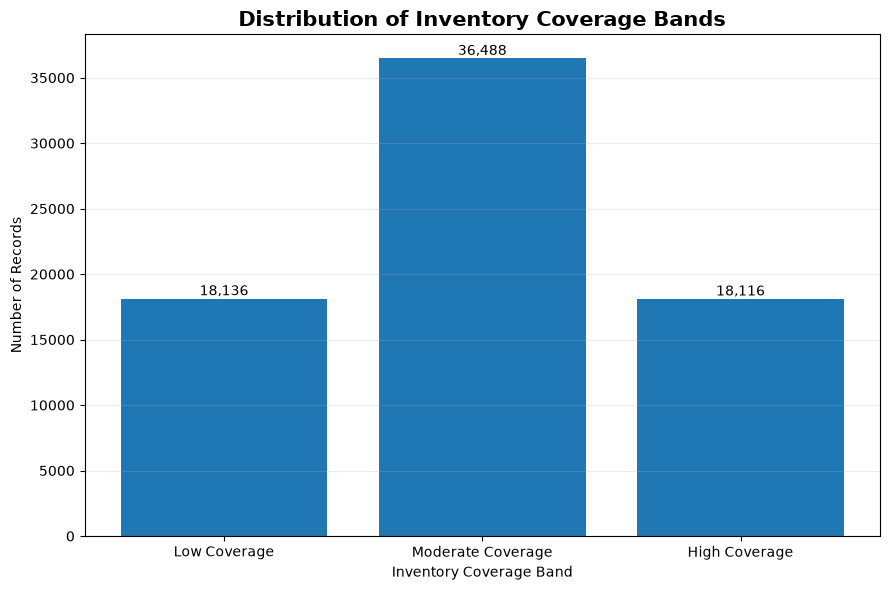


COVERAGE THRESHOLDS
---------------------------------------------------------------------------
25th percentile threshold : 1.33
75th percentile threshold : 4.00

Interpretation:
Low Coverage      : ratio < 1.33
Moderate Coverage : 1.33 to 4.00
High Coverage     : ratio > 4.00
Undefined        : Units Sold = 0


In [17]:
# ============================================================
# CELL 15: INVENTORY EFFICIENCY & DEMAND COVERAGE ANALYSIS
# ============================================================

print("=" * 75)
print("INVENTORY EFFICIENCY & DEMAND COVERAGE ANALYSIS")
print("=" * 75)


# ------------------------------------------------------------
# 1. Overall Inventory vs Demand Statistics
# ------------------------------------------------------------
inventory_summary = pd.DataFrame({
    "Metric": [
        "Average Inventory Level",
        "Average Daily Units Sold per Record",
        "Average Units Ordered",
        "Median Inventory Level",
        "Median Units Sold",
        "Maximum Inventory Level",
        "Maximum Units Sold"
    ],
    "Value": [
        df_analysis["Inventory Level"].mean(),
        df_analysis["Units Sold"].mean(),
        df_analysis["Units Ordered"].mean(),
        df_analysis["Inventory Level"].median(),
        df_analysis["Units Sold"].median(),
        df_analysis["Inventory Level"].max(),
        df_analysis["Units Sold"].max()
    ]
})

print("\nOVERALL INVENTORY SUMMARY")
print("-" * 75)

display(
    inventory_summary.style.format({
        "Value": "{:,.2f}"
    })
)


# ------------------------------------------------------------
# 2. Inventory-to-Demand Relationship
# ------------------------------------------------------------
inventory_demand_corr = (
    df_analysis["Inventory Level"]
    .corr(df_analysis["Units Sold"])
)

ordered_demand_corr = (
    df_analysis["Units Ordered"]
    .corr(df_analysis["Units Sold"])
)

print("\nINVENTORY RELATIONSHIPS")
print("-" * 75)

print(
    f"Correlation: Inventory Level vs Units Sold : "
    f"{inventory_demand_corr:.4f}"
)

print(
    f"Correlation: Units Ordered vs Units Sold   : "
    f"{ordered_demand_corr:.4f}"
)


# ------------------------------------------------------------
# 3. Scatter Plot: Inventory vs Units Sold
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.scatter(
    df_analysis["Inventory Level"],
    df_analysis["Units Sold"],
    alpha=0.15,
    s=12
)

plt.title(
    "Inventory Level vs Units Sold",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Inventory Level")
plt.ylabel("Units Sold")

plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Daily Coverage Ratio
#
# Interpretation:
# Inventory Level / Units Sold
#
# We exclude zero-sales records because their coverage ratio
# is undefined rather than infinite.
# ------------------------------------------------------------
valid_coverage = df_analysis[
    df_analysis["Units Sold"] > 0
].copy()

coverage_stats = (
    valid_coverage["Inventory to Sales Ratio"]
    .describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

print("\nINVENTORY-TO-SALES COVERAGE RATIO")
print("-" * 75)

display(
    coverage_stats.to_frame(
        name="Inventory_to_Sales_Ratio"
    )
)


# ------------------------------------------------------------
# 5. Create Data-Driven Coverage Bands
#
# These are descriptive analytical bands based on the
# distribution of this dataset, NOT universal industry rules.
# ------------------------------------------------------------
q25 = valid_coverage[
    "Inventory to Sales Ratio"
].quantile(0.25)

q75 = valid_coverage[
    "Inventory to Sales Ratio"
].quantile(0.75)


def classify_inventory_coverage(ratio):
    if pd.isna(ratio):
        return "Undefined (Zero Sales)"
    elif ratio < q25:
        return "Low Coverage"
    elif ratio <= q75:
        return "Moderate Coverage"
    else:
        return "High Coverage"


df_analysis["Inventory Coverage Band"] = (
    df_analysis["Inventory to Sales Ratio"]
    .apply(classify_inventory_coverage)
)


# ------------------------------------------------------------
# 6. Coverage Band Summary
# ------------------------------------------------------------
coverage_band_summary = (
    df_analysis
    .groupby(
        "Inventory Coverage Band",
        as_index=False
    )
    .agg(
        Records=("Inventory Coverage Band", "size"),
        Average_Inventory=("Inventory Level", "mean"),
        Average_Units_Sold=("Units Sold", "mean"),
        Average_Units_Ordered=("Units Ordered", "mean")
    )
)

coverage_band_summary["Record_Share_%"] = (
    coverage_band_summary["Records"]
    / len(df_analysis)
    * 100
)


print("\nINVENTORY COVERAGE BAND SUMMARY")
print("-" * 75)

display(
    coverage_band_summary.style.format({
        "Records": "{:,.0f}",
        "Average_Inventory": "{:,.2f}",
        "Average_Units_Sold": "{:,.2f}",
        "Average_Units_Ordered": "{:,.2f}",
        "Record_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 7. Coverage Band Visualization
# ------------------------------------------------------------
coverage_plot = (
    coverage_band_summary[
        coverage_band_summary[
            "Inventory Coverage Band"
        ] != "Undefined (Zero Sales)"
    ]
    .copy()
)

coverage_order = [
    "Low Coverage",
    "Moderate Coverage",
    "High Coverage"
]

coverage_plot["Inventory Coverage Band"] = pd.Categorical(
    coverage_plot["Inventory Coverage Band"],
    categories=coverage_order,
    ordered=True
)

coverage_plot = coverage_plot.sort_values(
    "Inventory Coverage Band"
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    coverage_plot["Inventory Coverage Band"],
    coverage_plot["Records"]
)

plt.title(
    "Distribution of Inventory Coverage Bands",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Inventory Coverage Band")
plt.ylabel("Number of Records")
plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Print Data-Driven Thresholds
# ------------------------------------------------------------
print("\nCOVERAGE THRESHOLDS")
print("-" * 75)

print(
    f"25th percentile threshold : "
    f"{q25:.2f}"
)

print(
    f"75th percentile threshold : "
    f"{q75:.2f}"
)

print(
    "\nInterpretation:"
)

print(
    f"Low Coverage      : ratio < {q25:.2f}"
)

print(
    f"Moderate Coverage : {q25:.2f} to {q75:.2f}"
)

print(
    f"High Coverage     : ratio > {q75:.2f}"
)

print(
    "Undefined        : Units Sold = 0"
)

### Cell 16 — Pricing, Discount & Promotion Analysis

PRICING, DISCOUNT & PROMOTION ANALYSIS

PERFORMANCE BY DISCOUNT LEVEL
---------------------------------------------------------------------------


,Discount,Records,Average_Units_Sold,Total_Units_Sold,Average_Price,Average_Effective_Price,Estimated_Net_Sales
0,0,"14,662",135.69,"1,989,554",$55.07,$55.07,"$109,459,609.78"
1,5,"14,591",136.57,"1,992,655",$55.23,$52.47,"$104,654,715.54"
2,10,"14,508",136.77,"1,984,257",$54.95,$49.46,"$97,709,231.90"
3,15,"14,624",136.66,"1,998,447",$55.19,$46.91,"$93,760,694.55"
4,20,"14,715",136.64,"2,010,669",$55.23,$44.19,"$89,387,123.18"


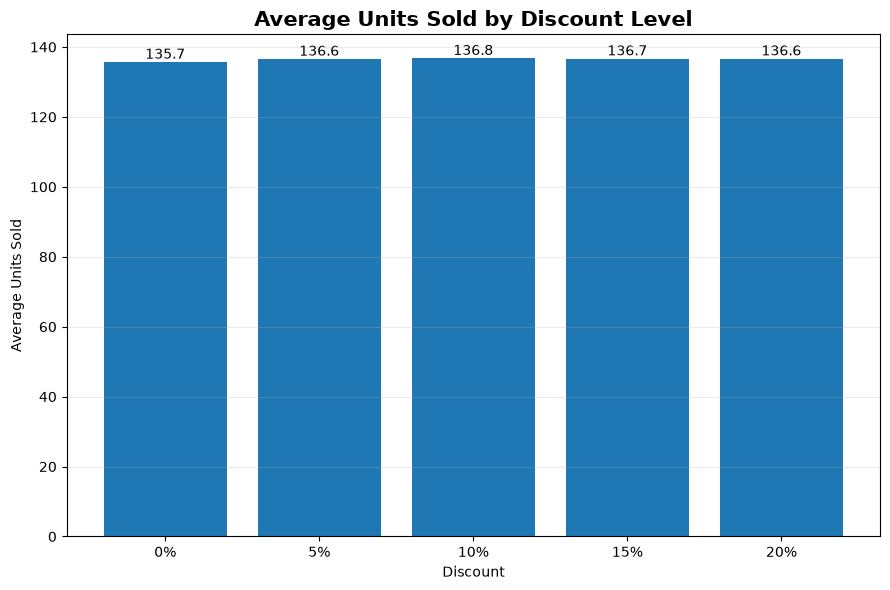


PROMOTION / HOLIDAY PERFORMANCE
---------------------------------------------------------------------------


,Status,Records,Average_Units_Sold,Total_Units_Sold,Average_Discount,Average_Price,Estimated_Net_Sales
0,No Promotion/Holiday,"36,747",136.51,"5,016,163",10.02%,$55.08,"$248,749,314.83"
1,Promotion/Holiday,"36,353",136.42,"4,959,419",10.00%,$55.20,"$246,222,060.12"


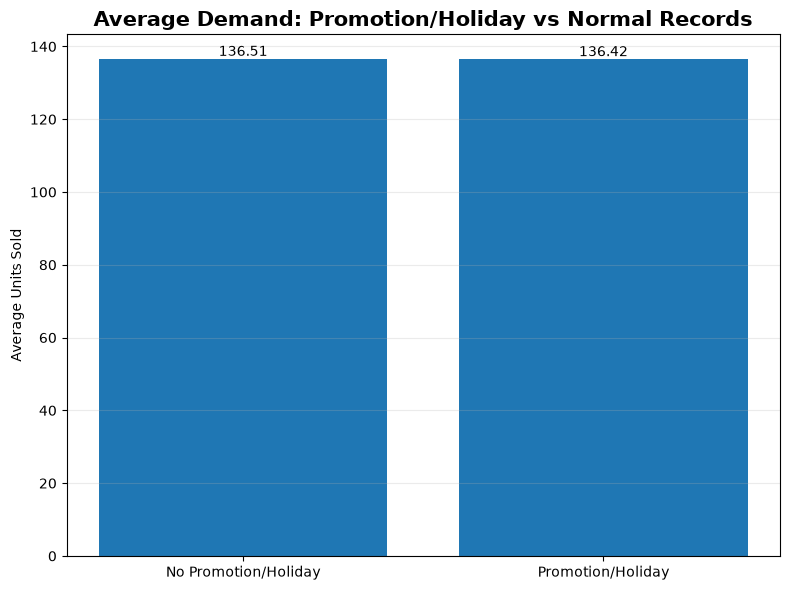


COMPETITOR PRICING POSITION
---------------------------------------------------------------------------


,Price Position,Records,Average_Units_Sold,Total_Units_Sold,Average_Price,Average_Competitor_Price,Estimated_Net_Sales,Record_Share_%
0,Equal to Competitor,62,137.31,"8,513",$55.12,$55.12,"$436,902.20",0.08%
1,Higher than Competitor,"36,511",136.06,"4,967,508",$55.09,$52.59,"$246,362,289.92",49.95%
2,Lower than Competitor,"36,527",136.87,"4,999,561",$55.18,$57.70,"$248,172,182.83",49.97%



PRICING RELATIONSHIPS WITH DEMAND
---------------------------------------------------------------------------
Price vs Units Sold correlation          : 0.0011
Discount vs Units Sold correlation       : 0.0026
Competitor Price Gap vs Units Sold       : -0.0017

DESCRIPTIVE PROMOTION DIFFERENCE
---------------------------------------------------------------------------
Average demand with promotion/holiday : 136.42
Average demand without promotion      : 136.51
Observed demand difference            : -0.06%

Note: This is an observational comparison and does not prove that promotions caused the difference.


In [18]:
# ============================================================
# CELL 16: PRICING, DISCOUNT & PROMOTION ANALYSIS
# ============================================================

print("=" * 75)
print("PRICING, DISCOUNT & PROMOTION ANALYSIS")
print("=" * 75)


# ------------------------------------------------------------
# 1. Performance by Discount Level
# ------------------------------------------------------------
discount_analysis = (
    df_analysis
    .groupby("Discount", as_index=False)
    .agg(
        Records=("Discount", "size"),
        Average_Units_Sold=("Units Sold", "mean"),
        Total_Units_Sold=("Units Sold", "sum"),
        Average_Price=("Price", "mean"),
        Average_Effective_Price=("Effective Price", "mean"),
        Estimated_Net_Sales=("Estimated Net Sales", "sum")
    )
    .sort_values("Discount")
)

print("\nPERFORMANCE BY DISCOUNT LEVEL")
print("-" * 75)

display(
    discount_analysis.style.format({
        "Records": "{:,.0f}",
        "Average_Units_Sold": "{:,.2f}",
        "Total_Units_Sold": "{:,.0f}",
        "Average_Price": "${:,.2f}",
        "Average_Effective_Price": "${:,.2f}",
        "Estimated_Net_Sales": "${:,.2f}"
    })
)


# ------------------------------------------------------------
# 2. Discount vs Average Demand Chart
# ------------------------------------------------------------
plt.figure(figsize=(9, 6))

bars = plt.bar(
    discount_analysis["Discount"].astype(str) + "%",
    discount_analysis["Average_Units_Sold"]
)

plt.title(
    "Average Units Sold by Discount Level",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Discount")
plt.ylabel("Average Units Sold")

plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Promotion / Holiday Comparison
# ------------------------------------------------------------
promotion_analysis = (
    df_analysis
    .groupby("Holiday/Promotion", as_index=False)
    .agg(
        Records=("Holiday/Promotion", "size"),
        Average_Units_Sold=("Units Sold", "mean"),
        Total_Units_Sold=("Units Sold", "sum"),
        Average_Discount=("Discount", "mean"),
        Average_Price=("Price", "mean"),
        Estimated_Net_Sales=("Estimated Net Sales", "sum")
    )
)

promotion_analysis["Status"] = promotion_analysis[
    "Holiday/Promotion"
].map({
    0: "No Promotion/Holiday",
    1: "Promotion/Holiday"
})


print("\nPROMOTION / HOLIDAY PERFORMANCE")
print("-" * 75)

display(
    promotion_analysis[
        [
            "Status",
            "Records",
            "Average_Units_Sold",
            "Total_Units_Sold",
            "Average_Discount",
            "Average_Price",
            "Estimated_Net_Sales"
        ]
    ].style.format({
        "Records": "{:,.0f}",
        "Average_Units_Sold": "{:,.2f}",
        "Total_Units_Sold": "{:,.0f}",
        "Average_Discount": "{:.2f}%",
        "Average_Price": "${:,.2f}",
        "Estimated_Net_Sales": "${:,.2f}"
    })
)


# ------------------------------------------------------------
# 4. Promotion Demand Comparison Chart
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

bars = plt.bar(
    promotion_analysis["Status"],
    promotion_analysis["Average_Units_Sold"]
)

plt.title(
    "Average Demand: Promotion/Holiday vs Normal Records",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Average Units Sold")
plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Competitor Pricing Position
# ------------------------------------------------------------
def price_position(row):
    if row["Price"] < row["Competitor Pricing"]:
        return "Lower than Competitor"
    elif row["Price"] > row["Competitor Pricing"]:
        return "Higher than Competitor"
    else:
        return "Equal to Competitor"


df_analysis["Price Position"] = df_analysis.apply(
    price_position,
    axis=1
)


price_position_analysis = (
    df_analysis
    .groupby("Price Position", as_index=False)
    .agg(
        Records=("Price Position", "size"),
        Average_Units_Sold=("Units Sold", "mean"),
        Total_Units_Sold=("Units Sold", "sum"),
        Average_Price=("Price", "mean"),
        Average_Competitor_Price=("Competitor Pricing", "mean"),
        Estimated_Net_Sales=("Estimated Net Sales", "sum")
    )
)

price_position_analysis["Record_Share_%"] = (
    price_position_analysis["Records"]
    / len(df_analysis)
    * 100
)


print("\nCOMPETITOR PRICING POSITION")
print("-" * 75)

display(
    price_position_analysis.style.format({
        "Records": "{:,.0f}",
        "Average_Units_Sold": "{:,.2f}",
        "Total_Units_Sold": "{:,.0f}",
        "Average_Price": "${:,.2f}",
        "Average_Competitor_Price": "${:,.2f}",
        "Estimated_Net_Sales": "${:,.2f}",
        "Record_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 6. Correlations with Demand
# ------------------------------------------------------------
price_corr = df_analysis["Price"].corr(
    df_analysis["Units Sold"]
)

discount_corr = df_analysis["Discount"].corr(
    df_analysis["Units Sold"]
)

competitor_gap_corr = df_analysis[
    "Competitor Price Gap"
].corr(
    df_analysis["Units Sold"]
)


print("\nPRICING RELATIONSHIPS WITH DEMAND")
print("-" * 75)

print(
    f"Price vs Units Sold correlation          : "
    f"{price_corr:.4f}"
)

print(
    f"Discount vs Units Sold correlation       : "
    f"{discount_corr:.4f}"
)

print(
    f"Competitor Price Gap vs Units Sold       : "
    f"{competitor_gap_corr:.4f}"
)


# ------------------------------------------------------------
# 7. Promotion Lift
# Descriptive comparison, not causal inference.
# ------------------------------------------------------------
promo_avg = promotion_analysis.loc[
    promotion_analysis["Holiday/Promotion"] == 1,
    "Average_Units_Sold"
].iloc[0]

normal_avg = promotion_analysis.loc[
    promotion_analysis["Holiday/Promotion"] == 0,
    "Average_Units_Sold"
].iloc[0]

promotion_difference_pct = (
    (promo_avg - normal_avg)
    / normal_avg
    * 100
)


print("\nDESCRIPTIVE PROMOTION DIFFERENCE")
print("-" * 75)

print(
    f"Average demand with promotion/holiday : "
    f"{promo_avg:.2f}"
)

print(
    f"Average demand without promotion      : "
    f"{normal_avg:.2f}"
)

print(
    f"Observed demand difference            : "
    f"{promotion_difference_pct:+.2f}%"
)

print(
    "\nNote: This is an observational comparison and "
    "does not prove that promotions caused the difference."
)

### Cell 17 — Seasonality, Weather & Calendar Demand Analysis

SEASONALITY, WEATHER & CALENDAR DEMAND ANALYSIS

DEMAND BY SEASONALITY
---------------------------------------------------------------------------


,Seasonality,Records,Average_Units_Sold,Total_Units_Sold,Average_Inventory,Estimated_Net_Sales,Demand_Share_%
0,Autumn,"18,193",137.78,"2,506,676",275.42,"$124,149,461.33",25.13%
3,Winter,"18,285",136.83,"2,501,951",274.65,"$124,358,707.40",25.08%
1,Spring,"18,317",135.83,"2,487,940",274.74,"$123,295,638.00",24.94%
2,Summer,"18,305",135.43,"2,479,015",273.07,"$123,167,568.22",24.85%


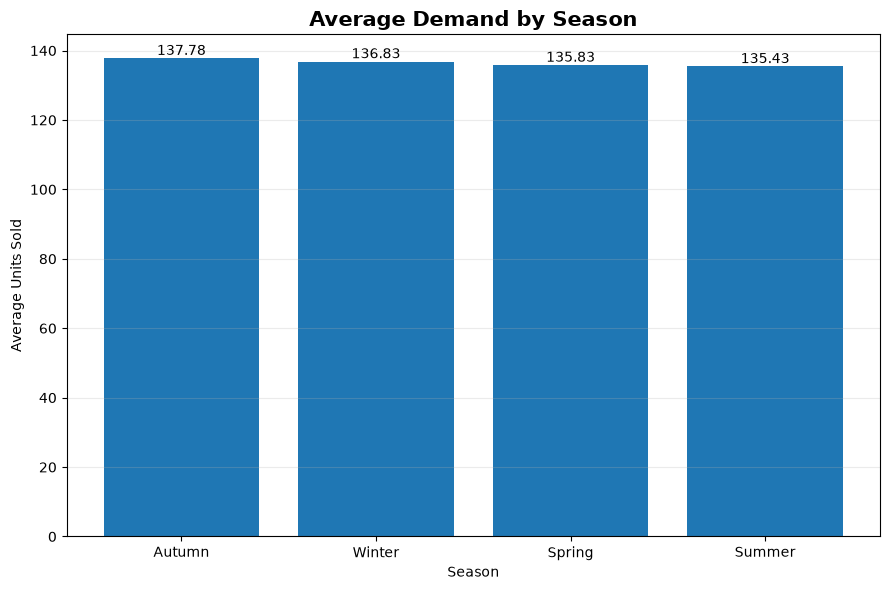


DEMAND BY WEATHER CONDITION
---------------------------------------------------------------------------


,Weather Condition,Records,Average_Units_Sold,Total_Units_Sold,Average_Inventory,Estimated_Net_Sales,Demand_Share_%
3,Sunny,"18,290",138.03,"2,524,544",275.71,"$125,112,939.01",25.31%
0,Cloudy,"18,260",136.76,"2,497,207",274.83,"$124,652,178.81",25.03%
2,Snowy,"18,272",135.91,"2,483,376",273.45,"$122,174,074.41",24.89%
1,Rainy,"18,278",135.16,"2,470,455",273.88,"$123,032,182.72",24.77%


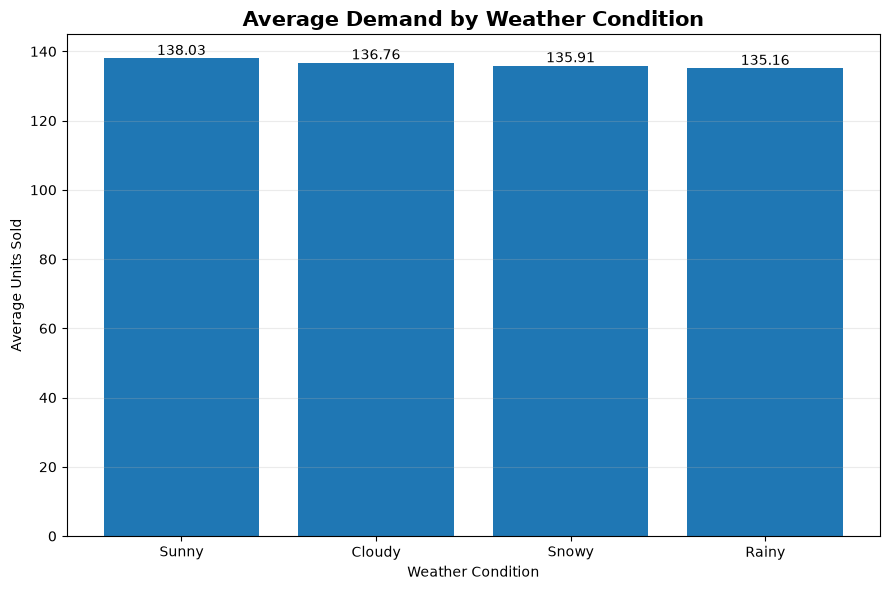


DEMAND BY DAY OF WEEK
---------------------------------------------------------------------------


,Day of Week,Records,Average_Units_Sold,Total_Units_Sold
0,Monday,"10,500",135.09,"1,418,494"
1,Tuesday,"10,400",137.31,"1,428,000"
2,Wednesday,"10,400",136.62,"1,420,797"
3,Thursday,"10,400",137.28,"1,427,732"
4,Friday,"10,400",136.85,"1,423,255"
5,Saturday,"10,500",135.31,"1,420,802"
6,Sunday,"10,500",136.81,"1,436,502"


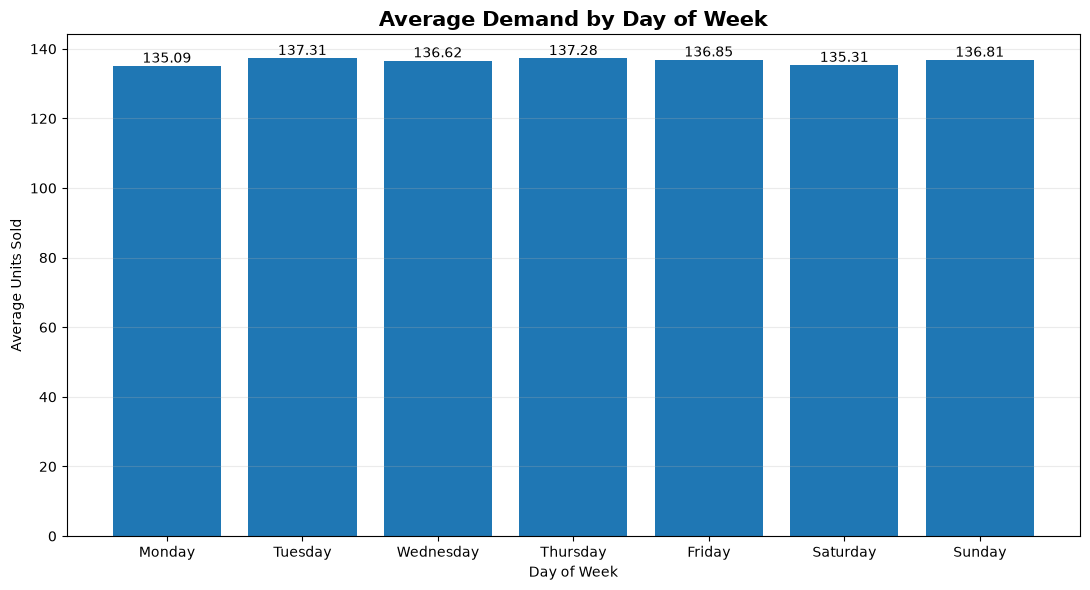


WEEKDAY VS WEEKEND DEMAND
---------------------------------------------------------------------------


,Day_Type,Records,Average_Units_Sold,Total_Units_Sold
0,Weekday,"52,100",136.63,"7,118,278"
1,Weekend,"21,000",136.06,"2,857,304"



SEASONAL & CALENDAR INSIGHT SUMMARY
---------------------------------------------------------------------------
Highest average-demand season : Autumn (137.78)
Lowest average-demand season  : Summer (135.43)
Seasonal demand gap           : 1.74%

Highest average-demand weather: Sunny (138.03)
Lowest average-demand weather : Rainy (135.16)
Weather demand gap            : 2.12%

Highest-demand weekday        : Tuesday (137.31)
Lowest-demand weekday         : Monday (135.09)


In [19]:
# ============================================================
# CELL 17: SEASONALITY, WEATHER & CALENDAR DEMAND ANALYSIS
# ============================================================

print("=" * 75)
print("SEASONALITY, WEATHER & CALENDAR DEMAND ANALYSIS")
print("=" * 75)


# ------------------------------------------------------------
# 1. Demand by Seasonality
# ------------------------------------------------------------
season_analysis = (
    df_analysis
    .groupby("Seasonality", as_index=False)
    .agg(
        Records=("Seasonality", "size"),
        Average_Units_Sold=("Units Sold", "mean"),
        Total_Units_Sold=("Units Sold", "sum"),
        Average_Inventory=("Inventory Level", "mean"),
        Estimated_Net_Sales=("Estimated Net Sales", "sum")
    )
    .sort_values("Average_Units_Sold", ascending=False)
)

season_analysis["Demand_Share_%"] = (
    season_analysis["Total_Units_Sold"]
    / season_analysis["Total_Units_Sold"].sum()
    * 100
)


print("\nDEMAND BY SEASONALITY")
print("-" * 75)

display(
    season_analysis.style.format({
        "Records": "{:,.0f}",
        "Average_Units_Sold": "{:,.2f}",
        "Total_Units_Sold": "{:,.0f}",
        "Average_Inventory": "{:,.2f}",
        "Estimated_Net_Sales": "${:,.2f}",
        "Demand_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 2. Seasonality Chart
# ------------------------------------------------------------
plt.figure(figsize=(9, 6))

bars = plt.bar(
    season_analysis["Seasonality"],
    season_analysis["Average_Units_Sold"]
)

plt.title(
    "Average Demand by Season",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Average Units Sold")
plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Demand by Weather Condition
# ------------------------------------------------------------
weather_analysis = (
    df_analysis
    .groupby("Weather Condition", as_index=False)
    .agg(
        Records=("Weather Condition", "size"),
        Average_Units_Sold=("Units Sold", "mean"),
        Total_Units_Sold=("Units Sold", "sum"),
        Average_Inventory=("Inventory Level", "mean"),
        Estimated_Net_Sales=("Estimated Net Sales", "sum")
    )
    .sort_values("Average_Units_Sold", ascending=False)
)

weather_analysis["Demand_Share_%"] = (
    weather_analysis["Total_Units_Sold"]
    / weather_analysis["Total_Units_Sold"].sum()
    * 100
)


print("\nDEMAND BY WEATHER CONDITION")
print("-" * 75)

display(
    weather_analysis.style.format({
        "Records": "{:,.0f}",
        "Average_Units_Sold": "{:,.2f}",
        "Total_Units_Sold": "{:,.0f}",
        "Average_Inventory": "{:,.2f}",
        "Estimated_Net_Sales": "${:,.2f}",
        "Demand_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 4. Weather Chart
# ------------------------------------------------------------
plt.figure(figsize=(9, 6))

bars = plt.bar(
    weather_analysis["Weather Condition"],
    weather_analysis["Average_Units_Sold"]
)

plt.title(
    "Average Demand by Weather Condition",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Weather Condition")
plt.ylabel("Average Units Sold")
plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Demand by Day of Week
# ------------------------------------------------------------
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_analysis = (
    df_analysis
    .groupby("Day of Week", as_index=False)
    .agg(
        Records=("Day of Week", "size"),
        Average_Units_Sold=("Units Sold", "mean"),
        Total_Units_Sold=("Units Sold", "sum")
    )
)

day_analysis["Day of Week"] = pd.Categorical(
    day_analysis["Day of Week"],
    categories=day_order,
    ordered=True
)

day_analysis = (
    day_analysis
    .sort_values("Day of Week")
    .reset_index(drop=True)
)


print("\nDEMAND BY DAY OF WEEK")
print("-" * 75)

display(
    day_analysis.style.format({
        "Records": "{:,.0f}",
        "Average_Units_Sold": "{:,.2f}",
        "Total_Units_Sold": "{:,.0f}"
    })
)


# ------------------------------------------------------------
# 6. Day-of-Week Chart
# ------------------------------------------------------------
plt.figure(figsize=(11, 6))

bars = plt.bar(
    day_analysis["Day of Week"].astype(str),
    day_analysis["Average_Units_Sold"]
)

plt.title(
    "Average Demand by Day of Week",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Day of Week")
plt.ylabel("Average Units Sold")
plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Weekday vs Weekend
# ------------------------------------------------------------
weekend_analysis = (
    df_analysis
    .groupby("Is Weekend", as_index=False)
    .agg(
        Records=("Is Weekend", "size"),
        Average_Units_Sold=("Units Sold", "mean"),
        Total_Units_Sold=("Units Sold", "sum")
    )
)

weekend_analysis["Day_Type"] = weekend_analysis[
    "Is Weekend"
].map({
    0: "Weekday",
    1: "Weekend"
})


print("\nWEEKDAY VS WEEKEND DEMAND")
print("-" * 75)

display(
    weekend_analysis[
        [
            "Day_Type",
            "Records",
            "Average_Units_Sold",
            "Total_Units_Sold"
        ]
    ].style.format({
        "Records": "{:,.0f}",
        "Average_Units_Sold": "{:,.2f}",
        "Total_Units_Sold": "{:,.0f}"
    })
)


# ------------------------------------------------------------
# 8. Descriptive Range Summary
# ------------------------------------------------------------
season_high = season_analysis.iloc[0]
season_low = season_analysis.iloc[-1]

weather_high = weather_analysis.iloc[0]
weather_low = weather_analysis.iloc[-1]

highest_day = day_analysis.loc[
    day_analysis["Average_Units_Sold"].idxmax()
]

lowest_day = day_analysis.loc[
    day_analysis["Average_Units_Sold"].idxmin()
]


season_gap_pct = (
    (
        season_high["Average_Units_Sold"]
        - season_low["Average_Units_Sold"]
    )
    / season_low["Average_Units_Sold"]
    * 100
)

weather_gap_pct = (
    (
        weather_high["Average_Units_Sold"]
        - weather_low["Average_Units_Sold"]
    )
    / weather_low["Average_Units_Sold"]
    * 100
)


print("\nSEASONAL & CALENDAR INSIGHT SUMMARY")
print("-" * 75)

print(
    f"Highest average-demand season : "
    f"{season_high['Seasonality']} "
    f"({season_high['Average_Units_Sold']:.2f})"
)

print(
    f"Lowest average-demand season  : "
    f"{season_low['Seasonality']} "
    f"({season_low['Average_Units_Sold']:.2f})"
)

print(
    f"Seasonal demand gap           : "
    f"{season_gap_pct:.2f}%"
)

print(
    f"\nHighest average-demand weather: "
    f"{weather_high['Weather Condition']} "
    f"({weather_high['Average_Units_Sold']:.2f})"
)

print(
    f"Lowest average-demand weather : "
    f"{weather_low['Weather Condition']} "
    f"({weather_low['Average_Units_Sold']:.2f})"
)

print(
    f"Weather demand gap            : "
    f"{weather_gap_pct:.2f}%"
)

print(
    f"\nHighest-demand weekday        : "
    f"{highest_day['Day of Week']} "
    f"({highest_day['Average_Units_Sold']:.2f})"
)

print(
    f"Lowest-demand weekday         : "
    f"{lowest_day['Day of Week']} "
    f"({lowest_day['Average_Units_Sold']:.2f})"
)

### Cell 18 — ABC Inventory Classification

ABC INVENTORY CLASSIFICATION

ABC analysis period : 2022-01-01 to 2023-12-31
Records used        : 73,000

ABC CLASS SUMMARY
---------------------------------------------------------------------------


,ABC_Class,Products,Total_Units_Sold,Estimated_Net_Sales,Product_Share_%,Value_Share_%
0,A,15,"7,503,431","$373,291,681.84",75.00%,75.51%
1,B,3,"1,480,703","$72,828,650.87",15.00%,14.73%
2,C,2,"978,204","$48,222,899.46",10.00%,9.75%



ABC PRODUCT CLASSIFICATION
---------------------------------------------------------------------------


,Product ID,Total_Units_Sold,Estimated_Net_Sales,Average_Inventory,Value_Share_%,Cumulative_Value_Share_%,ABC_Class
0,P0020,"506,905","$25,466,301.50",276.82,5.15%,5.15%,A
1,P0011,"498,972","$25,430,402.91",272.89,5.14%,10.30%,A
2,P0016,"508,009","$25,303,317.51",277.64,5.12%,15.41%,A
3,P0014,"506,630","$25,218,608.87",277.84,5.10%,20.52%,A
4,P0005,"502,619","$25,115,181.32",272.89,5.08%,25.60%,A
5,P0013,"499,983","$25,092,974.51",275.02,5.08%,30.67%,A
6,P0015,"506,356","$24,894,236.14",276.37,5.04%,35.71%,A
7,P0009,"501,761","$24,805,140.84",275.38,5.02%,40.73%,A
8,P0007,"499,092","$24,774,486.94",274.92,5.01%,45.74%,A
9,P0004,"495,146","$24,704,067.59",271.61,5.00%,50.73%,A


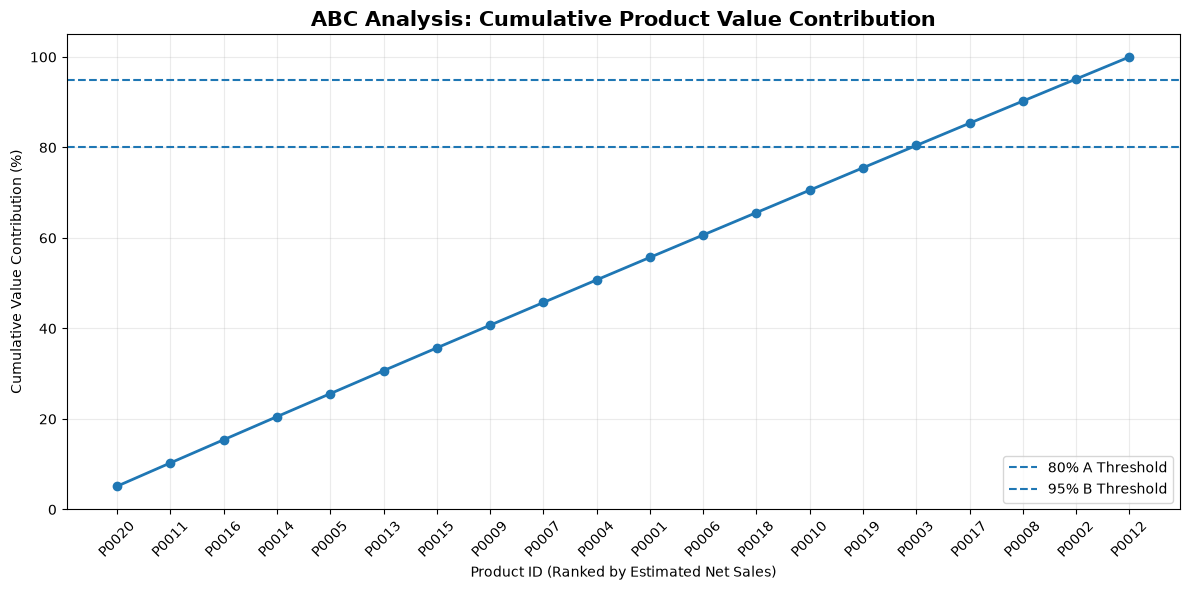


ABC CLASSIFICATION COUNTS
---------------------------------------------------------------------------
ABC_Class
A    15
B     3
C     2
Name: count, dtype: int64

METHODOLOGY NOTE
---------------------------------------------------------------------------
ABC classification uses Estimated Net Sales as a proxy for product value contribution.
This is necessary because inventory acquisition cost / COGS is not available in the dataset.


In [20]:
# ============================================================
# CELL 18: ABC INVENTORY CLASSIFICATION
# ============================================================

print("=" * 75)
print("ABC INVENTORY CLASSIFICATION")
print("=" * 75)


# ------------------------------------------------------------
# 1. Use Complete Analysis Period Only
# 2024 contains only one day, so exclude it from segmentation
# ------------------------------------------------------------
abc_source = df_analysis[
    df_analysis["Date"] < "2024-01-01"
].copy()

print(
    f"\nABC analysis period : "
    f"{abc_source['Date'].min().date()} "
    f"to {abc_source['Date'].max().date()}"
)

print(
    f"Records used        : "
    f"{len(abc_source):,}"
)


# ------------------------------------------------------------
# 2. Aggregate Product-Level Value Contribution
#
# Estimated Net Sales is used as an analytical proxy for
# product value contribution because product cost / COGS
# is not available in the dataset.
# ------------------------------------------------------------
abc_analysis = (
    abc_source
    .groupby("Product ID", as_index=False)
    .agg(
        Total_Units_Sold=("Units Sold", "sum"),
        Estimated_Net_Sales=("Estimated Net Sales", "sum"),
        Average_Inventory=("Inventory Level", "mean")
    )
)


# ------------------------------------------------------------
# 3. Sort Products by Value Contribution
# ------------------------------------------------------------
abc_analysis = (
    abc_analysis
    .sort_values(
        "Estimated_Net_Sales",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 4. Calculate Sales Contribution & Cumulative Contribution
# ------------------------------------------------------------
abc_analysis["Value_Share_%"] = (
    abc_analysis["Estimated_Net_Sales"]
    / abc_analysis["Estimated_Net_Sales"].sum()
    * 100
)

abc_analysis["Cumulative_Value_Share_%"] = (
    abc_analysis["Value_Share_%"].cumsum()
)


# ------------------------------------------------------------
# 5. Assign ABC Classes
#
# A = approximately first 80% of value contribution
# B = approximately next 15%
# C = approximately final 5%
# ------------------------------------------------------------
abc_analysis["ABC_Class"] = np.select(
    [
        abc_analysis["Cumulative_Value_Share_%"] <= 80,
        abc_analysis["Cumulative_Value_Share_%"] <= 95
    ],
    [
        "A",
        "B"
    ],
    default="C"
)


# ------------------------------------------------------------
# 6. ABC Summary
# ------------------------------------------------------------
abc_summary = (
    abc_analysis
    .groupby("ABC_Class", as_index=False)
    .agg(
        Products=("Product ID", "count"),
        Total_Units_Sold=("Total_Units_Sold", "sum"),
        Estimated_Net_Sales=("Estimated_Net_Sales", "sum")
    )
)

abc_summary["Product_Share_%"] = (
    abc_summary["Products"]
    / abc_analysis["Product ID"].nunique()
    * 100
)

abc_summary["Value_Share_%"] = (
    abc_summary["Estimated_Net_Sales"]
    / abc_analysis["Estimated_Net_Sales"].sum()
    * 100
)

abc_summary["ABC_Class"] = pd.Categorical(
    abc_summary["ABC_Class"],
    categories=["A", "B", "C"],
    ordered=True
)

abc_summary = (
    abc_summary
    .sort_values("ABC_Class")
    .reset_index(drop=True)
)


print("\nABC CLASS SUMMARY")
print("-" * 75)

display(
    abc_summary.style.format({
        "Products": "{:,.0f}",
        "Total_Units_Sold": "{:,.0f}",
        "Estimated_Net_Sales": "${:,.2f}",
        "Product_Share_%": "{:.2f}%",
        "Value_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 7. Complete ABC Product Table
# ------------------------------------------------------------
print("\nABC PRODUCT CLASSIFICATION")
print("-" * 75)

display(
    abc_analysis.style.format({
        "Total_Units_Sold": "{:,.0f}",
        "Estimated_Net_Sales": "${:,.2f}",
        "Average_Inventory": "{:,.2f}",
        "Value_Share_%": "{:.2f}%",
        "Cumulative_Value_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 8. ABC Cumulative Contribution Chart
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(
    abc_analysis["Product ID"],
    abc_analysis["Cumulative_Value_Share_%"],
    marker="o",
    linewidth=2
)

plt.axhline(
    y=80,
    linestyle="--",
    linewidth=1.5,
    label="80% A Threshold"
)

plt.axhline(
    y=95,
    linestyle="--",
    linewidth=1.5,
    label="95% B Threshold"
)

plt.title(
    "ABC Analysis: Cumulative Product Value Contribution",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Product ID (Ranked by Estimated Net Sales)")
plt.ylabel("Cumulative Value Contribution (%)")

plt.xticks(rotation=45)
plt.ylim(0, 105)
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Classification Counts
# ------------------------------------------------------------
print("\nABC CLASSIFICATION COUNTS")
print("-" * 75)

print(
    abc_analysis["ABC_Class"]
    .value_counts()
    .reindex(["A", "B", "C"], fill_value=0)
)


print("\nMETHODOLOGY NOTE")
print("-" * 75)

print(
    "ABC classification uses Estimated Net Sales as a proxy "
    "for product value contribution."
)

print(
    "This is necessary because inventory acquisition cost / "
    "COGS is not available in the dataset."
)

### Cell 19 — XYZ Demand Variability Classification

XYZ DEMAND VARIABILITY CLASSIFICATION

XYZ analysis period : 2022-01-01 to 2023-12-31
Complete months used: 24

MONTHLY COVERAGE VALIDATION
---------------------------------------------------------------------------
Minimum months per product : 24
Maximum months per product : 24
Products with all 24 months: 20 / 20

COEFFICIENT OF VARIATION DISTRIBUTION
---------------------------------------------------------------------------


,CV_%
count,20.00
mean,6.98
std,0.98
min,5.43
25%,6.20
50%,6.88
75%,7.58
max,9.53



XYZ PRODUCT CLASSIFICATION
---------------------------------------------------------------------------


,Product ID,Mean_Monthly_Demand,Std_Monthly_Demand,Min_Monthly_Demand,Max_Monthly_Demand,CV_%,XYZ_Class
0,P0014,"21,109.58","1,146.32","19,227","23,631",5.43%,X
1,P0004,"20,631.08","1,183.57","17,178","22,421",5.74%,X
2,P0003,"20,539.54","1,214.02","18,568","23,400",5.91%,X
3,P0019,"20,709.25","1,231.32","18,369","23,653",5.95%,X
4,P0006,"20,672.96","1,249.58","18,135","23,430",6.04%,X
5,P0007,"20,795.50","1,298.78","18,976","23,361",6.25%,X
6,P0016,"21,167.04","1,440.51","18,868","24,995",6.81%,X
7,P0005,"20,942.46","1,426.46","17,984","23,580",6.81%,Y
8,P0015,"21,098.17","1,440.30","18,875","24,103",6.83%,Y
9,P0010,"20,639.88","1,413.65","18,913","23,750",6.85%,Y



XYZ CLASS SUMMARY
---------------------------------------------------------------------------


,XYZ_Class,Products,Average_CV,Average_Monthly_Demand,Product_Share_%
0,X,7,0.0602,"20,803.57",35.00%
1,Y,6,0.0688,"20,747.86",30.00%
2,Z,7,0.0803,"20,712.18",35.00%


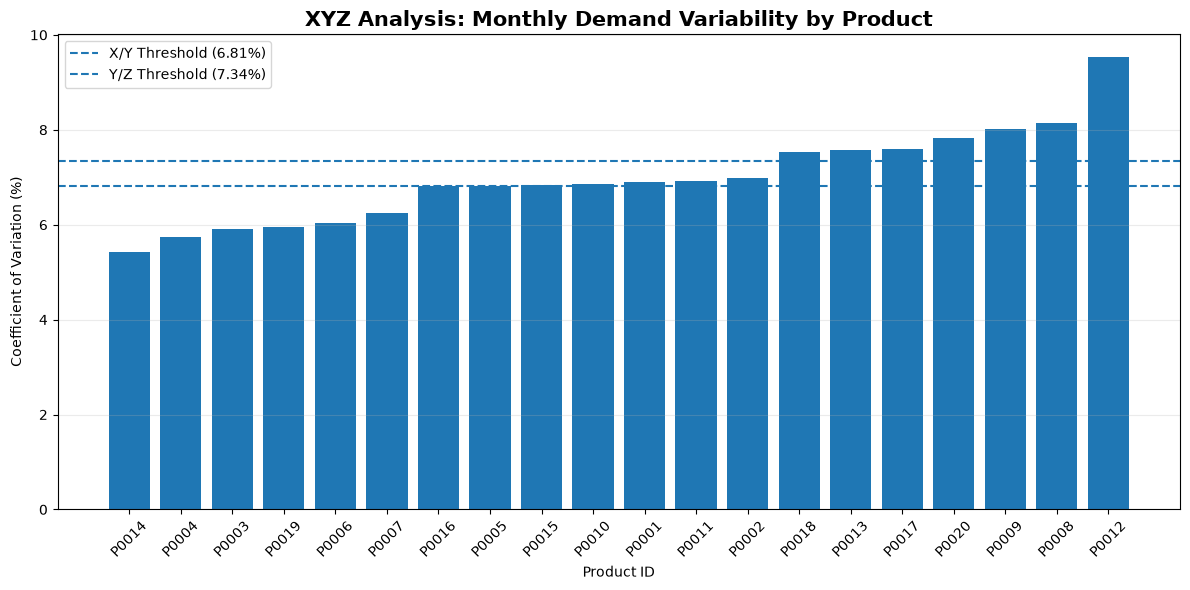


XYZ THRESHOLDS & INSIGHTS
---------------------------------------------------------------------------
X/Y CV threshold : 6.81%
Y/Z CV threshold : 7.34%

Most stable product   : P0014 (CV = 5.43%)
Most variable product : P0012 (CV = 9.53%)

Interpretation:
X = relatively stable monthly demand
Y = moderate monthly demand variability
Z = relatively high monthly demand variability

Note: XYZ thresholds are dataset-relative tertiles, not universal industry cutoffs.


In [21]:
# ============================================================
# CELL 19: XYZ DEMAND VARIABILITY CLASSIFICATION
# ============================================================

print("=" * 75)
print("XYZ DEMAND VARIABILITY CLASSIFICATION")
print("=" * 75)


# ------------------------------------------------------------
# 1. Use Complete 2022-2023 Period
# ------------------------------------------------------------
xyz_source = df_analysis[
    (df_analysis["Date"] >= "2022-01-01") &
    (df_analysis["Date"] <= "2023-12-31")
].copy()

xyz_source["Year_Month"] = (
    xyz_source["Date"].dt.to_period("M")
)

print(
    f"\nXYZ analysis period : "
    f"{xyz_source['Date'].min().date()} "
    f"to {xyz_source['Date'].max().date()}"
)

print(
    f"Complete months used: "
    f"{xyz_source['Year_Month'].nunique()}"
)


# ------------------------------------------------------------
# 2. Aggregate Monthly Demand by Product
# ------------------------------------------------------------
product_monthly_demand = (
    xyz_source
    .groupby(
        ["Product ID", "Year_Month"],
        as_index=False
    )
    .agg(
        Monthly_Units_Sold=("Units Sold", "sum")
    )
)


# ------------------------------------------------------------
# 3. Validate Monthly Coverage
# ------------------------------------------------------------
monthly_coverage = (
    product_monthly_demand
    .groupby("Product ID")["Year_Month"]
    .nunique()
)

print("\nMONTHLY COVERAGE VALIDATION")
print("-" * 75)

print(
    f"Minimum months per product : "
    f"{monthly_coverage.min()}"
)

print(
    f"Maximum months per product : "
    f"{monthly_coverage.max()}"
)

print(
    f"Products with all 24 months: "
    f"{(monthly_coverage == 24).sum()} / "
    f"{monthly_coverage.shape[0]}"
)


# ------------------------------------------------------------
# 4. Calculate Demand Variability
# ------------------------------------------------------------
xyz_analysis = (
    product_monthly_demand
    .groupby("Product ID", as_index=False)
    .agg(
        Mean_Monthly_Demand=(
            "Monthly_Units_Sold",
            "mean"
        ),
        Std_Monthly_Demand=(
            "Monthly_Units_Sold",
            "std"
        ),
        Min_Monthly_Demand=(
            "Monthly_Units_Sold",
            "min"
        ),
        Max_Monthly_Demand=(
            "Monthly_Units_Sold",
            "max"
        )
    )
)


# Coefficient of Variation
xyz_analysis["CV"] = (
    xyz_analysis["Std_Monthly_Demand"]
    / xyz_analysis["Mean_Monthly_Demand"]
)

xyz_analysis["CV_%"] = (
    xyz_analysis["CV"] * 100
)


# ------------------------------------------------------------
# 5. Inspect CV Distribution
# ------------------------------------------------------------
print("\nCOEFFICIENT OF VARIATION DISTRIBUTION")
print("-" * 75)

display(
    xyz_analysis["CV_%"]
    .describe()
    .to_frame(name="CV_%")
)


# ------------------------------------------------------------
# 6. Data-Driven XYZ Thresholds
#
# Lower CV = more stable demand
# Higher CV = more variable demand
#
# Tertiles are used because the synthetic dataset is highly
# balanced and may not separate well under fixed textbook
# thresholds.
# ------------------------------------------------------------
x_threshold = xyz_analysis["CV"].quantile(1 / 3)
y_threshold = xyz_analysis["CV"].quantile(2 / 3)


def assign_xyz(cv):
    if cv <= x_threshold:
        return "X"
    elif cv <= y_threshold:
        return "Y"
    else:
        return "Z"


xyz_analysis["XYZ_Class"] = (
    xyz_analysis["CV"]
    .apply(assign_xyz)
)


# ------------------------------------------------------------
# 7. Sort by Demand Stability
# ------------------------------------------------------------
xyz_analysis = (
    xyz_analysis
    .sort_values(
        "CV",
        ascending=True
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 8. Complete XYZ Table
# ------------------------------------------------------------
print("\nXYZ PRODUCT CLASSIFICATION")
print("-" * 75)

display(
    xyz_analysis[
        [
            "Product ID",
            "Mean_Monthly_Demand",
            "Std_Monthly_Demand",
            "Min_Monthly_Demand",
            "Max_Monthly_Demand",
            "CV_%",
            "XYZ_Class"
        ]
    ].style.format({
        "Mean_Monthly_Demand": "{:,.2f}",
        "Std_Monthly_Demand": "{:,.2f}",
        "Min_Monthly_Demand": "{:,.0f}",
        "Max_Monthly_Demand": "{:,.0f}",
        "CV_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 9. XYZ Class Summary
# ------------------------------------------------------------
xyz_summary = (
    xyz_analysis
    .groupby("XYZ_Class", as_index=False)
    .agg(
        Products=("Product ID", "count"),
        Average_CV=("CV", "mean"),
        Average_Monthly_Demand=(
            "Mean_Monthly_Demand",
            "mean"
        )
    )
)

xyz_summary["Product_Share_%"] = (
    xyz_summary["Products"]
    / xyz_analysis["Product ID"].nunique()
    * 100
)

xyz_summary["XYZ_Class"] = pd.Categorical(
    xyz_summary["XYZ_Class"],
    categories=["X", "Y", "Z"],
    ordered=True
)

xyz_summary = (
    xyz_summary
    .sort_values("XYZ_Class")
    .reset_index(drop=True)
)


print("\nXYZ CLASS SUMMARY")
print("-" * 75)

display(
    xyz_summary.style.format({
        "Products": "{:,.0f}",
        "Average_CV": "{:.4f}",
        "Average_Monthly_Demand": "{:,.2f}",
        "Product_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 10. XYZ Visualization
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

bars = plt.bar(
    xyz_analysis["Product ID"],
    xyz_analysis["CV_%"]
)

plt.axhline(
    x_threshold * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"X/Y Threshold ({x_threshold * 100:.2f}%)"
)

plt.axhline(
    y_threshold * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Y/Z Threshold ({y_threshold * 100:.2f}%)"
)

plt.title(
    "XYZ Analysis: Monthly Demand Variability by Product",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Product ID")
plt.ylabel("Coefficient of Variation (%)")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. Threshold & Stability Summary
# ------------------------------------------------------------
most_stable = xyz_analysis.iloc[0]
most_variable = xyz_analysis.iloc[-1]


print("\nXYZ THRESHOLDS & INSIGHTS")
print("-" * 75)

print(
    f"X/Y CV threshold : "
    f"{x_threshold * 100:.2f}%"
)

print(
    f"Y/Z CV threshold : "
    f"{y_threshold * 100:.2f}%"
)

print(
    f"\nMost stable product   : "
    f"{most_stable['Product ID']} "
    f"(CV = {most_stable['CV_%']:.2f}%)"
)

print(
    f"Most variable product : "
    f"{most_variable['Product ID']} "
    f"(CV = {most_variable['CV_%']:.2f}%)"
)

print("\nInterpretation:")
print("X = relatively stable monthly demand")
print("Y = moderate monthly demand variability")
print("Z = relatively high monthly demand variability")

print(
    "\nNote: XYZ thresholds are dataset-relative tertiles, "
    "not universal industry cutoffs."
)

### Cell 20 — Combined ABC–XYZ Inventory Segmentation

COMBINED ABC-XYZ INVENTORY SEGMENTATION

ABC-XYZ PRODUCT COUNT MATRIX
---------------------------------------------------------------------------


XYZ_Class,X,Y,Z
ABC_Class,,,
A,6,5,4
B,1,0,2
C,0,1,1



ABC-XYZ SEGMENT SUMMARY
---------------------------------------------------------------------------


,ABC_XYZ_Segment,Products,Total_Units_Sold,Estimated_Net_Sales,Average_CV_pct,Average_Inventory,Value_Share_%
0,AX,6,"3,002,050","$148,967,981.80",6.03%,275.01,30.13%
1,AY,5,"2,500,496","$124,483,226.12",6.86%,273.98,25.18%
2,AZ,4,"2,000,885","$99,840,473.91",7.74%,274.96,20.20%
3,BX,1,"492,949","$24,348,433.80",5.91%,275.02,4.93%
4,BZ,2,"987,754","$48,480,217.07",7.87%,275.57,9.81%
5,CY,1,"487,196","$24,143,629.23",6.98%,271.13,4.88%
6,CZ,1,"491,008","$24,079,270.23",9.53%,272.59,4.87%



COMPLETE ABC-XYZ PRODUCT SEGMENTATION
---------------------------------------------------------------------------


,Product ID,ABC_Class,XYZ_Class,ABC_XYZ_Segment,Total_Units_Sold,Estimated_Net_Sales,Value_Share_%,Mean_Monthly_Demand,CV_%,Average_Inventory,Management_Profile,Suggested_Strategy
0,P0016,A,X,AX,"508,009","$25,303,317.51",5.12%,"21,167.04",6.81%,277.64,High Value - Stable Demand,Tight control; frequent review; lean safety stock
1,P0014,A,X,AX,"506,630","$25,218,608.87",5.10%,"21,109.58",5.43%,277.84,High Value - Stable Demand,Tight control; frequent review; lean safety stock
2,P0007,A,X,AX,"499,092","$24,774,486.94",5.01%,"20,795.50",6.25%,274.92,High Value - Stable Demand,Tight control; frequent review; lean safety stock
3,P0004,A,X,AX,"495,146","$24,704,067.59",5.00%,"20,631.08",5.74%,271.61,High Value - Stable Demand,Tight control; frequent review; lean safety stock
4,P0006,A,X,AX,"496,151","$24,498,618.73",4.96%,"20,672.96",6.04%,273.46,High Value - Stable Demand,Tight control; frequent review; lean safety stock
5,P0019,A,X,AX,"497,022","$24,468,882.15",4.95%,"20,709.25",5.95%,274.56,High Value - Stable Demand,Tight control; frequent review; lean safety stock
6,P0011,A,Y,AY,"498,972","$25,430,402.91",5.14%,"20,790.50",6.92%,272.89,High Value - Moderate Variability,Frequent review; moderate safety stock
7,P0005,A,Y,AY,"502,619","$25,115,181.32",5.08%,"20,942.46",6.81%,272.89,High Value - Moderate Variability,Frequent review; moderate safety stock
8,P0015,A,Y,AY,"506,356","$24,894,236.14",5.04%,"21,098.17",6.83%,276.37,High Value - Moderate Variability,Frequent review; moderate safety stock
9,P0001,A,Y,AY,"497,192","$24,571,677.76",4.97%,"20,716.33",6.91%,272.94,High Value - Moderate Variability,Frequent review; moderate safety stock


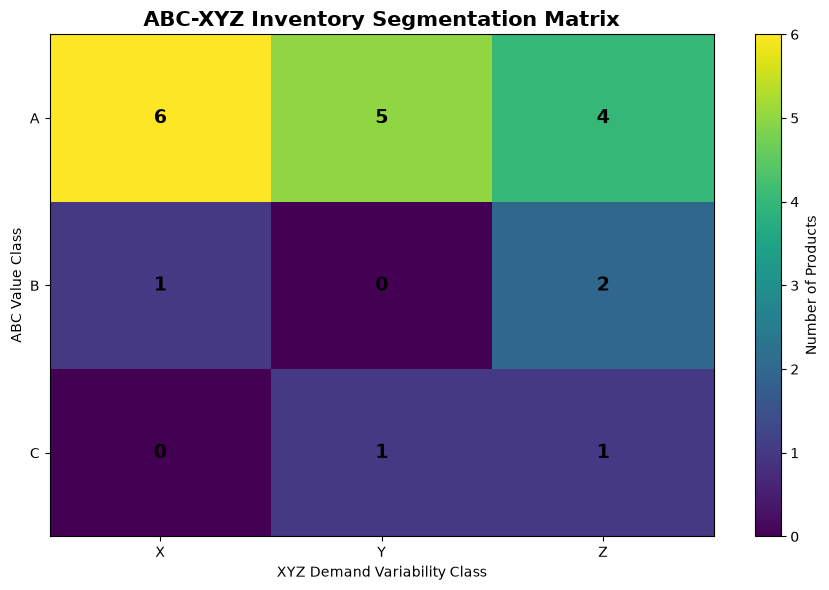


ABC-XYZ MANAGEMENT INSIGHTS
---------------------------------------------------------------------------
AX: 6 product(s) -> P0016, P0014, P0007, P0004, P0006, P0019
AY: 5 product(s) -> P0011, P0005, P0015, P0001, P0010
AZ: 4 product(s) -> P0020, P0013, P0009, P0018
BX: 1 product(s) -> P0003
BZ: 2 product(s) -> P0017, P0008
CY: 1 product(s) -> P0002
CZ: 1 product(s) -> P0012

PRIORITY INVENTORY GROUPS
---------------------------------------------------------------------------
AX products (high value + stable demand): P0016, P0014, P0007, P0004, P0006, P0019
AZ products (high value + higher variability): P0020, P0013, P0009, P0018

METHODOLOGY NOTE
---------------------------------------------------------------------------
ABC represents relative product value contribution using Estimated Net Sales.
XYZ represents relative monthly demand variability using coefficient-of-variation tertiles.
Inventory strategies are decision-support guidelines rather than optimized reorder policies.


In [22]:
# ============================================================
# CELL 20: COMBINED ABC-XYZ INVENTORY SEGMENTATION
# ============================================================

print("=" * 75)
print("COMBINED ABC-XYZ INVENTORY SEGMENTATION")
print("=" * 75)


# ------------------------------------------------------------
# 1. Merge ABC and XYZ Results
# ------------------------------------------------------------
abc_xyz = abc_analysis[
    [
        "Product ID",
        "Total_Units_Sold",
        "Estimated_Net_Sales",
        "Average_Inventory",
        "Value_Share_%",
        "ABC_Class"
    ]
].merge(
    xyz_analysis[
        [
            "Product ID",
            "Mean_Monthly_Demand",
            "Std_Monthly_Demand",
            "CV_%",
            "XYZ_Class"
        ]
    ],
    on="Product ID",
    how="inner"
)


# ------------------------------------------------------------
# 2. Create Combined ABC-XYZ Segment
# ------------------------------------------------------------
abc_xyz["ABC_XYZ_Segment"] = (
    abc_xyz["ABC_Class"].astype(str)
    + abc_xyz["XYZ_Class"].astype(str)
)


# ------------------------------------------------------------
# 3. Assign Inventory Management Priority
# ------------------------------------------------------------
priority_map = {
    "AX": "High Value - Stable Demand",
    "AY": "High Value - Moderate Variability",
    "AZ": "High Value - High Variability",

    "BX": "Medium Value - Stable Demand",
    "BY": "Medium Value - Moderate Variability",
    "BZ": "Medium Value - High Variability",

    "CX": "Lower Value - Stable Demand",
    "CY": "Lower Value - Moderate Variability",
    "CZ": "Lower Value - High Variability"
}

abc_xyz["Management_Profile"] = (
    abc_xyz["ABC_XYZ_Segment"]
    .map(priority_map)
)


# ------------------------------------------------------------
# 4. Assign Suggested Inventory Strategy
# ------------------------------------------------------------
strategy_map = {
    "AX": "Tight control; frequent review; lean safety stock",
    "AY": "Frequent review; moderate safety stock",
    "AZ": "Very close monitoring; higher safety buffer",

    "BX": "Periodic review; efficient replenishment",
    "BY": "Standard review; moderate buffer",
    "BZ": "Monitor variability; maintain additional buffer",

    "CX": "Simple replenishment; low management effort",
    "CY": "Periodic review; flexible replenishment",
    "CZ": "Conservative stocking; avoid excess inventory"
}

abc_xyz["Suggested_Strategy"] = (
    abc_xyz["ABC_XYZ_Segment"]
    .map(strategy_map)
)


# ------------------------------------------------------------
# 5. Sort Segments Logically
# ------------------------------------------------------------
abc_order = {
    "A": 1,
    "B": 2,
    "C": 3
}

xyz_order = {
    "X": 1,
    "Y": 2,
    "Z": 3
}

abc_xyz["_ABC_Order"] = (
    abc_xyz["ABC_Class"]
    .astype(str)
    .map(abc_order)
)

abc_xyz["_XYZ_Order"] = (
    abc_xyz["XYZ_Class"]
    .astype(str)
    .map(xyz_order)
)

abc_xyz = (
    abc_xyz
    .sort_values(
        ["_ABC_Order", "_XYZ_Order", "Estimated_Net_Sales"],
        ascending=[True, True, False]
    )
    .drop(
        columns=["_ABC_Order", "_XYZ_Order"]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. Segment Count Matrix
# ------------------------------------------------------------
segment_matrix = pd.crosstab(
    abc_xyz["ABC_Class"],
    abc_xyz["XYZ_Class"]
)

segment_matrix = segment_matrix.reindex(
    index=["A", "B", "C"],
    columns=["X", "Y", "Z"],
    fill_value=0
)


print("\nABC-XYZ PRODUCT COUNT MATRIX")
print("-" * 75)

display(segment_matrix)


# ------------------------------------------------------------
# 7. Segment-Level Summary
# ------------------------------------------------------------
segment_summary = (
    abc_xyz
    .groupby("ABC_XYZ_Segment", as_index=False)
    .agg(
        Products=("Product ID", "count"),
        Total_Units_Sold=("Total_Units_Sold", "sum"),
        Estimated_Net_Sales=("Estimated_Net_Sales", "sum"),
        Average_CV_pct=("CV_%", "mean"),
        Average_Inventory=("Average_Inventory", "mean")
    )
)


segment_summary["Value_Share_%"] = (
    segment_summary["Estimated_Net_Sales"]
    / abc_xyz["Estimated_Net_Sales"].sum()
    * 100
)


segment_order = [
    "AX", "AY", "AZ",
    "BX", "BY", "BZ",
    "CX", "CY", "CZ"
]

segment_summary["ABC_XYZ_Segment"] = pd.Categorical(
    segment_summary["ABC_XYZ_Segment"],
    categories=segment_order,
    ordered=True
)

segment_summary = (
    segment_summary
    .sort_values("ABC_XYZ_Segment")
    .reset_index(drop=True)
)


print("\nABC-XYZ SEGMENT SUMMARY")
print("-" * 75)

display(
    segment_summary.style.format({
        "Products": "{:,.0f}",
        "Total_Units_Sold": "{:,.0f}",
        "Estimated_Net_Sales": "${:,.2f}",
        "Average_CV_pct": "{:.2f}%",
        "Average_Inventory": "{:,.2f}",
        "Value_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 8. Complete Product Segmentation Table
# ------------------------------------------------------------
print("\nCOMPLETE ABC-XYZ PRODUCT SEGMENTATION")
print("-" * 75)

display(
    abc_xyz[
        [
            "Product ID",
            "ABC_Class",
            "XYZ_Class",
            "ABC_XYZ_Segment",
            "Total_Units_Sold",
            "Estimated_Net_Sales",
            "Value_Share_%",
            "Mean_Monthly_Demand",
            "CV_%",
            "Average_Inventory",
            "Management_Profile",
            "Suggested_Strategy"
        ]
    ].style.format({
        "Total_Units_Sold": "{:,.0f}",
        "Estimated_Net_Sales": "${:,.2f}",
        "Value_Share_%": "{:.2f}%",
        "Mean_Monthly_Demand": "{:,.2f}",
        "CV_%": "{:.2f}%",
        "Average_Inventory": "{:,.2f}"
    })
)


# ------------------------------------------------------------
# 9. Visualize ABC-XYZ Matrix
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

matrix_values = segment_matrix.values

im = ax.imshow(
    matrix_values,
    aspect="auto"
)

ax.set_xticks(range(3))
ax.set_xticklabels(["X", "Y", "Z"])

ax.set_yticks(range(3))
ax.set_yticklabels(["A", "B", "C"])

ax.set_xlabel("XYZ Demand Variability Class")
ax.set_ylabel("ABC Value Class")

ax.set_title(
    "ABC-XYZ Inventory Segmentation Matrix",
    fontsize=15,
    fontweight="bold"
)

for i in range(matrix_values.shape[0]):
    for j in range(matrix_values.shape[1]):
        ax.text(
            j,
            i,
            f"{matrix_values[i, j]}",
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold"
        )

plt.colorbar(
    im,
    ax=ax,
    label="Number of Products"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Key Segment Insights
# ------------------------------------------------------------
print("\nABC-XYZ MANAGEMENT INSIGHTS")
print("-" * 75)

for segment in segment_order:

    products = abc_xyz.loc[
        abc_xyz["ABC_XYZ_Segment"] == segment,
        "Product ID"
    ].tolist()

    if products:
        print(
            f"{segment}: "
            f"{len(products)} product(s) -> "
            f"{', '.join(products)}"
        )


# ------------------------------------------------------------
# 11. Important High-Value Products
# ------------------------------------------------------------
high_value_variable = abc_xyz[
    abc_xyz["ABC_XYZ_Segment"] == "AZ"
]

high_value_stable = abc_xyz[
    abc_xyz["ABC_XYZ_Segment"] == "AX"
]


print("\nPRIORITY INVENTORY GROUPS")
print("-" * 75)

print(
    "AX products (high value + stable demand):",
    ", ".join(high_value_stable["Product ID"])
    if len(high_value_stable) > 0
    else "None"
)

print(
    "AZ products (high value + higher variability):",
    ", ".join(high_value_variable["Product ID"])
    if len(high_value_variable) > 0
    else "None"
)


print("\nMETHODOLOGY NOTE")
print("-" * 75)

print(
    "ABC represents relative product value contribution "
    "using Estimated Net Sales."
)

print(
    "XYZ represents relative monthly demand variability "
    "using coefficient-of-variation tertiles."
)

print(
    "Inventory strategies are decision-support guidelines "
    "rather than optimized reorder policies."
)

### Cell 21 — Existing Demand Forecast Benchmark & Uncertainty Analysis

EXISTING DEMAND FORECAST BENCHMARK & UNCERTAINTY ANALYSIS

Evaluation period : 2022-01-01 to 2023-12-31
Records evaluated : 73,000

FORECAST ACCURACY BENCHMARK
---------------------------------------------------------------------------


,Forecast Version,MAE,RMSE,R2,Bias
0,Original Demand Forecast,8.339,10.016,0.9915,+5.030
1,Clipped Demand Forecast,8.305,10.000,0.9916,+5.064



FORECAST DIRECTION SUMMARY
---------------------------------------------------------------------------
Underforecast records : 24,126 (33.05%)
Overforecast records  : 48,717 (66.74%)
Exact forecasts       : 157 (0.22%)

GLOBAL UNCERTAINTY BUFFER CANDIDATES
---------------------------------------------------------------------------


,Coverage Percentile,Additional Buffer Units
0,50%,0.00
1,75%,2.35
2,90%,6.83
3,95%,8.42
4,99%,9.69



90% global safety-buffer candidate: 7 units

PRODUCT-LEVEL FORECAST ACCURACY
---------------------------------------------------------------------------


,Product ID,Records,MAE,Bias,Safety_Buffer_90,RMSE,Underforecast_Rate_%
0,P0006,"3,650",8.217,+5.022,7,9.927,32.55%
1,P0014,"3,650",8.220,+4.951,7,9.932,33.75%
2,P0015,"3,650",8.221,+5.172,7,9.975,32.66%
3,P0002,"3,650",8.230,+5.053,7,9.949,33.10%
4,P0020,"3,650",8.233,+4.800,8,9.906,34.88%
5,P0008,"3,650",8.246,+5.036,7,9.946,33.40%
6,P0009,"3,650",8.259,+5.079,7,9.968,32.49%
7,P0010,"3,650",8.263,+4.850,8,9.947,34.27%
8,P0016,"3,650",8.266,+4.885,8,9.971,32.90%
9,P0011,"3,650",8.292,+5.014,7,9.935,33.01%


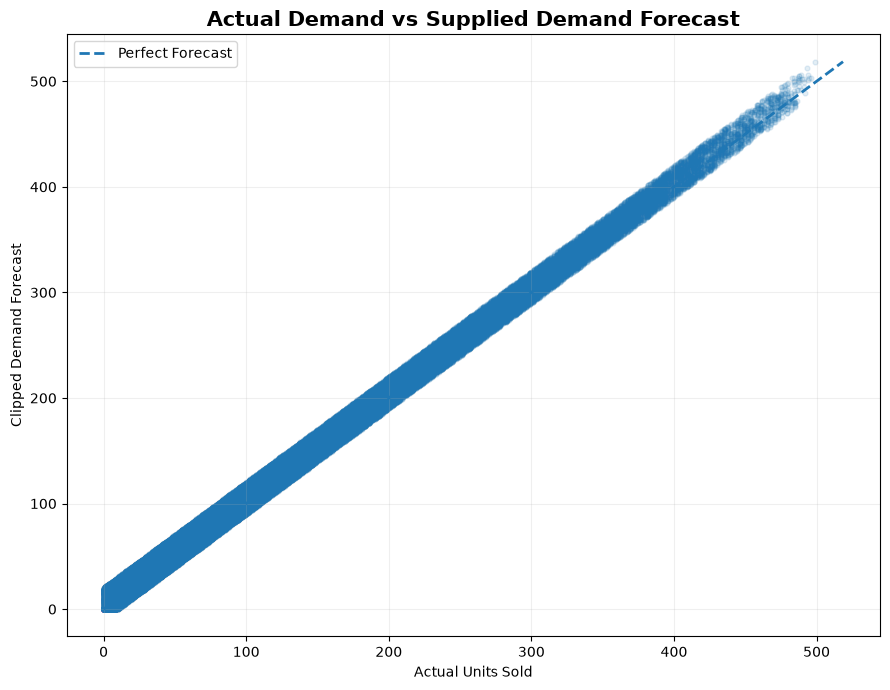

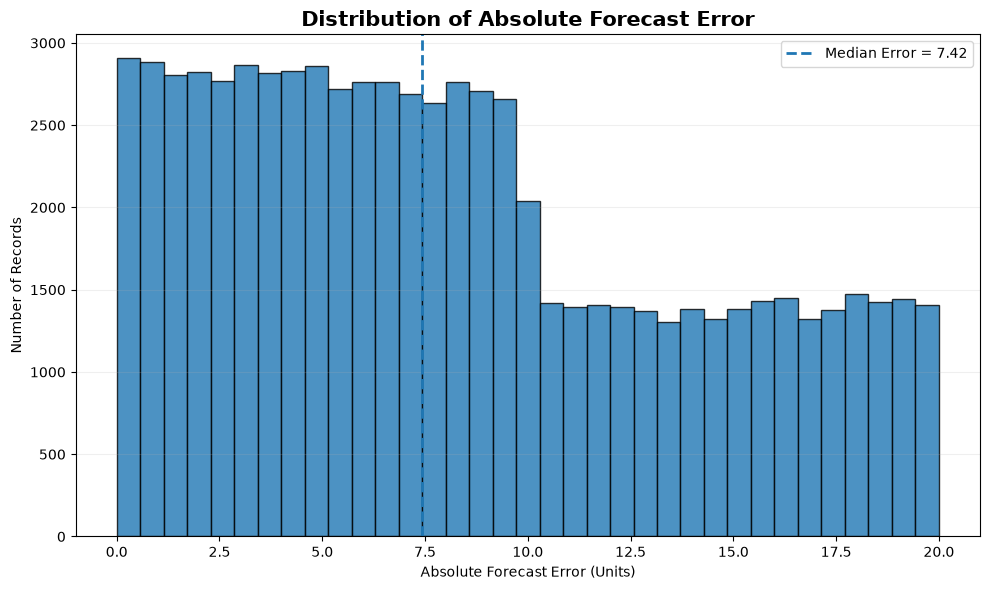


FORECAST ERROR SUMMARY
---------------------------------------------------------------------------
Median absolute error : 7.42 units
90th percentile absolute error : 17.07 units
95th percentile absolute error : 18.54 units

Important: The supplied Demand Forecast is being used only as an external benchmark and for historical inventory-risk analysis. It will not be used as an input feature for our ML demand model.


In [23]:
# ============================================================
# CELL 21: EXISTING DEMAND FORECAST BENCHMARK
#           & UNCERTAINTY ANALYSIS
# ============================================================

print("=" * 75)
print("EXISTING DEMAND FORECAST BENCHMARK & UNCERTAINTY ANALYSIS")
print("=" * 75)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ------------------------------------------------------------
# 1. Use Complete Historical Period
# Exclude 2024 because only one day is available.
# ------------------------------------------------------------
forecast_eval = df_analysis[
    (df_analysis["Date"] >= "2022-01-01") &
    (df_analysis["Date"] <= "2023-12-31")
].copy()

print(
    f"\nEvaluation period : "
    f"{forecast_eval['Date'].min().date()} "
    f"to {forecast_eval['Date'].max().date()}"
)

print(
    f"Records evaluated : "
    f"{len(forecast_eval):,}"
)


# ------------------------------------------------------------
# 2. Prepare Actual and Forecast Values
# ------------------------------------------------------------
forecast_eval["Actual_Demand"] = (
    forecast_eval["Units Sold"]
)

forecast_eval["Original_Forecast"] = (
    forecast_eval["Demand Forecast"]
)

forecast_eval["Clipped_Forecast"] = (
    forecast_eval["Demand Forecast Clipped"]
)


# ------------------------------------------------------------
# 3. Benchmark Metrics Function
# ------------------------------------------------------------
def calculate_forecast_metrics(actual, predicted):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    bias = (
        predicted - actual
    ).mean()

    return mae, rmse, r2, bias


original_metrics = calculate_forecast_metrics(
    forecast_eval["Actual_Demand"],
    forecast_eval["Original_Forecast"]
)

clipped_metrics = calculate_forecast_metrics(
    forecast_eval["Actual_Demand"],
    forecast_eval["Clipped_Forecast"]
)


benchmark_metrics = pd.DataFrame({
    "Forecast Version": [
        "Original Demand Forecast",
        "Clipped Demand Forecast"
    ],

    "MAE": [
        original_metrics[0],
        clipped_metrics[0]
    ],

    "RMSE": [
        original_metrics[1],
        clipped_metrics[1]
    ],

    "R2": [
        original_metrics[2],
        clipped_metrics[2]
    ],

    "Bias": [
        original_metrics[3],
        clipped_metrics[3]
    ]
})


print("\nFORECAST ACCURACY BENCHMARK")
print("-" * 75)

display(
    benchmark_metrics.style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "R2": "{:.4f}",
        "Bias": "{:+.3f}"
    })
)


# ------------------------------------------------------------
# 4. Error Variables
#
# Forecast Error:
# Positive = forecast above actual demand
# Negative = forecast below actual demand
# ------------------------------------------------------------
forecast_eval["Forecast_Error"] = (
    forecast_eval["Clipped_Forecast"]
    - forecast_eval["Actual_Demand"]
)

forecast_eval["Absolute_Error"] = (
    forecast_eval["Forecast_Error"].abs()
)

forecast_eval["Squared_Error"] = (
    forecast_eval["Forecast_Error"] ** 2
)

forecast_eval["Underforecast_Units"] = np.maximum(
    forecast_eval["Actual_Demand"]
    - forecast_eval["Clipped_Forecast"],
    0
)

forecast_eval["Overforecast_Units"] = np.maximum(
    forecast_eval["Clipped_Forecast"]
    - forecast_eval["Actual_Demand"],
    0
)

forecast_eval["Underforecast_Flag"] = (
    forecast_eval["Clipped_Forecast"]
    < forecast_eval["Actual_Demand"]
).astype(int)

forecast_eval["Overforecast_Flag"] = (
    forecast_eval["Clipped_Forecast"]
    > forecast_eval["Actual_Demand"]
).astype(int)


# ------------------------------------------------------------
# 5. Forecast Direction Summary
# ------------------------------------------------------------
under_count = (
    forecast_eval["Underforecast_Flag"].sum()
)

over_count = (
    forecast_eval["Overforecast_Flag"].sum()
)

exact_count = (
    (
        forecast_eval["Clipped_Forecast"]
        == forecast_eval["Actual_Demand"]
    ).sum()
)


print("\nFORECAST DIRECTION SUMMARY")
print("-" * 75)

print(
    f"Underforecast records : "
    f"{under_count:,} "
    f"({under_count / len(forecast_eval) * 100:.2f}%)"
)

print(
    f"Overforecast records  : "
    f"{over_count:,} "
    f"({over_count / len(forecast_eval) * 100:.2f}%)"
)

print(
    f"Exact forecasts       : "
    f"{exact_count:,} "
    f"({exact_count / len(forecast_eval) * 100:.2f}%)"
)


# ------------------------------------------------------------
# 6. Safety Buffer Candidates
#
# Underforecast_Units = max(Actual - Forecast, 0)
#
# Therefore, the 90th percentile indicates how many
# additional units would historically cover 90% of the
# observed forecast shortfall distribution.
# ------------------------------------------------------------
buffer_percentiles = [
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
]

buffer_table = pd.DataFrame({
    "Coverage Percentile": [
        "50%",
        "75%",
        "90%",
        "95%",
        "99%"
    ],

    "Additional Buffer Units": [
        forecast_eval[
            "Underforecast_Units"
        ].quantile(q)
        for q in buffer_percentiles
    ]
})


print("\nGLOBAL UNCERTAINTY BUFFER CANDIDATES")
print("-" * 75)

display(
    buffer_table.style.format({
        "Additional Buffer Units": "{:.2f}"
    })
)


# Candidate global buffer for later use
global_safety_buffer_90 = int(
    np.ceil(
        forecast_eval[
            "Underforecast_Units"
        ].quantile(0.90)
    )
)

print(
    f"\n90% global safety-buffer candidate: "
    f"{global_safety_buffer_90} units"
)


# ------------------------------------------------------------
# 7. Product-Specific Forecast Accuracy
# ------------------------------------------------------------
product_forecast_accuracy = (
    forecast_eval
    .groupby("Product ID", as_index=False)
    .agg(
        Records=("Product ID", "size"),

        MAE=(
            "Absolute_Error",
            "mean"
        ),

        MSE=(
            "Squared_Error",
            "mean"
        ),

        Bias=(
            "Forecast_Error",
            "mean"
        ),

        Underforecast_Rate=(
            "Underforecast_Flag",
            "mean"
        ),

        Safety_Buffer_90=(
            "Underforecast_Units",
            lambda x: np.ceil(
                x.quantile(0.90)
            )
        )
    )
)

product_forecast_accuracy["RMSE"] = np.sqrt(
    product_forecast_accuracy["MSE"]
)

product_forecast_accuracy[
    "Underforecast_Rate_%"
] = (
    product_forecast_accuracy[
        "Underforecast_Rate"
    ] * 100
)

product_forecast_accuracy = (
    product_forecast_accuracy
    .drop(
        columns=[
            "MSE",
            "Underforecast_Rate"
        ]
    )
    .sort_values(
        "MAE"
    )
    .reset_index(drop=True)
)


print("\nPRODUCT-LEVEL FORECAST ACCURACY")
print("-" * 75)

display(
    product_forecast_accuracy.style.format({
        "Records": "{:,.0f}",
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "Bias": "{:+.3f}",
        "Underforecast_Rate_%": "{:.2f}%",
        "Safety_Buffer_90": "{:.0f}"
    })
)


# ------------------------------------------------------------
# 8. Actual vs Supplied Forecast Visualization
# ------------------------------------------------------------
plt.figure(figsize=(9, 7))

plt.scatter(
    forecast_eval["Actual_Demand"],
    forecast_eval["Clipped_Forecast"],
    alpha=0.12,
    s=12
)

max_value = max(
    forecast_eval["Actual_Demand"].max(),
    forecast_eval["Clipped_Forecast"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Forecast"
)

plt.title(
    "Actual Demand vs Supplied Demand Forecast",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Actual Units Sold")
plt.ylabel("Clipped Demand Forecast")

plt.grid(alpha=0.20)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Absolute Forecast Error Distribution
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.hist(
    forecast_eval["Absolute_Error"],
    bins=35,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    forecast_eval["Absolute_Error"].median(),
    linestyle="--",
    linewidth=2,
    label=(
        f"Median Error = "
        f"{forecast_eval['Absolute_Error'].median():.2f}"
    )
)

plt.title(
    "Distribution of Absolute Forecast Error",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Absolute Forecast Error (Units)")
plt.ylabel("Number of Records")

plt.grid(axis="y", alpha=0.20)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Final Error Summary
# ------------------------------------------------------------
print("\nFORECAST ERROR SUMMARY")
print("-" * 75)

print(
    f"Median absolute error : "
    f"{forecast_eval['Absolute_Error'].median():.2f} units"
)

print(
    f"90th percentile absolute error : "
    f"{forecast_eval['Absolute_Error'].quantile(0.90):.2f} units"
)

print(
    f"95th percentile absolute error : "
    f"{forecast_eval['Absolute_Error'].quantile(0.95):.2f} units"
)

print(
    "\nImportant: The supplied Demand Forecast is being used "
    "only as an external benchmark and for historical "
    "inventory-risk analysis. It will not be used as an "
    "input feature for our ML demand model."
)

### Cell 22 — Inventory Risk, Shortage & Replenishment Analysis

INVENTORY RISK, SHORTAGE & REPLENISHMENT ANALYSIS

INVENTORY RISK SUMMARY
---------------------------------------------------------------------------


,Inventory_Risk_Status,Records,Average_Inventory,Average_Units_Ordered,Average_Forecast,Average_Inventory_Position,Total_Recommended_Replenishment,Record_Share_%
0,Shortage Risk,4,253.00,21.00,268.26,274.00,8,0.01%
1,Tight Coverage,37,175.03,22.89,186.46,197.92,0,0.05%
2,Adequate,"22,287",312.96,92.55,257.35,405.51,0,30.53%
3,Excess Inventory,"50,672",257.63,117.75,90.55,375.38,0,69.41%


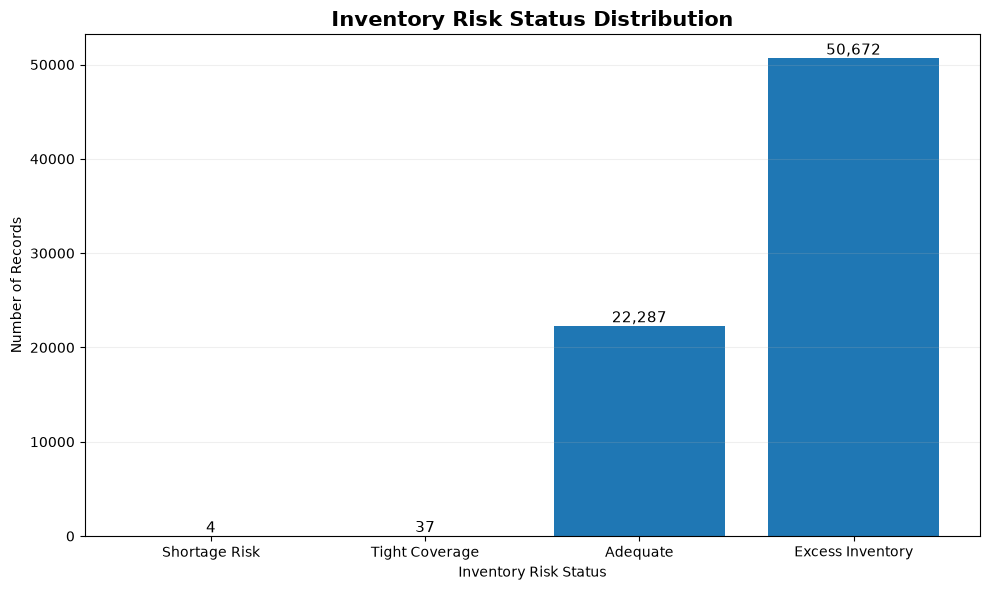


PRODUCT-LEVEL INVENTORY RISK
---------------------------------------------------------------------------


,Product ID,Records,Shortage_Risk_Records,Tight_Coverage_Records,Excess_Inventory_Records,Total_Recommended_Replenishment,Average_Inventory_Gap,Shortage_Risk_Rate_%,Excess_Rate_%,ABC_XYZ_Segment
0,P0008,"3,650",1,1,"2,557",3,237.36,0.03%,70.05%,BZ
1,P0009,"3,650",1,2,"2,509",2,234.91,0.03%,68.74%,AZ
2,P0019,"3,650",1,4,"2,535",2,235.84,0.03%,69.45%,AX
3,P0016,"3,650",1,3,"2,518",1,235.89,0.03%,68.99%,AX
4,P0001,"3,650",0,3,"2,542",0,236.16,0.00%,69.64%,AY
5,P0002,"3,650",0,3,"2,565",0,235.63,0.00%,70.27%,CY
6,P0003,"3,650",0,1,"2,564",0,237.95,0.00%,70.25%,BX
7,P0004,"3,650",0,3,"2,510",0,231.71,0.00%,68.77%,AX
8,P0005,"3,650",0,1,"2,514",0,232.86,0.00%,68.88%,AY
9,P0006,"3,650",0,0,"2,556",0,233.97,0.00%,70.03%,AX



TOP 20 HISTORICAL SHORTAGE-RISK CASES
---------------------------------------------------------------------------


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Ordered,Inventory_Position,Clipped_Forecast,Safety_Buffer,Risk_Adjusted_Demand,Inventory_Gap,Recommended_Replenishment
23527,2022-08-24 00:00:00,S002,P0008,Clothing,South,115,20,135,130.82,7,137.82,-2.82,3
5378,2022-02-23 00:00:00,S004,P0019,Toys,East,391,22,413,406.99,8,414.99,-1.99,2
11928,2022-04-30 00:00:00,S002,P0009,Clothing,East,107,22,129,123.26,7,130.26,-1.26,2
47255,2023-04-18 00:00:00,S003,P0016,Electronics,West,399,20,419,411.98,8,419.98,-0.98,1



INVENTORY DECISION-SUPPORT KPIs
---------------------------------------------------------------------------
Shortage-risk records              : 4 (0.01%)
Excess-inventory records           : 50,672 (69.41%)
Historical additional replenishment: 8 units
Average recommended replenishment for shortage cases: 2.00 units

Methodology:
Inventory Position = Inventory Level + Units Ordered
Risk-Adjusted Demand = Supplied Forecast + product-specific 90% underforecast buffer
Recommended Replenishment = max(Risk-Adjusted Demand - Inventory Position, 0)

Note: These are historical decision-support estimates. They are not optimized purchase orders because supplier lead time, ordering cost, holding cost, MOQ, and service-level targets are not available in the dataset.


In [24]:
# ============================================================
# CELL 22: INVENTORY RISK, SHORTAGE
#          & REPLENISHMENT ANALYSIS
# ============================================================

print("=" * 75)
print("INVENTORY RISK, SHORTAGE & REPLENISHMENT ANALYSIS")
print("=" * 75)


# ------------------------------------------------------------
# 1. Create Inventory Decision Dataset
# ------------------------------------------------------------
inventory_risk = forecast_eval.copy()


# ------------------------------------------------------------
# 2. Attach Product-Specific 90% Safety Buffers
# ------------------------------------------------------------
product_buffer_map = (
    product_forecast_accuracy
    .set_index("Product ID")["Safety_Buffer_90"]
)

inventory_risk["Safety_Buffer"] = (
    inventory_risk["Product ID"]
    .map(product_buffer_map)
    .fillna(global_safety_buffer_90)
    .astype(int)
)


# ------------------------------------------------------------
# 3. Inventory Position
#
# Inventory Position = Current Inventory + Units Already Ordered
# ------------------------------------------------------------
inventory_risk["Inventory_Position"] = (
    inventory_risk["Inventory Level"]
    + inventory_risk["Units Ordered"]
)


# ------------------------------------------------------------
# 4. Risk-Adjusted Demand Requirement
#
# Required Stock =
# Supplied Forecast + Product-Specific Safety Buffer
# ------------------------------------------------------------
inventory_risk["Risk_Adjusted_Demand"] = (
    inventory_risk["Clipped_Forecast"]
    + inventory_risk["Safety_Buffer"]
)


# ------------------------------------------------------------
# 5. Inventory Gap
#
# Positive = surplus after covering expected demand
# Negative = shortage exposure
# ------------------------------------------------------------
inventory_risk["Inventory_Gap"] = (
    inventory_risk["Inventory_Position"]
    - inventory_risk["Risk_Adjusted_Demand"]
)


# ------------------------------------------------------------
# 6. Recommended Additional Replenishment
#
# Only additional quantity beyond current inventory
# and already-ordered units.
# ------------------------------------------------------------
inventory_risk["Recommended_Replenishment"] = np.ceil(
    np.maximum(
        inventory_risk["Risk_Adjusted_Demand"]
        - inventory_risk["Inventory_Position"],
        0
    )
).astype(int)


# ------------------------------------------------------------
# 7. Inventory Risk Classification
#
# Shortage Risk:
# Inventory position cannot cover risk-adjusted demand.
#
# Tight Coverage:
# Inventory covers requirement but remaining surplus
# is <= one safety buffer.
#
# Adequate:
# Surplus is greater than one buffer but does not
# exceed the entire risk-adjusted requirement.
#
# Excess:
# Surplus exceeds the full risk-adjusted requirement,
# meaning inventory position > 2 × required stock.
# ------------------------------------------------------------
conditions = [
    inventory_risk["Inventory_Gap"] < 0,

    (
        (inventory_risk["Inventory_Gap"] >= 0)
        &
        (
            inventory_risk["Inventory_Gap"]
            <= inventory_risk["Safety_Buffer"]
        )
    ),

    (
        inventory_risk["Inventory_Gap"]
        > inventory_risk["Risk_Adjusted_Demand"]
    )
]

choices = [
    "Shortage Risk",
    "Tight Coverage",
    "Excess Inventory"
]

inventory_risk["Inventory_Risk_Status"] = np.select(
    conditions,
    choices,
    default="Adequate"
)


# ------------------------------------------------------------
# 8. Risk Summary
# ------------------------------------------------------------
risk_order = [
    "Shortage Risk",
    "Tight Coverage",
    "Adequate",
    "Excess Inventory"
]

risk_summary = (
    inventory_risk
    .groupby(
        "Inventory_Risk_Status",
        as_index=False
    )
    .agg(
        Records=("Product ID", "size"),

        Average_Inventory=(
            "Inventory Level",
            "mean"
        ),

        Average_Units_Ordered=(
            "Units Ordered",
            "mean"
        ),

        Average_Forecast=(
            "Clipped_Forecast",
            "mean"
        ),

        Average_Inventory_Position=(
            "Inventory_Position",
            "mean"
        ),

        Total_Recommended_Replenishment=(
            "Recommended_Replenishment",
            "sum"
        )
    )
)

risk_summary["Record_Share_%"] = (
    risk_summary["Records"]
    / len(inventory_risk)
    * 100
)

risk_summary["Inventory_Risk_Status"] = pd.Categorical(
    risk_summary["Inventory_Risk_Status"],
    categories=risk_order,
    ordered=True
)

risk_summary = (
    risk_summary
    .sort_values("Inventory_Risk_Status")
    .reset_index(drop=True)
)


print("\nINVENTORY RISK SUMMARY")
print("-" * 75)

display(
    risk_summary.style.format({
        "Records": "{:,.0f}",
        "Average_Inventory": "{:,.2f}",
        "Average_Units_Ordered": "{:,.2f}",
        "Average_Forecast": "{:,.2f}",
        "Average_Inventory_Position": "{:,.2f}",
        "Total_Recommended_Replenishment": "{:,.0f}",
        "Record_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 9. Visualize Inventory Risk Distribution
# ------------------------------------------------------------
risk_counts = (
    inventory_risk["Inventory_Risk_Status"]
    .value_counts()
    .reindex(risk_order, fill_value=0)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    risk_counts.index,
    risk_counts.values
)

for bar, value in zip(bars, risk_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title(
    "Inventory Risk Status Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Inventory Risk Status")
plt.ylabel("Number of Records")
plt.grid(axis="y", alpha=0.20)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Product-Level Risk Summary
# ------------------------------------------------------------
product_risk_summary = (
    inventory_risk
    .groupby("Product ID", as_index=False)
    .agg(
        Records=("Product ID", "size"),

        Shortage_Risk_Records=(
            "Inventory_Risk_Status",
            lambda x: (x == "Shortage Risk").sum()
        ),

        Tight_Coverage_Records=(
            "Inventory_Risk_Status",
            lambda x: (x == "Tight Coverage").sum()
        ),

        Excess_Inventory_Records=(
            "Inventory_Risk_Status",
            lambda x: (x == "Excess Inventory").sum()
        ),

        Total_Recommended_Replenishment=(
            "Recommended_Replenishment",
            "sum"
        ),

        Average_Inventory_Gap=(
            "Inventory_Gap",
            "mean"
        )
    )
)

product_risk_summary["Shortage_Risk_Rate_%"] = (
    product_risk_summary["Shortage_Risk_Records"]
    / product_risk_summary["Records"]
    * 100
)

product_risk_summary["Excess_Rate_%"] = (
    product_risk_summary["Excess_Inventory_Records"]
    / product_risk_summary["Records"]
    * 100
)


# ------------------------------------------------------------
# 11. Attach ABC-XYZ Segment
# ------------------------------------------------------------
segment_map = (
    abc_xyz
    .set_index("Product ID")["ABC_XYZ_Segment"]
)

product_risk_summary["ABC_XYZ_Segment"] = (
    product_risk_summary["Product ID"]
    .map(segment_map)
)

product_risk_summary = (
    product_risk_summary
    .sort_values(
        [
            "Shortage_Risk_Rate_%",
            "Total_Recommended_Replenishment"
        ],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)


print("\nPRODUCT-LEVEL INVENTORY RISK")
print("-" * 75)

display(
    product_risk_summary.style.format({
        "Records": "{:,.0f}",
        "Shortage_Risk_Records": "{:,.0f}",
        "Tight_Coverage_Records": "{:,.0f}",
        "Excess_Inventory_Records": "{:,.0f}",
        "Total_Recommended_Replenishment": "{:,.0f}",
        "Average_Inventory_Gap": "{:,.2f}",
        "Shortage_Risk_Rate_%": "{:.2f}%",
        "Excess_Rate_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 12. Highest-Priority Historical Shortage Cases
# ------------------------------------------------------------
priority_shortages = (
    inventory_risk[
        inventory_risk["Inventory_Risk_Status"]
        == "Shortage Risk"
    ][
        [
            "Date",
            "Store ID",
            "Product ID",
            "Category",
            "Region",
            "Inventory Level",
            "Units Ordered",
            "Inventory_Position",
            "Clipped_Forecast",
            "Safety_Buffer",
            "Risk_Adjusted_Demand",
            "Inventory_Gap",
            "Recommended_Replenishment"
        ]
    ]
    .sort_values(
        "Recommended_Replenishment",
        ascending=False
    )
    .head(20)
)


print("\nTOP 20 HISTORICAL SHORTAGE-RISK CASES")
print("-" * 75)

display(
    priority_shortages.style.format({
        "Inventory Level": "{:,.0f}",
        "Units Ordered": "{:,.0f}",
        "Inventory_Position": "{:,.0f}",
        "Clipped_Forecast": "{:,.2f}",
        "Safety_Buffer": "{:,.0f}",
        "Risk_Adjusted_Demand": "{:,.2f}",
        "Inventory_Gap": "{:,.2f}",
        "Recommended_Replenishment": "{:,.0f}"
    })
)


# ------------------------------------------------------------
# 13. Overall Decision-Support KPIs
# ------------------------------------------------------------
shortage_records = (
    inventory_risk["Inventory_Risk_Status"]
    == "Shortage Risk"
).sum()

excess_records = (
    inventory_risk["Inventory_Risk_Status"]
    == "Excess Inventory"
).sum()

total_replenishment = (
    inventory_risk["Recommended_Replenishment"]
    .sum()
)


print("\nINVENTORY DECISION-SUPPORT KPIs")
print("-" * 75)

print(
    f"Shortage-risk records              : "
    f"{shortage_records:,} "
    f"({shortage_records / len(inventory_risk) * 100:.2f}%)"
)

print(
    f"Excess-inventory records           : "
    f"{excess_records:,} "
    f"({excess_records / len(inventory_risk) * 100:.2f}%)"
)

print(
    f"Historical additional replenishment: "
    f"{total_replenishment:,.0f} units"
)

print(
    f"Average recommended replenishment "
    f"for shortage cases: "
    f"{inventory_risk.loc[inventory_risk['Recommended_Replenishment'] > 0, 'Recommended_Replenishment'].mean():.2f} units"
)

print(
    "\nMethodology:"
)

print(
    "Inventory Position = Inventory Level + Units Ordered"
)

print(
    "Risk-Adjusted Demand = Supplied Forecast + "
    "product-specific 90% underforecast buffer"
)

print(
    "Recommended Replenishment = max("
    "Risk-Adjusted Demand - Inventory Position, 0)"
)

print(
    "\nNote: These are historical decision-support estimates. "
    "They are not optimized purchase orders because supplier "
    "lead time, ordering cost, holding cost, MOQ, and service-level "
    "targets are not available in the dataset."
)

### CELL 23 — Machine Learning Dataset Preparation & Leakage Control

In [25]:
# ============================================================
# CELL 23: MACHINE LEARNING DATASET PREPARATION
#          & LEAKAGE CONTROL — CORRECTED
# ============================================================

print("=" * 75)
print("MACHINE LEARNING DATASET PREPARATION & LEAKAGE CONTROL")
print("=" * 75)


# ------------------------------------------------------------
# 1. Create ML Dataset from Original Clean Data
# ------------------------------------------------------------
ml_df = df.copy()


# ------------------------------------------------------------
# 2. Ensure Date is Datetime
# ------------------------------------------------------------
ml_df["Date"] = pd.to_datetime(
    ml_df["Date"],
    errors="coerce"
)

invalid_dates = ml_df["Date"].isna().sum()

print("\nDATE CONVERSION CHECK")
print("-" * 75)
print(f"Invalid / missing dates after conversion : {invalid_dates:,}")

if invalid_dates > 0:
    raise ValueError(
        "Date conversion produced invalid dates. "
        "Inspect the Date column before continuing."
    )


# Sort chronologically
ml_df = (
    ml_df
    .sort_values("Date")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 3. Target Variable
# ------------------------------------------------------------
target_column = "Units Sold"


# ------------------------------------------------------------
# 4. Create Calendar Features
# ------------------------------------------------------------
ml_df["Year"] = ml_df["Date"].dt.year
ml_df["Month"] = ml_df["Date"].dt.month
ml_df["Day"] = ml_df["Date"].dt.day
ml_df["Day_of_Week"] = ml_df["Date"].dt.dayofweek

ml_df["Week_of_Year"] = (
    ml_df["Date"]
    .dt
    .isocalendar()
    .week
    .astype(int)
)

ml_df["Quarter"] = ml_df["Date"].dt.quarter

ml_df["Is_Weekend"] = (
    ml_df["Day_of_Week"] >= 5
).astype(int)


# ------------------------------------------------------------
# 5. Price-Derived Features
# ------------------------------------------------------------
ml_df["Effective_Price"] = (
    ml_df["Price"]
    * (1 - ml_df["Discount"] / 100)
)

ml_df["Competitor_Price_Gap"] = (
    ml_df["Price"]
    - ml_df["Competitor Pricing"]
)

ml_df["Competitor_Price_Ratio"] = (
    ml_df["Price"]
    / ml_df["Competitor Pricing"].replace(0, np.nan)
)


# ------------------------------------------------------------
# 6. Explicit Leakage / Decision-Time Exclusions
# ------------------------------------------------------------
#
# Demand Forecast:
# Existing supplied forecast. Reserved as an external
# benchmark and NOT used to train our model.
#
# Units Ordered:
# Replenishment decisions may themselves depend on expected
# demand, so this variable is excluded from forecasting.
#
# Date:
# Raw datetime is replaced by calendar-derived features.
#
# Units Sold:
# Prediction target.
# ------------------------------------------------------------

excluded_columns = [
    "Date",
    "Units Sold",
    "Demand Forecast",
    "Units Ordered"
]


# ------------------------------------------------------------
# 7. Define Candidate Model Features
# ------------------------------------------------------------
candidate_features = [
    # Business identifiers
    "Store ID",
    "Product ID",
    "Category",
    "Region",

    # Operational variables
    "Inventory Level",

    # Pricing variables
    "Price",
    "Discount",
    "Competitor Pricing",

    # External / contextual variables
    "Weather Condition",
    "Holiday/Promotion",
    "Seasonality",

    # Calendar features
    "Year",
    "Month",
    "Day",
    "Day_of_Week",
    "Week_of_Year",
    "Quarter",
    "Is_Weekend",

    # Engineered pricing features
    "Effective_Price",
    "Competitor_Price_Gap",
    "Competitor_Price_Ratio"
]


# Keep only columns that actually exist
feature_columns = [
    column
    for column in candidate_features
    if column in ml_df.columns
]


X = ml_df[feature_columns].copy()
y = ml_df[target_column].copy()


# ------------------------------------------------------------
# 8. Identify Numeric and Categorical Features
# ------------------------------------------------------------
numeric_features = (
    X.select_dtypes(
        include=["number", "bool"]
    )
    .columns
    .tolist()
)

categorical_features = (
    X.select_dtypes(
        include=["object", "category"]
    )
    .columns
    .tolist()
)


# ------------------------------------------------------------
# 9. ML Dataset Overview
# ------------------------------------------------------------
print("\nML DATASET OVERVIEW")
print("-" * 75)

print(f"Records available        : {len(ml_df):,}")
print(f"Target variable          : {target_column}")
print(f"Number of model features : {len(feature_columns)}")
print(f"Numeric features         : {len(numeric_features)}")
print(f"Categorical features     : {len(categorical_features)}")


print("\nDATE RANGE")
print("-" * 75)

print(f"Start date : {ml_df['Date'].min().date()}")
print(f"End date   : {ml_df['Date'].max().date()}")


# ------------------------------------------------------------
# 10. Feature Lists
# ------------------------------------------------------------
print("\nNUMERIC FEATURES")
print("-" * 75)

for feature in numeric_features:
    print(f"- {feature}")


print("\nCATEGORICAL FEATURES")
print("-" * 75)

for feature in categorical_features:
    print(f"- {feature}")


# ------------------------------------------------------------
# 11. Leakage Audit
# ------------------------------------------------------------
print("\nLEAKAGE / DECISION-TIME EXCLUSIONS")
print("-" * 75)

for column in excluded_columns:
    print(f"- {column}")


leakage_check = [
    column
    for column in [
        "Demand Forecast",
        "Units Ordered"
    ]
    if column in X.columns
]

if len(leakage_check) == 0:
    print(
        "\nLeakage check PASSED: "
        "Demand Forecast and Units Ordered are not model inputs."
    )
else:
    print(
        "\nWARNING: Potential leakage columns found:",
        leakage_check
    )


# ------------------------------------------------------------
# 12. Duplicate Feature Check
# ------------------------------------------------------------
duplicate_features = (
    pd.Index(feature_columns)
    .duplicated()
    .sum()
)

print("\nFEATURE VALIDATION")
print("-" * 75)

print(f"Duplicate model features : {duplicate_features}")
print(f"X shape                  : {X.shape}")
print(f"y shape                  : {y.shape}")


# ------------------------------------------------------------
# 13. Missing-Value Check
# ------------------------------------------------------------
missing_features = (
    X.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_features = missing_features[
    missing_features > 0
]


print("\nMISSING VALUES IN MODEL FEATURES")
print("-" * 75)

if len(missing_features) == 0:
    print("No missing values detected.")
else:
    display(
        missing_features.to_frame(
            "Missing_Values"
        )
    )


# ------------------------------------------------------------
# 14. Target Validation
# ------------------------------------------------------------
print("\nTARGET VALIDATION")
print("-" * 75)

print(f"Missing target values : {y.isna().sum():,}")
print(f"Minimum Units Sold    : {y.min():,.0f}")
print(f"Maximum Units Sold    : {y.max():,.0f}")
print(f"Average Units Sold    : {y.mean():,.2f}")


# ------------------------------------------------------------
# 15. Preview Modeling Dataset
# ------------------------------------------------------------
print("\nMODEL DATA PREVIEW")
print("-" * 75)

display(
    ml_df[
        ["Date"] + feature_columns + [target_column]
    ].head()
)


# ------------------------------------------------------------
# 16. Modeling Methodology
# ------------------------------------------------------------
print("\nIMPORTANT MODELING NOTE")
print("-" * 75)

print(
    "The supplied Demand Forecast is excluded from training "
    "and retained only as an external benchmark."
)

print(
    "Units Ordered is excluded because replenishment decisions "
    "may encode prior demand expectations."
)

print(
    "The next stage will use a chronological train/test split "
    "rather than a random split."
)

MACHINE LEARNING DATASET PREPARATION & LEAKAGE CONTROL

DATE CONVERSION CHECK
---------------------------------------------------------------------------
Invalid / missing dates after conversion : 0

ML DATASET OVERVIEW
---------------------------------------------------------------------------
Records available        : 73,100
Target variable          : Units Sold
Number of model features : 21
Numeric features         : 15
Categorical features     : 6

DATE RANGE
---------------------------------------------------------------------------
Start date : 2022-01-01
End date   : 2024-01-01

NUMERIC FEATURES
---------------------------------------------------------------------------
- Inventory Level
- Price
- Discount
- Competitor Pricing
- Holiday/Promotion
- Year
- Month
- Day
- Day_of_Week
- Week_of_Year
- Quarter
- Is_Weekend
- Effective_Price
- Competitor_Price_Gap
- Competitor_Price_Ratio

CATEGORICAL FEATURES
--------------------------------------------------------------------------

,Date,Store ID,Product ID,Category,Region,Inventory Level,Price,Discount,Competitor Pricing,Weather Condition,Holiday/Promotion,Seasonality,Year,Month,Day,Day_of_Week,Week_of_Year,Quarter,Is_Weekend,Effective_Price,Competitor_Price_Gap,Competitor_Price_Ratio,Units Sold
0,2022-01-01,S001,P0001,Groceries,North,231,33.50,20,29.69,Rainy,0,Autumn,2022,1,1,5,52,1,1,26.80,3.81,1.13,127
1,2022-01-01,S004,P0013,Furniture,East,191,61.81,0,63.92,Sunny,0,Autumn,2022,1,1,5,52,1,1,61.81,-2.11,0.97,56
2,2022-01-01,S004,P0012,Electronics,North,349,14.25,5,18.56,Rainy,1,Spring,2022,1,1,5,52,1,1,13.54,-4.31,0.77,9
3,2022-01-01,S004,P0011,Electronics,West,205,54.84,0,57.76,Sunny,1,Spring,2022,1,1,5,52,1,1,54.84,-2.92,0.95,46
4,2022-01-01,S004,P0010,Groceries,East,447,33.48,15,37.15,Cloudy,0,Summer,2022,1,1,5,52,1,1,28.46,-3.67,0.90,104



IMPORTANT MODELING NOTE
---------------------------------------------------------------------------
The supplied Demand Forecast is excluded from training and retained only as an external benchmark.
Units Ordered is excluded because replenishment decisions may encode prior demand expectations.
The next stage will use a chronological train/test split rather than a random split.


### CELL 24 — Chronological Train/Test Split & Preprocessing

In [26]:
# ============================================================
# CELL 24: CHRONOLOGICAL TRAIN/TEST SPLIT
#          & PREPROCESSING PIPELINE
# ============================================================

print("=" * 75)
print("CHRONOLOGICAL TRAIN/TEST SPLIT & PREPROCESSING SETUP")
print("=" * 75)


# ------------------------------------------------------------
# 1. Define Time-Based Modeling Window
# ------------------------------------------------------------
#
# Training:
# 2022-01-01 through 2023-09-30
#
# Testing:
# 2023-10-01 through 2023-12-31
#
# 2024-01-01 is excluded because January 2024 contains
# only one observed day in this dataset.
# ------------------------------------------------------------

train_end_date = pd.Timestamp("2023-09-30")
test_start_date = pd.Timestamp("2023-10-01")
test_end_date = pd.Timestamp("2023-12-31")


train_mask = (
    ml_df["Date"] <= train_end_date
)

test_mask = (
    (ml_df["Date"] >= test_start_date)
    & (ml_df["Date"] <= test_end_date)
)


X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

train_dates = ml_df.loc[train_mask, "Date"].copy()
test_dates = ml_df.loc[test_mask, "Date"].copy()


# ------------------------------------------------------------
# 2. Validate Split
# ------------------------------------------------------------
print("\nTIME-BASED SPLIT")
print("-" * 75)

print(
    f"Training period : "
    f"{train_dates.min().date()} to "
    f"{train_dates.max().date()}"
)

print(
    f"Testing period  : "
    f"{test_dates.min().date()} to "
    f"{test_dates.max().date()}"
)

print(
    f"Training records: {len(X_train):,}"
)

print(
    f"Testing records : {len(X_test):,}"
)

print(
    f"Excluded records: "
    f"{len(ml_df) - len(X_train) - len(X_test):,}"
)


# ------------------------------------------------------------
# 3. Chronology Validation
# ------------------------------------------------------------
chronology_passed = (
    train_dates.max() < test_dates.min()
)

print("\nCHRONOLOGY VALIDATION")
print("-" * 75)

print(
    f"Latest training date : {train_dates.max().date()}"
)

print(
    f"Earliest testing date: {test_dates.min().date()}"
)

print(
    "Chronological separation:",
    "PASSED" if chronology_passed else "FAILED"
)

if not chronology_passed:
    raise ValueError(
        "Training and testing periods overlap."
    )


# ------------------------------------------------------------
# 4. Target Distribution Comparison
# ------------------------------------------------------------
target_split_summary = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],
    "Records": [
        len(y_train),
        len(y_test)
    ],
    "Average_Units_Sold": [
        y_train.mean(),
        y_test.mean()
    ],
    "Median_Units_Sold": [
        y_train.median(),
        y_test.median()
    ],
    "Std_Units_Sold": [
        y_train.std(),
        y_test.std()
    ],
    "Minimum_Units_Sold": [
        y_train.min(),
        y_test.min()
    ],
    "Maximum_Units_Sold": [
        y_train.max(),
        y_test.max()
    ]
})

print("\nTARGET DISTRIBUTION BY SPLIT")
print("-" * 75)

display(
    target_split_summary.style.format({
        "Records": "{:,.0f}",
        "Average_Units_Sold": "{:,.2f}",
        "Median_Units_Sold": "{:,.2f}",
        "Std_Units_Sold": "{:,.2f}",
        "Minimum_Units_Sold": "{:,.0f}",
        "Maximum_Units_Sold": "{:,.0f}"
    })
)


# ------------------------------------------------------------
# 5. Import Preprocessing Components
# ------------------------------------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


# ------------------------------------------------------------
# 6. Numeric Preprocessing
# ------------------------------------------------------------
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)


# ------------------------------------------------------------
# 7. Categorical Preprocessing
# ------------------------------------------------------------
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ------------------------------------------------------------
# 8. Combined Preprocessor
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)


# ------------------------------------------------------------
# 9. Fit Preprocessor on TRAINING DATA ONLY
# ------------------------------------------------------------
preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)


# ------------------------------------------------------------
# 10. Processed Feature Validation
# ------------------------------------------------------------
print("\nPREPROCESSING VALIDATION")
print("-" * 75)

print(
    f"Original feature count : "
    f"{X_train.shape[1]}"
)

print(
    f"Processed feature count: "
    f"{X_train_processed.shape[1]}"
)

print(
    f"Processed train shape  : "
    f"{X_train_processed.shape}"
)

print(
    f"Processed test shape   : "
    f"{X_test_processed.shape}"
)


# ------------------------------------------------------------
# 11. Retrieve Final Feature Names
# ------------------------------------------------------------
processed_feature_names = (
    preprocessor.get_feature_names_out()
)

print(
    f"Feature names recovered: "
    f"{len(processed_feature_names)}"
)


print("\nFIRST 25 PROCESSED FEATURES")
print("-" * 75)

for feature in processed_feature_names[:25]:
    print(f"- {feature}")


# ------------------------------------------------------------
# 12. Final Validation
# ------------------------------------------------------------
print("\nFINAL SPLIT VALIDATION")
print("-" * 75)

print(
    "Training target aligned:",
    len(X_train) == len(y_train)
)

print(
    "Testing target aligned :",
    len(X_test) == len(y_test)
)

print(
    "Train/test feature count identical:",
    X_train_processed.shape[1]
    == X_test_processed.shape[1]
)


print("\nMODELING SETUP NOTE")
print("-" * 75)

print(
    "The preprocessing pipeline was fitted only on historical "
    "training data to avoid information leakage."
)

print(
    "October-December 2023 is reserved as an unseen "
    "chronological test period."
)

print(
    "The incomplete 2024-01-01 period is excluded from "
    "model evaluation."
)

CHRONOLOGICAL TRAIN/TEST SPLIT & PREPROCESSING SETUP

TIME-BASED SPLIT
---------------------------------------------------------------------------
Training period : 2022-01-01 to 2023-09-30
Testing period  : 2023-10-01 to 2023-12-31
Training records: 63,800
Testing records : 9,200
Excluded records: 100

CHRONOLOGY VALIDATION
---------------------------------------------------------------------------
Latest training date : 2023-09-30
Earliest testing date: 2023-10-01
Chronological separation: PASSED

TARGET DISTRIBUTION BY SPLIT
---------------------------------------------------------------------------


,Dataset,Records,Average_Units_Sold,Median_Units_Sold,Std_Units_Sold,Minimum_Units_Sold,Maximum_Units_Sold
0,Training,"63,800",136.39,107.00,109.03,0,499
1,Testing,"9,200",137.00,108.00,108.15,0,494



PREPROCESSING VALIDATION
---------------------------------------------------------------------------
Original feature count : 21
Processed feature count: 57
Processed train shape  : (63800, 57)
Processed test shape   : (9200, 57)
Feature names recovered: 57

FIRST 25 PROCESSED FEATURES
---------------------------------------------------------------------------
- numeric__Inventory Level
- numeric__Price
- numeric__Discount
- numeric__Competitor Pricing
- numeric__Holiday/Promotion
- numeric__Year
- numeric__Month
- numeric__Day
- numeric__Day_of_Week
- numeric__Week_of_Year
- numeric__Quarter
- numeric__Is_Weekend
- numeric__Effective_Price
- numeric__Competitor_Price_Gap
- numeric__Competitor_Price_Ratio
- categorical__Store ID_S001
- categorical__Store ID_S002
- categorical__Store ID_S003
- categorical__Store ID_S004
- categorical__Store ID_S005
- categorical__Product ID_P0001
- categorical__Product ID_P0002
- categorical__Product ID_P0003
- categorical__Product ID_P0004
- categoric

### CELL 25 — Linear Regression Baseline

LINEAR REGRESSION BASELINE - DEMAND FORECASTING

MODEL TRAINING
---------------------------------------------------------------------------
Training records : 63,800
Model features   : 57
Linear Regression training completed successfully.

LINEAR REGRESSION PERFORMANCE
---------------------------------------------------------------------------


,Dataset,MAE,RMSE,R2
0,Training,68.831,87.930,0.3496
1,Testing,68.946,87.923,0.3390



GENERALIZATION CHECK
---------------------------------------------------------------------------
Train MAE : 68.831
Test MAE  : 68.946
MAE gap   : +0.115

Train RMSE: 87.930
Test RMSE : 87.923
RMSE gap  : -0.008

TEST PREDICTION SUMMARY
---------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
Actual,"9,200.00",137.00,108.15,0.00,50.00,108.00,204.25,494.00
Predicted,"9,200.00",136.21,64.79,20.13,79.94,135.79,192.20,251.00


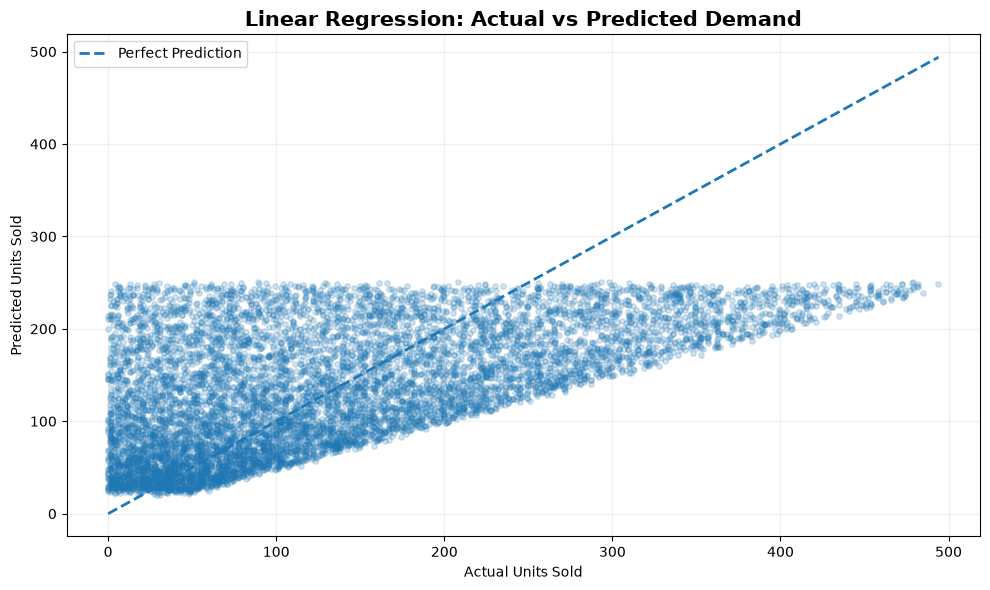

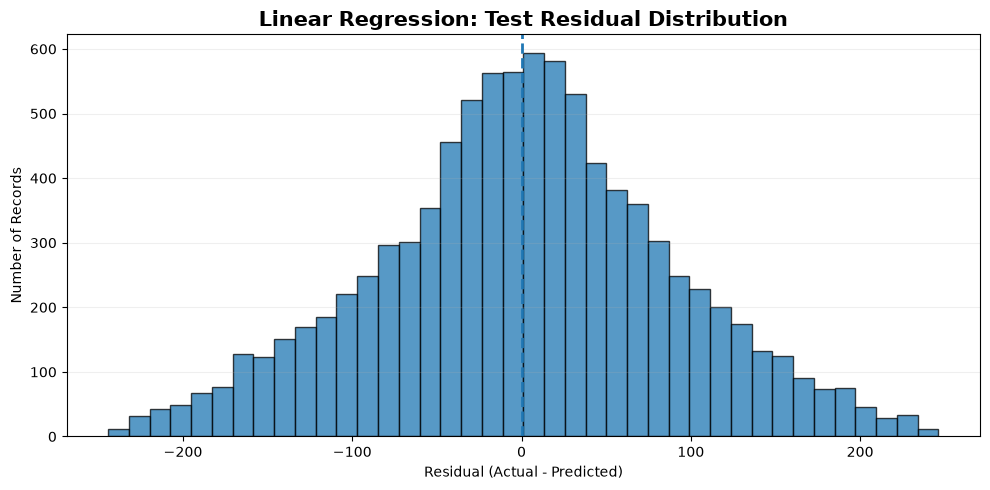


RESIDUAL DIAGNOSTICS
---------------------------------------------------------------------------
Mean residual   : +0.791
Median residual : +1.930
Residual std    : 87.919

MODEL RESULT SAVED FOR LATER COMPARISON
---------------------------------------------------------------------------


,Model,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_R2,Test_R2
0,Linear Regression,68.831,68.946,87.930,87.923,0.3496,0.3390



BASELINE MODEL NOTE
---------------------------------------------------------------------------
Linear Regression is being used as the interpretable baseline for demand forecasting.
Its performance will be compared with non-linear tree-based models in the next stages.
The supplied Demand Forecast remains excluded from all model inputs.


In [27]:
# ============================================================
# CELL 25: LINEAR REGRESSION BASELINE MODEL
# ============================================================

print("=" * 75)
print("LINEAR REGRESSION BASELINE - DEMAND FORECASTING")
print("=" * 75)


# ------------------------------------------------------------
# 1. Import Model & Evaluation Metrics
# ------------------------------------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ------------------------------------------------------------
# 2. Train Linear Regression
# ------------------------------------------------------------
linear_model = LinearRegression()

linear_model.fit(
    X_train_processed,
    y_train
)


print("\nMODEL TRAINING")
print("-" * 75)

print(
    f"Training records : {len(y_train):,}"
)

print(
    f"Model features   : {X_train_processed.shape[1]}"
)

print(
    "Linear Regression training completed successfully."
)


# ------------------------------------------------------------
# 3. Generate Predictions
# ------------------------------------------------------------
linear_train_pred = linear_model.predict(
    X_train_processed
)

linear_test_pred = linear_model.predict(
    X_test_processed
)


# ------------------------------------------------------------
# 4. Calculate Evaluation Metrics
# ------------------------------------------------------------
linear_train_mae = mean_absolute_error(
    y_train,
    linear_train_pred
)

linear_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        linear_train_pred
    )
)

linear_train_r2 = r2_score(
    y_train,
    linear_train_pred
)


linear_test_mae = mean_absolute_error(
    y_test,
    linear_test_pred
)

linear_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_test_pred
    )
)

linear_test_r2 = r2_score(
    y_test,
    linear_test_pred
)


# ------------------------------------------------------------
# 5. Model Performance Table
# ------------------------------------------------------------
linear_performance = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],
    "MAE": [
        linear_train_mae,
        linear_test_mae
    ],
    "RMSE": [
        linear_train_rmse,
        linear_test_rmse
    ],
    "R2": [
        linear_train_r2,
        linear_test_r2
    ]
})


print("\nLINEAR REGRESSION PERFORMANCE")
print("-" * 75)

display(
    linear_performance.style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "R2": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 6. Generalization Gap
# ------------------------------------------------------------
print("\nGENERALIZATION CHECK")
print("-" * 75)

print(
    f"Train MAE : {linear_train_mae:.3f}"
)

print(
    f"Test MAE  : {linear_test_mae:.3f}"
)

print(
    f"MAE gap   : "
    f"{linear_test_mae - linear_train_mae:+.3f}"
)

print()

print(
    f"Train RMSE: {linear_train_rmse:.3f}"
)

print(
    f"Test RMSE : {linear_test_rmse:.3f}"
)

print(
    f"RMSE gap  : "
    f"{linear_test_rmse - linear_train_rmse:+.3f}"
)


# ------------------------------------------------------------
# 7. Prediction Summary
# ------------------------------------------------------------
prediction_summary = pd.DataFrame({
    "Actual": y_test,
    "Predicted": linear_test_pred
})


print("\nTEST PREDICTION SUMMARY")
print("-" * 75)

display(
    prediction_summary.describe().T.style.format(
        "{:,.2f}"
    )
)


# ------------------------------------------------------------
# 8. Actual vs Predicted Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    linear_test_pred,
    alpha=0.20,
    s=15
)

plot_min = min(
    y_test.min(),
    linear_test_pred.min()
)

plot_max = max(
    y_test.max(),
    linear_test_pred.max()
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")

plt.title(
    "Linear Regression: Actual vs Predicted Demand",
    fontsize=15,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Residual Analysis
# ------------------------------------------------------------
linear_residuals = (
    y_test.to_numpy()
    - linear_test_pred
)


plt.figure(figsize=(10, 5))

plt.hist(
    linear_residuals,
    bins=40,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Number of Records")

plt.title(
    "Linear Regression: Test Residual Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Residual Statistics
# ------------------------------------------------------------
print("\nRESIDUAL DIAGNOSTICS")
print("-" * 75)

print(
    f"Mean residual   : "
    f"{linear_residuals.mean():+.3f}"
)

print(
    f"Median residual : "
    f"{np.median(linear_residuals):+.3f}"
)

print(
    f"Residual std    : "
    f"{linear_residuals.std():.3f}"
)


# ------------------------------------------------------------
# 11. Store Result for Later Model Comparison
# ------------------------------------------------------------
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression"
    ],
    "Train_MAE": [
        linear_train_mae
    ],
    "Test_MAE": [
        linear_test_mae
    ],
    "Train_RMSE": [
        linear_train_rmse
    ],
    "Test_RMSE": [
        linear_test_rmse
    ],
    "Train_R2": [
        linear_train_r2
    ],
    "Test_R2": [
        linear_test_r2
    ]
})


print("\nMODEL RESULT SAVED FOR LATER COMPARISON")
print("-" * 75)

display(
    model_results.style.format({
        "Train_MAE": "{:.3f}",
        "Test_MAE": "{:.3f}",
        "Train_RMSE": "{:.3f}",
        "Test_RMSE": "{:.3f}",
        "Train_R2": "{:.4f}",
        "Test_R2": "{:.4f}"
    })
)


print("\nBASELINE MODEL NOTE")
print("-" * 75)

print(
    "Linear Regression is being used as the interpretable "
    "baseline for demand forecasting."
)

print(
    "Its performance will be compared with non-linear "
    "tree-based models in the next stages."
)

print(
    "The supplied Demand Forecast remains excluded from "
    "all model inputs."
)

### Cell 26 — Random Forest Regressor

RANDOM FOREST REGRESSOR - DEMAND FORECASTING

MODEL CONFIGURATION
---------------------------------------------------------------------------
Estimators        : 200
Maximum depth     : 18
Minimum split     : 5
Minimum leaf size : 2
Maximum features  : sqrt
Parallel CPU use  : Enabled

MODEL TRAINING
---------------------------------------------------------------------------
Training records : 63,800
Model features   : 57
Random Forest training completed successfully.

RANDOM FOREST PERFORMANCE
---------------------------------------------------------------------------


,Dataset,MAE,RMSE,R2
0,Training,57.757,73.399,0.5468
1,Testing,70.645,89.020,0.3224



GENERALIZATION CHECK
---------------------------------------------------------------------------
Train MAE : 57.757
Test MAE  : 70.645
MAE gap   : +12.888

Train RMSE: 73.399
Test RMSE : 89.020
RMSE gap  : +15.621

Train R²  : 0.5468
Test R²   : 0.3224

IMPROVEMENT OVER LINEAR REGRESSION
---------------------------------------------------------------------------
Linear Regression Test MAE : 68.946
Random Forest Test MAE     : 70.645
MAE improvement            : -2.46%

Linear Regression Test RMSE: 87.923
Random Forest Test RMSE    : 89.020
RMSE improvement           : -1.25%

Linear Regression Test R²  : 0.3390
Random Forest Test R²      : 0.3224

RANDOM FOREST TEST PREDICTION SUMMARY
---------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
Actual,"9,200.00",137.00,108.15,0.00,50.00,108.00,204.25,494.00
Predicted,"9,200.00",136.64,52.48,52.81,88.66,130.92,186.18,238.86


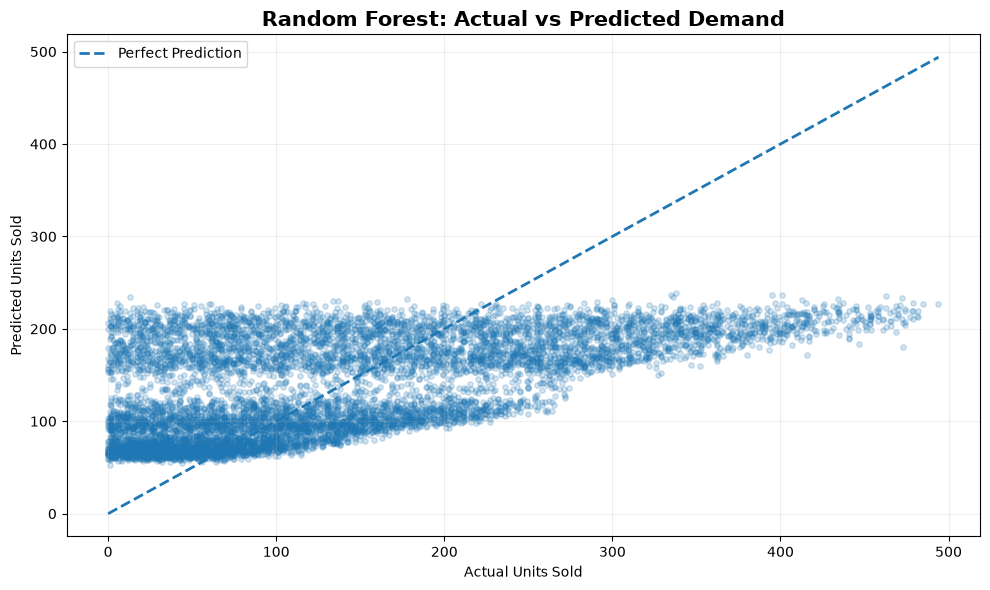

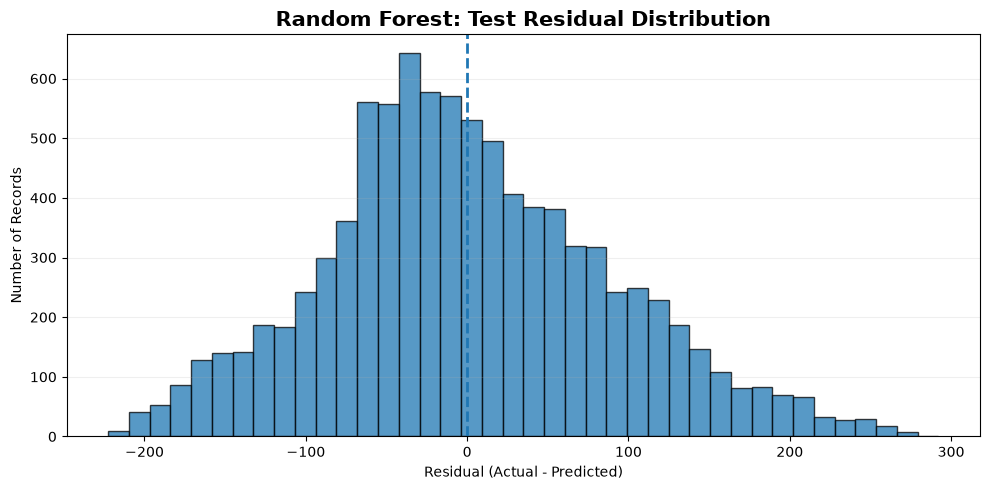


RESIDUAL DIAGNOSTICS
---------------------------------------------------------------------------
Mean residual   : +0.360
Median residual : -7.813
Residual std    : 89.019

MODEL COMPARISON SO FAR
---------------------------------------------------------------------------


,Model,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_R2,Test_R2
0,Linear Regression,68.831,68.946,87.930,87.923,0.3496,0.3390
1,Random Forest,57.757,70.645,73.399,89.020,0.5468,0.3224



MODEL NOTE
---------------------------------------------------------------------------
Random Forest captures non-linear relationships and feature interactions that Linear Regression cannot.
Training and testing performance should be evaluated together to identify possible overfitting.
The final model will not be selected until the challenger model is also evaluated.


In [28]:
# ============================================================
# CELL 26: RANDOM FOREST REGRESSOR
# ============================================================

print("=" * 75)
print("RANDOM FOREST REGRESSOR - DEMAND FORECASTING")
print("=" * 75)


# ------------------------------------------------------------
# 1. Import Random Forest
# ------------------------------------------------------------
from sklearn.ensemble import RandomForestRegressor


# ------------------------------------------------------------
# 2. Configure Model
# ------------------------------------------------------------
random_forest_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=18,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)


print("\nMODEL CONFIGURATION")
print("-" * 75)

print("Estimators        : 200")
print("Maximum depth     : 18")
print("Minimum split     : 5")
print("Minimum leaf size : 2")
print("Maximum features  : sqrt")
print("Parallel CPU use  : Enabled")


# ------------------------------------------------------------
# 3. Train Random Forest
# ------------------------------------------------------------
random_forest_model.fit(
    X_train_processed,
    y_train
)


print("\nMODEL TRAINING")
print("-" * 75)

print(
    f"Training records : {len(y_train):,}"
)

print(
    f"Model features   : {X_train_processed.shape[1]}"
)

print(
    "Random Forest training completed successfully."
)


# ------------------------------------------------------------
# 4. Generate Predictions
# ------------------------------------------------------------
rf_train_pred = random_forest_model.predict(
    X_train_processed
)

rf_test_pred = random_forest_model.predict(
    X_test_processed
)


# ------------------------------------------------------------
# 5. Calculate Evaluation Metrics
# ------------------------------------------------------------
rf_train_mae = mean_absolute_error(
    y_train,
    rf_train_pred
)

rf_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        rf_train_pred
    )
)

rf_train_r2 = r2_score(
    y_train,
    rf_train_pred
)


rf_test_mae = mean_absolute_error(
    y_test,
    rf_test_pred
)

rf_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_test_pred
    )
)

rf_test_r2 = r2_score(
    y_test,
    rf_test_pred
)


# ------------------------------------------------------------
# 6. Random Forest Performance Table
# ------------------------------------------------------------
rf_performance = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],
    "MAE": [
        rf_train_mae,
        rf_test_mae
    ],
    "RMSE": [
        rf_train_rmse,
        rf_test_rmse
    ],
    "R2": [
        rf_train_r2,
        rf_test_r2
    ]
})


print("\nRANDOM FOREST PERFORMANCE")
print("-" * 75)

display(
    rf_performance.style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "R2": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 7. Generalization Check
# ------------------------------------------------------------
print("\nGENERALIZATION CHECK")
print("-" * 75)

print(
    f"Train MAE : {rf_train_mae:.3f}"
)

print(
    f"Test MAE  : {rf_test_mae:.3f}"
)

print(
    f"MAE gap   : "
    f"{rf_test_mae - rf_train_mae:+.3f}"
)

print()

print(
    f"Train RMSE: {rf_train_rmse:.3f}"
)

print(
    f"Test RMSE : {rf_test_rmse:.3f}"
)

print(
    f"RMSE gap  : "
    f"{rf_test_rmse - rf_train_rmse:+.3f}"
)

print()

print(
    f"Train R²  : {rf_train_r2:.4f}"
)

print(
    f"Test R²   : {rf_test_r2:.4f}"
)


# ------------------------------------------------------------
# 8. Compare Against Linear Regression
# ------------------------------------------------------------
mae_improvement = (
    (linear_test_mae - rf_test_mae)
    / linear_test_mae
    * 100
)

rmse_improvement = (
    (linear_test_rmse - rf_test_rmse)
    / linear_test_rmse
    * 100
)


print("\nIMPROVEMENT OVER LINEAR REGRESSION")
print("-" * 75)

print(
    f"Linear Regression Test MAE : "
    f"{linear_test_mae:.3f}"
)

print(
    f"Random Forest Test MAE     : "
    f"{rf_test_mae:.3f}"
)

print(
    f"MAE improvement            : "
    f"{mae_improvement:+.2f}%"
)

print()

print(
    f"Linear Regression Test RMSE: "
    f"{linear_test_rmse:.3f}"
)

print(
    f"Random Forest Test RMSE    : "
    f"{rf_test_rmse:.3f}"
)

print(
    f"RMSE improvement           : "
    f"{rmse_improvement:+.2f}%"
)

print()

print(
    f"Linear Regression Test R²  : "
    f"{linear_test_r2:.4f}"
)

print(
    f"Random Forest Test R²      : "
    f"{rf_test_r2:.4f}"
)


# ------------------------------------------------------------
# 9. Prediction Summary
# ------------------------------------------------------------
rf_prediction_summary = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rf_test_pred
})


print("\nRANDOM FOREST TEST PREDICTION SUMMARY")
print("-" * 75)

display(
    rf_prediction_summary.describe().T.style.format(
        "{:,.2f}"
    )
)


# ------------------------------------------------------------
# 10. Actual vs Predicted Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    rf_test_pred,
    alpha=0.20,
    s=15
)

plot_min = min(
    y_test.min(),
    rf_test_pred.min()
)

plot_max = max(
    y_test.max(),
    rf_test_pred.max()
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")

plt.title(
    "Random Forest: Actual vs Predicted Demand",
    fontsize=15,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. Residual Analysis
# ------------------------------------------------------------
rf_residuals = (
    y_test.to_numpy()
    - rf_test_pred
)


plt.figure(figsize=(10, 5))

plt.hist(
    rf_residuals,
    bins=40,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Number of Records")

plt.title(
    "Random Forest: Test Residual Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 12. Residual Diagnostics
# ------------------------------------------------------------
print("\nRESIDUAL DIAGNOSTICS")
print("-" * 75)

print(
    f"Mean residual   : "
    f"{rf_residuals.mean():+.3f}"
)

print(
    f"Median residual : "
    f"{np.median(rf_residuals):+.3f}"
)

print(
    f"Residual std    : "
    f"{rf_residuals.std():.3f}"
)


# ------------------------------------------------------------
# 13. Add Random Forest to Model Results
# ------------------------------------------------------------
rf_result_row = pd.DataFrame({
    "Model": [
        "Random Forest"
    ],
    "Train_MAE": [
        rf_train_mae
    ],
    "Test_MAE": [
        rf_test_mae
    ],
    "Train_RMSE": [
        rf_train_rmse
    ],
    "Test_RMSE": [
        rf_test_rmse
    ],
    "Train_R2": [
        rf_train_r2
    ],
    "Test_R2": [
        rf_test_r2
    ]
})


model_results = pd.concat(
    [
        model_results,
        rf_result_row
    ],
    ignore_index=True
)


print("\nMODEL COMPARISON SO FAR")
print("-" * 75)

display(
    model_results.style.format({
        "Train_MAE": "{:.3f}",
        "Test_MAE": "{:.3f}",
        "Train_RMSE": "{:.3f}",
        "Test_RMSE": "{:.3f}",
        "Train_R2": "{:.4f}",
        "Test_R2": "{:.4f}"
    })
)


print("\nMODEL NOTE")
print("-" * 75)

print(
    "Random Forest captures non-linear relationships "
    "and feature interactions that Linear Regression cannot."
)

print(
    "Training and testing performance should be evaluated "
    "together to identify possible overfitting."
)

print(
    "The final model will not be selected until the "
    "challenger model is also evaluated."
)

### CELL 27 — Histogram Gradient Boosting Challenger

HISTOGRAM GRADIENT BOOSTING - DEMAND FORECASTING

MODEL CONFIGURATION
---------------------------------------------------------------------------
Learning rate       : 0.05
Maximum iterations  : 300
Maximum leaf nodes  : 31
Minimum leaf size   : 20
L2 regularization   : 1.0
Early stopping      : Enabled
Validation fraction : 10%

MODEL TRAINING
---------------------------------------------------------------------------
Training records : 63,800
Model features   : 57
Iterations used  : 80
Histogram Gradient Boosting training completed successfully.

HISTOGRAM GRADIENT BOOSTING PERFORMANCE
---------------------------------------------------------------------------


,Dataset,MAE,RMSE,R2
0,Training,67.755,86.221,0.3746
1,Testing,68.966,88.021,0.3376



GENERALIZATION CHECK
---------------------------------------------------------------------------
Train MAE : 67.755
Test MAE  : 68.966
MAE gap   : +1.211

Train RMSE: 86.221
Test RMSE : 88.021
RMSE gap  : +1.800

Train R²  : 0.3746
Test R²   : 0.3376

HGB TEST PREDICTION SUMMARY
---------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
Actual,"9,200.00",137.00,108.15,0.00,50.00,108.00,204.25,494.00
Predicted,"9,200.00",136.47,63.45,33.34,81.91,134.35,191.67,297.82


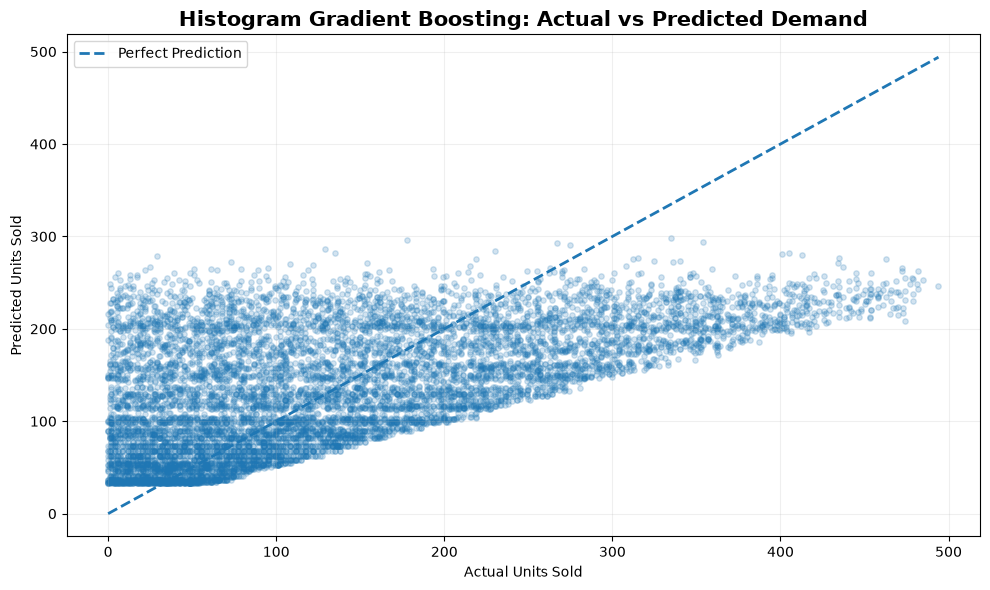

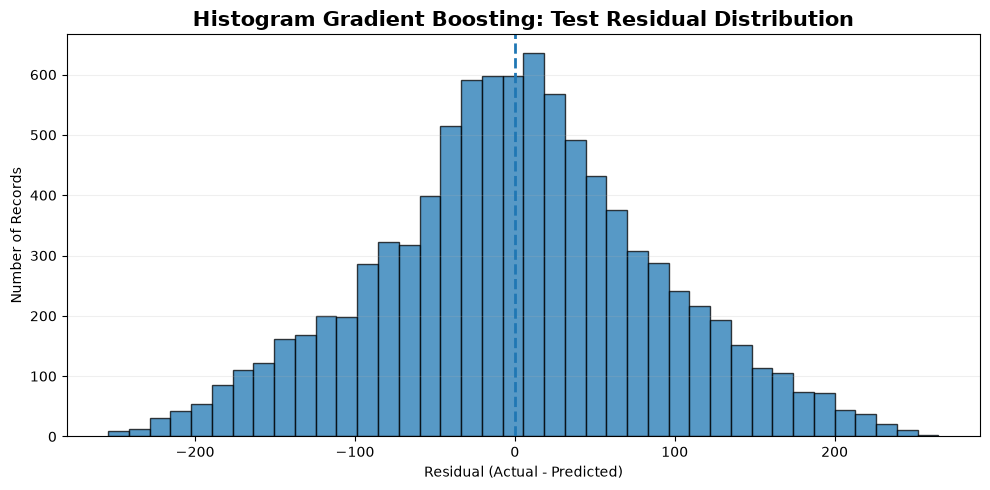


RESIDUAL DIAGNOSTICS
---------------------------------------------------------------------------
Mean residual   : +0.535
Median residual : +0.396
Residual std    : 88.020

THREE-MODEL PERFORMANCE COMPARISON
---------------------------------------------------------------------------


,Model,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_R2,Test_R2,MAE_Gap,RMSE_Gap
0,Linear Regression,68.831,68.946,87.930,87.923,0.3496,0.3390,+0.115,-0.008
1,Random Forest,57.757,70.645,73.399,89.020,0.5468,0.3224,+12.888,+15.621
2,Histogram Gradient Boosting,67.755,68.966,86.221,88.021,0.3746,0.3376,+1.211,+1.800


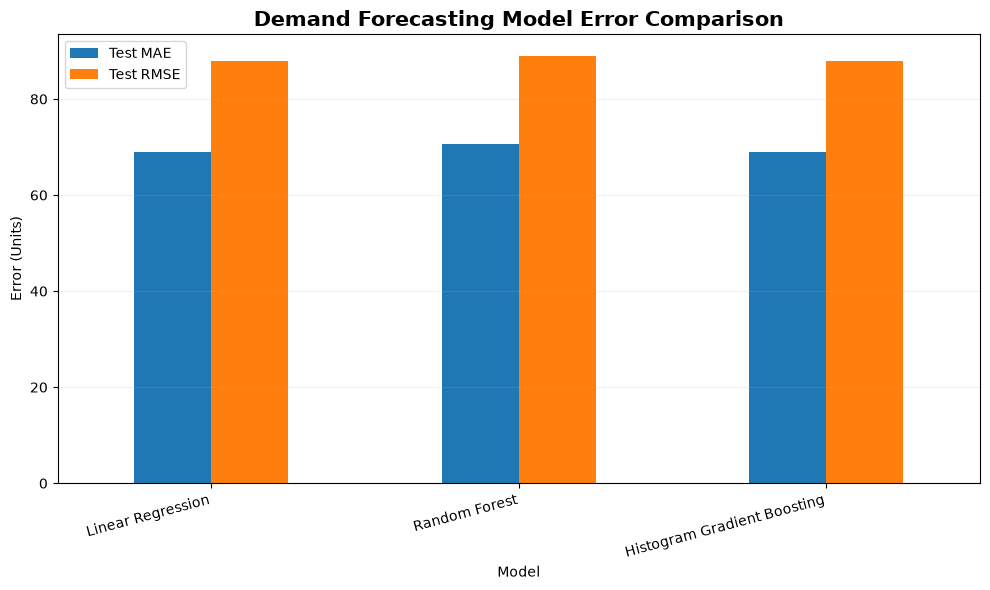


TEST-PERFORMANCE SUMMARY
---------------------------------------------------------------------------
Lowest Test MAE  : Linear Regression (68.946)
Lowest Test RMSE : Linear Regression (87.923)
Highest Test R²  : Linear Regression (0.3390)

IMPORTANT MODELING NOTE
---------------------------------------------------------------------------
Model comparison is based on the same unseen October-December 2023 test period.
No final production model is selected in this cell; performance and generalization will be reviewed next.
The supplied Demand Forecast remains excluded from all training features.


In [29]:
# ============================================================
# CELL 27: HISTOGRAM GRADIENT BOOSTING REGRESSOR
# ============================================================

print("=" * 75)
print("HISTOGRAM GRADIENT BOOSTING - DEMAND FORECASTING")
print("=" * 75)


# ------------------------------------------------------------
# 1. Import Model
# ------------------------------------------------------------
from sklearn.ensemble import HistGradientBoostingRegressor


# ------------------------------------------------------------
# 2. Configure Challenger Model
# ------------------------------------------------------------
hgb_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    max_depth=None,
    min_samples_leaf=20,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)


print("\nMODEL CONFIGURATION")
print("-" * 75)

print("Learning rate       : 0.05")
print("Maximum iterations  : 300")
print("Maximum leaf nodes  : 31")
print("Minimum leaf size   : 20")
print("L2 regularization   : 1.0")
print("Early stopping      : Enabled")
print("Validation fraction : 10%")


# ------------------------------------------------------------
# 3. Train Model
# ------------------------------------------------------------
hgb_model.fit(
    X_train_processed,
    y_train
)


print("\nMODEL TRAINING")
print("-" * 75)

print(
    f"Training records : {len(y_train):,}"
)

print(
    f"Model features   : {X_train_processed.shape[1]}"
)

print(
    f"Iterations used  : {hgb_model.n_iter_}"
)

print(
    "Histogram Gradient Boosting training completed successfully."
)


# ------------------------------------------------------------
# 4. Generate Predictions
# ------------------------------------------------------------
hgb_train_pred = hgb_model.predict(
    X_train_processed
)

hgb_test_pred = hgb_model.predict(
    X_test_processed
)


# ------------------------------------------------------------
# 5. Calculate Evaluation Metrics
# ------------------------------------------------------------
hgb_train_mae = mean_absolute_error(
    y_train,
    hgb_train_pred
)

hgb_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        hgb_train_pred
    )
)

hgb_train_r2 = r2_score(
    y_train,
    hgb_train_pred
)


hgb_test_mae = mean_absolute_error(
    y_test,
    hgb_test_pred
)

hgb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        hgb_test_pred
    )
)

hgb_test_r2 = r2_score(
    y_test,
    hgb_test_pred
)


# ------------------------------------------------------------
# 6. Performance Table
# ------------------------------------------------------------
hgb_performance = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],
    "MAE": [
        hgb_train_mae,
        hgb_test_mae
    ],
    "RMSE": [
        hgb_train_rmse,
        hgb_test_rmse
    ],
    "R2": [
        hgb_train_r2,
        hgb_test_r2
    ]
})


print("\nHISTOGRAM GRADIENT BOOSTING PERFORMANCE")
print("-" * 75)

display(
    hgb_performance.style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "R2": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 7. Generalization Check
# ------------------------------------------------------------
print("\nGENERALIZATION CHECK")
print("-" * 75)

print(
    f"Train MAE : {hgb_train_mae:.3f}"
)

print(
    f"Test MAE  : {hgb_test_mae:.3f}"
)

print(
    f"MAE gap   : "
    f"{hgb_test_mae - hgb_train_mae:+.3f}"
)

print()

print(
    f"Train RMSE: {hgb_train_rmse:.3f}"
)

print(
    f"Test RMSE : {hgb_test_rmse:.3f}"
)

print(
    f"RMSE gap  : "
    f"{hgb_test_rmse - hgb_train_rmse:+.3f}"
)

print()

print(
    f"Train R²  : {hgb_train_r2:.4f}"
)

print(
    f"Test R²   : {hgb_test_r2:.4f}"
)


# ------------------------------------------------------------
# 8. Prediction Summary
# ------------------------------------------------------------
hgb_prediction_summary = pd.DataFrame({
    "Actual": y_test,
    "Predicted": hgb_test_pred
})


print("\nHGB TEST PREDICTION SUMMARY")
print("-" * 75)

display(
    hgb_prediction_summary.describe().T.style.format(
        "{:,.2f}"
    )
)


# ------------------------------------------------------------
# 9. Actual vs Predicted Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    hgb_test_pred,
    alpha=0.20,
    s=15
)

plot_min = min(
    y_test.min(),
    hgb_test_pred.min()
)

plot_max = max(
    y_test.max(),
    hgb_test_pred.max()
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")

plt.title(
    "Histogram Gradient Boosting: Actual vs Predicted Demand",
    fontsize=15,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Residual Analysis
# ------------------------------------------------------------
hgb_residuals = (
    y_test.to_numpy()
    - hgb_test_pred
)


plt.figure(figsize=(10, 5))

plt.hist(
    hgb_residuals,
    bins=40,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Number of Records")

plt.title(
    "Histogram Gradient Boosting: Test Residual Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. Residual Diagnostics
# ------------------------------------------------------------
print("\nRESIDUAL DIAGNOSTICS")
print("-" * 75)

print(
    f"Mean residual   : "
    f"{hgb_residuals.mean():+.3f}"
)

print(
    f"Median residual : "
    f"{np.median(hgb_residuals):+.3f}"
)

print(
    f"Residual std    : "
    f"{hgb_residuals.std():.3f}"
)


# ------------------------------------------------------------
# 12. Add HGB Result to Model Comparison
# ------------------------------------------------------------
hgb_result_row = pd.DataFrame({
    "Model": [
        "Histogram Gradient Boosting"
    ],
    "Train_MAE": [
        hgb_train_mae
    ],
    "Test_MAE": [
        hgb_test_mae
    ],
    "Train_RMSE": [
        hgb_train_rmse
    ],
    "Test_RMSE": [
        hgb_test_rmse
    ],
    "Train_R2": [
        hgb_train_r2
    ],
    "Test_R2": [
        hgb_test_r2
    ]
})


model_results = pd.concat(
    [
        model_results,
        hgb_result_row
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# 13. Calculate Generalization Gaps
# ------------------------------------------------------------
model_results["MAE_Gap"] = (
    model_results["Test_MAE"]
    - model_results["Train_MAE"]
)

model_results["RMSE_Gap"] = (
    model_results["Test_RMSE"]
    - model_results["Train_RMSE"]
)


# ------------------------------------------------------------
# 14. Final Three-Model Comparison
# ------------------------------------------------------------
print("\nTHREE-MODEL PERFORMANCE COMPARISON")
print("-" * 75)

display(
    model_results[
        [
            "Model",
            "Train_MAE",
            "Test_MAE",
            "Train_RMSE",
            "Test_RMSE",
            "Train_R2",
            "Test_R2",
            "MAE_Gap",
            "RMSE_Gap"
        ]
    ].style.format({
        "Train_MAE": "{:.3f}",
        "Test_MAE": "{:.3f}",
        "Train_RMSE": "{:.3f}",
        "Test_RMSE": "{:.3f}",
        "Train_R2": "{:.4f}",
        "Test_R2": "{:.4f}",
        "MAE_Gap": "{:+.3f}",
        "RMSE_Gap": "{:+.3f}"
    })
)


# ------------------------------------------------------------
# 15. Test Metric Comparison Chart
# ------------------------------------------------------------
comparison_plot = (
    model_results[
        [
            "Model",
            "Test_MAE",
            "Test_RMSE"
        ]
    ]
    .set_index("Model")
)


comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Demand Forecasting Model Error Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Error (Units)")
plt.xlabel("Model")

plt.xticks(
    rotation=15,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.legend(
    ["Test MAE", "Test RMSE"]
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 16. Metric-Based Best Results
# ------------------------------------------------------------
lowest_mae_model = model_results.loc[
    model_results["Test_MAE"].idxmin()
]

lowest_rmse_model = model_results.loc[
    model_results["Test_RMSE"].idxmin()
]

highest_r2_model = model_results.loc[
    model_results["Test_R2"].idxmax()
]


print("\nTEST-PERFORMANCE SUMMARY")
print("-" * 75)

print(
    "Lowest Test MAE  : "
    f"{lowest_mae_model['Model']} "
    f"({lowest_mae_model['Test_MAE']:.3f})"
)

print(
    "Lowest Test RMSE : "
    f"{lowest_rmse_model['Model']} "
    f"({lowest_rmse_model['Test_RMSE']:.3f})"
)

print(
    "Highest Test R²  : "
    f"{highest_r2_model['Model']} "
    f"({highest_r2_model['Test_R2']:.4f})"
)


print("\nIMPORTANT MODELING NOTE")
print("-" * 75)

print(
    "Model comparison is based on the same unseen "
    "October-December 2023 test period."
)

print(
    "No final production model is selected in this cell; "
    "performance and generalization will be reviewed next."
)

print(
    "The supplied Demand Forecast remains excluded "
    "from all training features."
)

### CELL 28: FINAL MODEL EVALUATION & SELECTION

FINAL MACHINE LEARNING MODEL EVALUATION & SELECTION

FINAL ML MODEL COMPARISON
---------------------------------------------------------------------------


,Model,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_R2,Test_R2,MAE_Gap,RMSE_Gap
0,Linear Regression,68.831,68.946,87.930,87.923,0.3496,0.3390,+0.115,-0.008
1,Histogram Gradient Boosting,67.755,68.966,86.221,88.021,0.3746,0.3376,+1.211,+1.800
2,Random Forest,57.757,70.645,73.399,89.020,0.5468,0.3224,+12.888,+15.621



FINAL MODEL SELECTION
---------------------------------------------------------------------------
Selected model : Linear Regression
Test MAE       : 68.946 units
Test RMSE      : 87.923 units
Test R²        : 0.3390
Train-Test MAE gap : +0.115 units

PERFORMANCE RELATIVE TO LINEAR REGRESSION
---------------------------------------------------------------------------


,Model,Test_MAE,Test_RMSE,Test_R2,MAE_vs_Linear_%,RMSE_vs_Linear_%
0,Linear Regression,68.946,87.923,0.3390,+0.00%,+0.00%
1,Histogram Gradient Boosting,68.966,88.021,0.3376,-0.03%,-0.11%
2,Random Forest,70.645,89.020,0.3224,-2.46%,-1.25%



FINAL MODEL TEST PREDICTION SAMPLE
---------------------------------------------------------------------------


,Date,Actual_Units_Sold,ML_Predicted_Units_Sold,ML_Absolute_Error,ML_Residual
0,2023-10-01 00:00:00,51,75.93,24.93,-24.93
1,2023-10-01 00:00:00,58,97.93,39.93,-39.93
2,2023-10-01 00:00:00,35,38.30,3.30,-3.30
3,2023-10-01 00:00:00,48,62.57,14.57,-14.57
4,2023-10-01 00:00:00,66,33.90,32.10,+32.10
5,2023-10-01 00:00:00,61,189.13,128.13,-128.13
6,2023-10-01 00:00:00,27,245.44,218.44,-218.44
7,2023-10-01 00:00:00,377,189.79,187.21,+187.21
8,2023-10-01 00:00:00,58,51.26,6.74,+6.74
9,2023-10-01 00:00:00,183,94.10,88.90,+88.90



FINAL MODEL ABSOLUTE ERROR DISTRIBUTION
---------------------------------------------------------------------------


,Error_Percentile,Absolute_Error_Units
0,50th,55.12
1,75th,102.77
2,90th,151.57
3,95th,178.38



ML MODEL VS SUPPLIED FORECAST BENCHMARK
---------------------------------------------------------------------------


,Forecast_Source,MAE,RMSE,R2
0,Our ML Model (Linear Regression),68.946,87.923,0.3390
1,Supplied Demand Forecast,8.347,10.035,0.9914


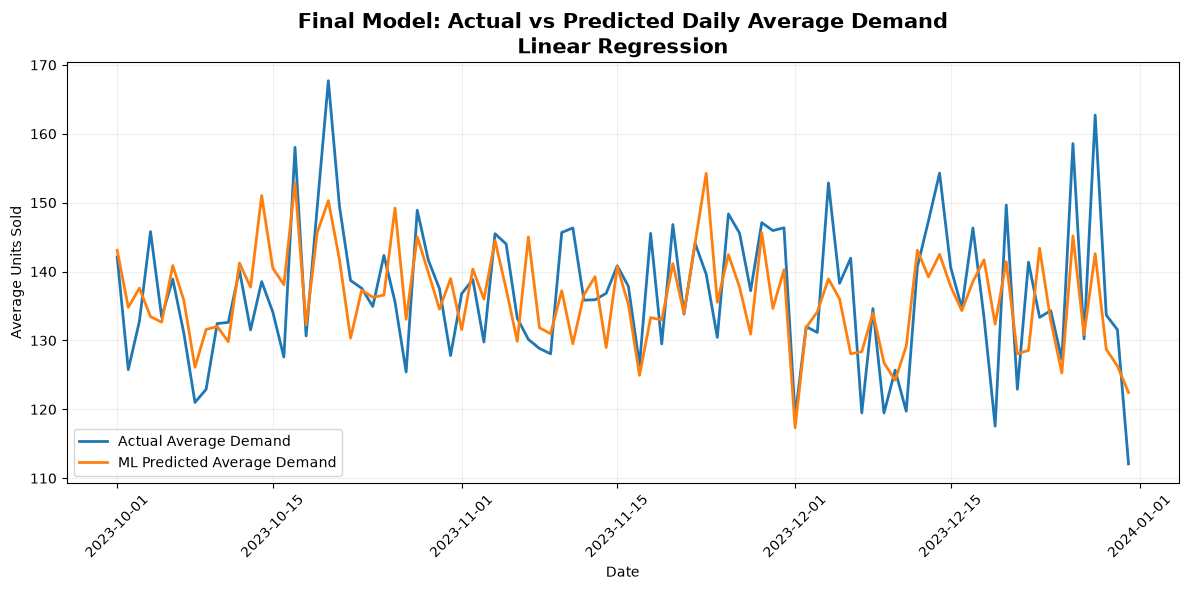


FINAL MODEL INTERPRETATION
---------------------------------------------------------------------------
Linear Regression achieved the lowest MAE on the unseen chronological test period.
The final model was selected primarily using Test MAE, with RMSE, R², and the train-test generalization gap used as supporting diagnostics.
The Random Forest model showed a substantially larger train-test performance gap, indicating greater overfitting.
Histogram Gradient Boosting generalized reasonably well, but did not improve the held-out test metrics over the selected model.

EXTERNAL BENCHMARK CAUTION
---------------------------------------------------------------------------
The supplied Demand Forecast is NOT an input feature and was NOT used to train the ML models.
It is shown only as an external benchmark because its generation methodology and information availability are not documented in this dataset.
Therefore, its much stronger accuracy should not be interpreted as a leakage-free like-for-

In [30]:
# ============================================================
# CELL 28: FINAL MODEL EVALUATION & SELECTION
# ============================================================

print("=" * 75)
print("FINAL MACHINE LEARNING MODEL EVALUATION & SELECTION")
print("=" * 75)


# ------------------------------------------------------------
# 1. Create Clean Final Model Comparison
# ------------------------------------------------------------
final_model_comparison = model_results[
    [
        "Model",
        "Train_MAE",
        "Test_MAE",
        "Train_RMSE",
        "Test_RMSE",
        "Train_R2",
        "Test_R2",
        "MAE_Gap",
        "RMSE_Gap"
    ]
].copy()


final_model_comparison = (
    final_model_comparison
    .sort_values(
        "Test_MAE",
        ascending=True
    )
    .reset_index(drop=True)
)


print("\nFINAL ML MODEL COMPARISON")
print("-" * 75)

display(
    final_model_comparison.style.format({
        "Train_MAE": "{:.3f}",
        "Test_MAE": "{:.3f}",
        "Train_RMSE": "{:.3f}",
        "Test_RMSE": "{:.3f}",
        "Train_R2": "{:.4f}",
        "Test_R2": "{:.4f}",
        "MAE_Gap": "{:+.3f}",
        "RMSE_Gap": "{:+.3f}"
    })
)


# ------------------------------------------------------------
# 2. Select Final Model Using Test MAE
# ------------------------------------------------------------
# MAE is used as the primary selection metric because it has
# a direct business interpretation in units of product demand.

best_model_row = final_model_comparison.iloc[0]

final_model_name = best_model_row["Model"]


if final_model_name == "Linear Regression":

    final_model = linear_model
    final_train_pred = linear_train_pred
    final_test_pred = linear_test_pred

elif final_model_name == "Random Forest":

    final_model = random_forest_model
    final_train_pred = rf_train_pred
    final_test_pred = rf_test_pred

elif final_model_name == "Histogram Gradient Boosting":

    final_model = hgb_model
    final_train_pred = hgb_train_pred
    final_test_pred = hgb_test_pred

else:

    raise ValueError(
        f"Unknown selected model: {final_model_name}"
    )


print("\nFINAL MODEL SELECTION")
print("-" * 75)

print(
    f"Selected model : {final_model_name}"
)

print(
    f"Test MAE       : {best_model_row['Test_MAE']:.3f} units"
)

print(
    f"Test RMSE      : {best_model_row['Test_RMSE']:.3f} units"
)

print(
    f"Test R²        : {best_model_row['Test_R2']:.4f}"
)

print(
    f"Train-Test MAE gap : "
    f"{best_model_row['MAE_Gap']:+.3f} units"
)


# ------------------------------------------------------------
# 3. Quantify Differences Between Models
# ------------------------------------------------------------
baseline_mae = final_model_comparison.loc[
    final_model_comparison["Model"]
    == "Linear Regression",
    "Test_MAE"
].iloc[0]


baseline_rmse = final_model_comparison.loc[
    final_model_comparison["Model"]
    == "Linear Regression",
    "Test_RMSE"
].iloc[0]


model_difference_table = final_model_comparison[
    [
        "Model",
        "Test_MAE",
        "Test_RMSE",
        "Test_R2"
    ]
].copy()


model_difference_table["MAE_vs_Linear_%"] = (
    (
        baseline_mae
        - model_difference_table["Test_MAE"]
    )
    / baseline_mae
    * 100
)


model_difference_table["RMSE_vs_Linear_%"] = (
    (
        baseline_rmse
        - model_difference_table["Test_RMSE"]
    )
    / baseline_rmse
    * 100
)


print("\nPERFORMANCE RELATIVE TO LINEAR REGRESSION")
print("-" * 75)

display(
    model_difference_table.style.format({
        "Test_MAE": "{:.3f}",
        "Test_RMSE": "{:.3f}",
        "Test_R2": "{:.4f}",
        "MAE_vs_Linear_%": "{:+.2f}%",
        "RMSE_vs_Linear_%": "{:+.2f}%"
    })
)


# ------------------------------------------------------------
# 4. Build Final Test Prediction DataFrame
# ------------------------------------------------------------
final_predictions = pd.DataFrame({
    "Date": test_dates.values,
    "Actual_Units_Sold": y_test.values,
    "ML_Predicted_Units_Sold": final_test_pred
})


# Predictions below zero would not be operationally meaningful.
final_predictions[
    "ML_Predicted_Units_Sold"
] = final_predictions[
    "ML_Predicted_Units_Sold"
].clip(lower=0)


final_predictions[
    "ML_Absolute_Error"
] = np.abs(
    final_predictions["Actual_Units_Sold"]
    - final_predictions["ML_Predicted_Units_Sold"]
)


final_predictions[
    "ML_Residual"
] = (
    final_predictions["Actual_Units_Sold"]
    - final_predictions["ML_Predicted_Units_Sold"]
)


print("\nFINAL MODEL TEST PREDICTION SAMPLE")
print("-" * 75)

display(
    final_predictions.head(10).style.format({
        "Actual_Units_Sold": "{:,.0f}",
        "ML_Predicted_Units_Sold": "{:,.2f}",
        "ML_Absolute_Error": "{:,.2f}",
        "ML_Residual": "{:+,.2f}"
    })
)


# ------------------------------------------------------------
# 5. Error Distribution Statistics
# ------------------------------------------------------------
error_percentiles = pd.DataFrame({
    "Error_Percentile": [
        "50th",
        "75th",
        "90th",
        "95th"
    ],
    "Absolute_Error_Units": [
        final_predictions[
            "ML_Absolute_Error"
        ].quantile(0.50),

        final_predictions[
            "ML_Absolute_Error"
        ].quantile(0.75),

        final_predictions[
            "ML_Absolute_Error"
        ].quantile(0.90),

        final_predictions[
            "ML_Absolute_Error"
        ].quantile(0.95)
    ]
})


print("\nFINAL MODEL ABSOLUTE ERROR DISTRIBUTION")
print("-" * 75)

display(
    error_percentiles.style.format({
        "Absolute_Error_Units": "{:.2f}"
    })
)


# ------------------------------------------------------------
# 6. Compare with Supplied Demand Forecast
#    External benchmark only
# ------------------------------------------------------------
benchmark_test = ml_df.loc[
    test_mask,
    [
        "Date",
        "Units Sold",
        "Demand Forecast"
    ]
].copy()


benchmark_test[
    "Demand Forecast"
] = pd.to_numeric(
    benchmark_test["Demand Forecast"],
    errors="coerce"
)


benchmark_test[
    "Clipped_Demand_Forecast"
] = benchmark_test[
    "Demand Forecast"
].clip(lower=0)


benchmark_mae = mean_absolute_error(
    benchmark_test["Units Sold"],
    benchmark_test["Clipped_Demand_Forecast"]
)


benchmark_rmse = np.sqrt(
    mean_squared_error(
        benchmark_test["Units Sold"],
        benchmark_test["Clipped_Demand_Forecast"]
    )
)


benchmark_r2 = r2_score(
    benchmark_test["Units Sold"],
    benchmark_test["Clipped_Demand_Forecast"]
)


ml_vs_external_benchmark = pd.DataFrame({
    "Forecast_Source": [
        f"Our ML Model ({final_model_name})",
        "Supplied Demand Forecast"
    ],

    "MAE": [
        best_model_row["Test_MAE"],
        benchmark_mae
    ],

    "RMSE": [
        best_model_row["Test_RMSE"],
        benchmark_rmse
    ],

    "R2": [
        best_model_row["Test_R2"],
        benchmark_r2
    ]
})


print("\nML MODEL VS SUPPLIED FORECAST BENCHMARK")
print("-" * 75)

display(
    ml_vs_external_benchmark.style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "R2": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 7. Visual Comparison of Actual and Predictions
# ------------------------------------------------------------
plot_sample = final_predictions.sort_values(
    "Date"
).copy()


# Daily average makes the chronological comparison readable.
daily_prediction_plot = (
    plot_sample
    .groupby("Date", as_index=False)
    .agg(
        Actual_Demand=(
            "Actual_Units_Sold",
            "mean"
        ),
        ML_Predicted_Demand=(
            "ML_Predicted_Units_Sold",
            "mean"
        )
    )
)


plt.figure(figsize=(12, 6))

plt.plot(
    daily_prediction_plot["Date"],
    daily_prediction_plot["Actual_Demand"],
    label="Actual Average Demand",
    linewidth=2
)

plt.plot(
    daily_prediction_plot["Date"],
    daily_prediction_plot["ML_Predicted_Demand"],
    label="ML Predicted Average Demand",
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("Average Units Sold")

plt.title(
    f"Final Model: Actual vs Predicted Daily Average Demand\n"
    f"{final_model_name}",
    fontsize=15,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.2)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Final Model Selection Explanation
# ------------------------------------------------------------
print("\nFINAL MODEL INTERPRETATION")
print("-" * 75)

print(
    f"{final_model_name} achieved the lowest MAE on the "
    "unseen chronological test period."
)

print(
    "The final model was selected primarily using Test MAE, "
    "with RMSE, R², and the train-test generalization gap "
    "used as supporting diagnostics."
)

print(
    "The Random Forest model showed a substantially larger "
    "train-test performance gap, indicating greater overfitting."
)

print(
    "Histogram Gradient Boosting generalized reasonably well, "
    "but did not improve the held-out test metrics over the "
    "selected model."
)


print("\nEXTERNAL BENCHMARK CAUTION")
print("-" * 75)

print(
    "The supplied Demand Forecast is NOT an input feature "
    "and was NOT used to train the ML models."
)

print(
    "It is shown only as an external benchmark because its "
    "generation methodology and information availability "
    "are not documented in this dataset."
)

print(
    "Therefore, its much stronger accuracy should not be "
    "interpreted as a leakage-free like-for-like model comparison."
)

### Cell 29 — Final Model Interpretation & Feature Influence

FINAL MODEL INTERPRETATION & FEATURE INFLUENCE

SELECTED MODEL
---------------------------------------------------------------------------
Final model : Linear Regression

TOP 20 MODEL COEFFICIENTS BY ABSOLUTE MAGNITUDE
---------------------------------------------------------------------------


,Feature_Clean,Coefficient,Absolute_Coefficient,Direction
0,Competitor_Price_Ratio,-4.1695,4.1695,Negative
1,Product ID_P0017,-2.6566,2.6566,Negative
2,Product ID_P0008,-2.4360,2.4360,Negative
3,Product ID_P0005,+2.0629,2.0629,Positive
4,Is_Weekend,-1.8652,1.8652,Negative
5,Product ID_P0015,+1.7477,1.7477,Positive
6,Quarter,+1.7451,1.7451,Positive
7,Product ID_P0003,-1.5010,1.5010,Negative
8,Product ID_P0010,-1.1569,1.1569,Negative
9,Weather Condition_Rainy,-1.1397,1.1397,Negative



TOP 15 POSITIVE COEFFICIENTS
---------------------------------------------------------------------------


,Feature_Clean,Coefficient
0,Product ID_P0005,+2.0629
1,Product ID_P0015,+1.7477
2,Quarter,+1.7451
3,Product ID_P0020,+1.0380
4,Weather Condition_Sunny,+1.0089
5,Product ID_P0014,+0.8532
6,Product ID_P0016,+0.8048
7,Product ID_P0004,+0.6945
8,Product ID_P0007,+0.6689
9,Product ID_P0001,+0.6413



TOP 15 NEGATIVE COEFFICIENTS
---------------------------------------------------------------------------


,Feature_Clean,Coefficient
0,Competitor_Price_Ratio,-4.1695
1,Product ID_P0017,-2.6566
2,Product ID_P0008,-2.4360
3,Is_Weekend,-1.8652
4,Product ID_P0003,-1.5010
5,Product ID_P0010,-1.1569
6,Weather Condition_Rainy,-1.1397
7,Month,-1.0486
8,Product ID_P0018,-0.8828
9,Store ID_S001,-0.7780


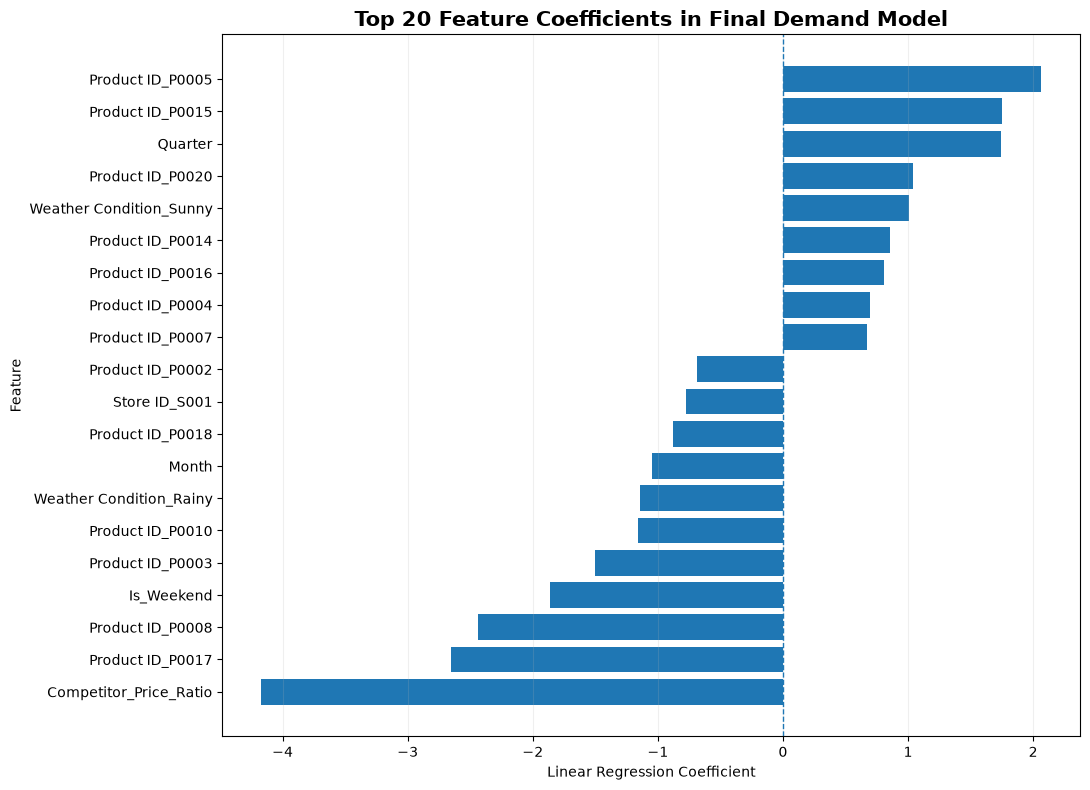


CORE BUSINESS VARIABLE COEFFICIENTS
---------------------------------------------------------------------------


,Feature_Clean,Coefficient,Direction
14,Competitor_Price_Ratio,-4.1695,Negative
0,Inventory Level,+0.4961,Positive
4,Holiday/Promotion,-0.3663,Negative
12,Effective_Price,-0.1881,Negative
1,Price,+0.1164,Positive
2,Discount,-0.1162,Negative
13,Competitor_Price_Gap,+0.0884,Positive
3,Competitor Pricing,+0.0281,Positive



MODEL INTERCEPT
---------------------------------------------------------------------------
Linear Regression intercept : +961.9872

INTERPRETATION GUIDANCE
---------------------------------------------------------------------------
Coefficient signs describe associations learned by the Linear Regression model after accounting for the other included features.
They should NOT be interpreted as causal effects.
Coefficient magnitudes are not directly comparable across all numeric variables because the numeric features were not standardized and therefore use different scales.
Categorical variables were one-hot encoded without dropping a reference category, so their individual coefficients should be interpreted cautiously rather than as simple effects relative to one omitted category.
Correlated engineered variables such as Price, Effective Price, Competitor Price Gap, and Competitor Price Ratio can distribute influence across coefficients.
These coefficients are therefore used for model i

In [31]:
# ============================================================
# CELL 29: FINAL MODEL INTERPRETATION & FEATURE INFLUENCE
# ============================================================

print("=" * 75)
print("FINAL MODEL INTERPRETATION & FEATURE INFLUENCE")
print("=" * 75)


# ------------------------------------------------------------
# 1. Validate Selected Model
# ------------------------------------------------------------
print("\nSELECTED MODEL")
print("-" * 75)

print(f"Final model : {final_model_name}")

if final_model_name != "Linear Regression":
    raise ValueError(
        "This interpretation cell is designed for the currently "
        "selected Linear Regression model."
    )


# ------------------------------------------------------------
# 2. Recover Linear Regression Coefficients
# ------------------------------------------------------------
coefficients = final_model.coef_

if len(coefficients) != len(processed_feature_names):
    raise ValueError(
        "Coefficient count does not match processed feature count."
    )


feature_influence = pd.DataFrame({
    "Feature": processed_feature_names,
    "Coefficient": coefficients
})


feature_influence["Absolute_Coefficient"] = (
    feature_influence["Coefficient"].abs()
)


feature_influence["Direction"] = np.where(
    feature_influence["Coefficient"] > 0,
    "Positive",
    np.where(
        feature_influence["Coefficient"] < 0,
        "Negative",
        "Neutral"
    )
)


# ------------------------------------------------------------
# 3. Clean Feature Names for Presentation
# ------------------------------------------------------------
feature_influence["Feature_Clean"] = (
    feature_influence["Feature"]
    .str.replace(
        "numeric__",
        "",
        regex=False
    )
    .str.replace(
        "categorical__",
        "",
        regex=False
    )
)


# ------------------------------------------------------------
# 4. Display Most Influential Coefficients
# ------------------------------------------------------------
top_influential_features = (
    feature_influence
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
    .head(20)
    .reset_index(drop=True)
)


print("\nTOP 20 MODEL COEFFICIENTS BY ABSOLUTE MAGNITUDE")
print("-" * 75)

display(
    top_influential_features[
        [
            "Feature_Clean",
            "Coefficient",
            "Absolute_Coefficient",
            "Direction"
        ]
    ].style.format({
        "Coefficient": "{:+.4f}",
        "Absolute_Coefficient": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 5. Strongest Positive Coefficients
# ------------------------------------------------------------
positive_features = (
    feature_influence[
        feature_influence["Coefficient"] > 0
    ]
    .sort_values(
        "Coefficient",
        ascending=False
    )
    .head(15)
    .reset_index(drop=True)
)


print("\nTOP 15 POSITIVE COEFFICIENTS")
print("-" * 75)

display(
    positive_features[
        [
            "Feature_Clean",
            "Coefficient"
        ]
    ].style.format({
        "Coefficient": "{:+.4f}"
    })
)


# ------------------------------------------------------------
# 6. Strongest Negative Coefficients
# ------------------------------------------------------------
negative_features = (
    feature_influence[
        feature_influence["Coefficient"] < 0
    ]
    .sort_values(
        "Coefficient",
        ascending=True
    )
    .head(15)
    .reset_index(drop=True)
)


print("\nTOP 15 NEGATIVE COEFFICIENTS")
print("-" * 75)

display(
    negative_features[
        [
            "Feature_Clean",
            "Coefficient"
        ]
    ].style.format({
        "Coefficient": "{:+.4f}"
    })
)


# ------------------------------------------------------------
# 7. Visualize Top Coefficients
# ------------------------------------------------------------
plot_features = (
    top_influential_features
    .sort_values(
        "Coefficient",
        ascending=True
    )
)


plt.figure(figsize=(11, 8))

plt.barh(
    plot_features["Feature_Clean"],
    plot_features["Coefficient"]
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Linear Regression Coefficient")
plt.ylabel("Feature")

plt.title(
    "Top 20 Feature Coefficients in Final Demand Model",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Inspect Core Business Variables
# ------------------------------------------------------------
core_business_features = [
    "Inventory Level",
    "Price",
    "Discount",
    "Competitor Pricing",
    "Holiday/Promotion",
    "Effective_Price",
    "Competitor_Price_Gap",
    "Competitor_Price_Ratio"
]


core_business_influence = (
    feature_influence[
        feature_influence["Feature_Clean"]
        .isin(core_business_features)
    ]
    .copy()
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
)


print("\nCORE BUSINESS VARIABLE COEFFICIENTS")
print("-" * 75)

display(
    core_business_influence[
        [
            "Feature_Clean",
            "Coefficient",
            "Direction"
        ]
    ].style.format({
        "Coefficient": "{:+.4f}"
    })
)


# ------------------------------------------------------------
# 9. Model Intercept
# ------------------------------------------------------------
print("\nMODEL INTERCEPT")
print("-" * 75)

print(
    f"Linear Regression intercept : "
    f"{final_model.intercept_:+.4f}"
)


# ------------------------------------------------------------
# 10. Coefficient Interpretation Guidance
# ------------------------------------------------------------
print("\nINTERPRETATION GUIDANCE")
print("-" * 75)

print(
    "Coefficient signs describe associations learned by the "
    "Linear Regression model after accounting for the other "
    "included features."
)

print(
    "They should NOT be interpreted as causal effects."
)

print(
    "Coefficient magnitudes are not directly comparable across "
    "all numeric variables because the numeric features were "
    "not standardized and therefore use different scales."
)

print(
    "Categorical variables were one-hot encoded without dropping "
    "a reference category, so their individual coefficients "
    "should be interpreted cautiously rather than as simple "
    "effects relative to one omitted category."
)

print(
    "Correlated engineered variables such as Price, "
    "Effective Price, Competitor Price Gap, and Competitor "
    "Price Ratio can distribute influence across coefficients."
)

print(
    "These coefficients are therefore used for model "
    "interpretation and association analysis, not for causal "
    "business claims."
)


# ------------------------------------------------------------
# 11. Preserve Interpretation Results
# ------------------------------------------------------------
final_feature_influence = feature_influence.copy()


print("\nINTERPRETATION RESULTS SAVED")
print("-" * 75)

print(
    "Variable created : final_feature_influence"
)

print(
    f"Features analyzed: "
    f"{len(final_feature_influence):,}"
)

### Cell 30 — Model Error Analysis by Business Segment

FINAL MODEL ERROR ANALYSIS BY BUSINESS SEGMENT

TEST ERROR DATASET VALIDATION
---------------------------------------------------------------------------
Records analyzed : 9,200
Date range       : 2023-10-01 to 2023-12-31
Average actual demand    : 137.00
Average predicted demand : 136.21
Overall MAE              : 68.946

FORECAST DIRECTION SUMMARY
---------------------------------------------------------------------------


,Forecast_Direction,Records,Record_Share_%
0,Underforecast,"4,694",51.02%
1,Overforecast,"4,506",48.98%
2,Exact,0,0.00%



PRODUCT-LEVEL MODEL ERROR
---------------------------------------------------------------------------


,Product ID,Records,Actual_Avg_Demand,Predicted_Avg_Demand,MAE,Bias,Underforecast_Rate,RMSE,MAE_vs_Actual_%
0,P0008,460,140.74,136.54,72.13,+4.21,53.04%,91.98,51.25%
1,P0019,460,134.70,139.55,72.04,-4.84,49.78%,91.76,53.48%
2,P0014,460,139.75,140.34,71.82,-0.59,51.52%,90.00,51.39%
3,P0012,460,131.15,137.63,71.59,-6.48,47.83%,92.44,54.59%
4,P0009,460,143.17,139.73,71.55,+3.44,50.65%,90.49,49.97%
5,P0010,460,134.22,131.68,71.10,+2.54,54.13%,90.91,52.97%
6,P0003,460,133.56,134.36,70.50,-0.80,50.87%,90.57,52.78%
7,P0017,460,148.00,137.13,69.83,+10.87,56.52%,88.53,47.18%
8,P0018,460,134.58,132.11,69.62,+2.48,50.43%,88.83,51.73%
9,P0011,460,144.44,131.29,69.50,+13.15,56.74%,88.50,48.12%



STORE-LEVEL MODEL ERROR
---------------------------------------------------------------------------


...

,Category,Records,Actual_Avg_Demand,Predicted_Avg_Demand,MAE,Bias,Underforecast_Rate,RMSE,MAE_vs_Actual_%
0,Furniture,"1,884",142.91,138.50,71.80,+4.41,52.92%,90.84,50.24%
1,Toys,"1,802",136.87,136.12,69.41,+0.75,50.89%,88.54,50.71%
2,Groceries,"1,827",133.14,135.04,68.74,-1.90,50.36%,88.64,51.63%
3,Clothing,"1,775",136.59,137.87,68.35,-1.27,49.63%,87.58,50.04%
4,Electronics,"1,912",135.39,133.63,66.45,+1.76,51.20%,83.96,49.08%



REGION-LEVEL MODEL ERROR
---------------------------------------------------------------------------


,Region,Records,Actual_Avg_Demand,Predicted_Avg_Demand,MAE,Bias,Underforecast_Rate,RMSE,MAE_vs_Actual_%
0,North,"2,302",137.57,136.46,70.33,+1.10,50.39%,89.87,51.13%
1,South,"2,301",137.73,136.70,68.92,+1.03,51.80%,87.72,50.04%
2,West,"2,296",136.41,134.84,68.35,+1.57,51.44%,87.24,50.10%
3,East,"2,301",136.31,136.84,68.18,-0.53,50.46%,86.82,50.02%



DEMAND-LEVEL MODEL ERROR
---------------------------------------------------------------------------


,Demand_Level,Records,Actual_Avg_Demand,Predicted_Avg_Demand,MAE,Bias,Underforecast_Rate,RMSE
0,0-50,"2,342",25.00,97.02,73.73,-72.02,8.84%,96.71
1,51-100,"1,978",73.95,111.55,53.50,-37.60,36.91%,71.85
2,101-200,"2,515",145.71,141.45,45.20,+4.26,58.41%,53.81
3,201-300,"1,454",246.24,175.61,72.35,+70.63,94.70%,81.47
4,301+,911,363.47,213.18,150.29,+150.29,100.00%,155.66


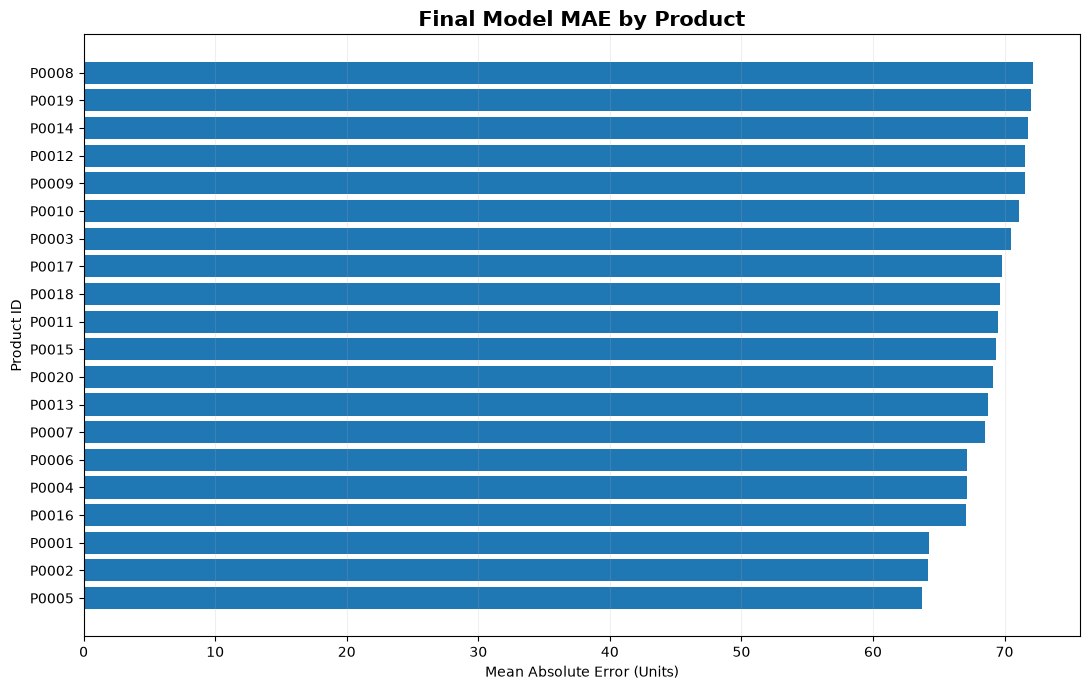

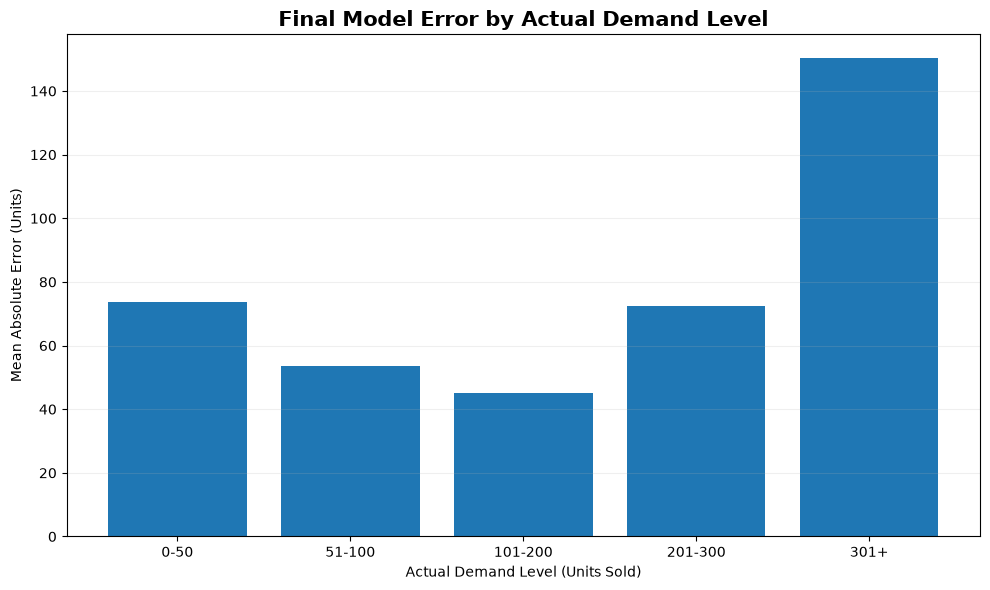


KEY ERROR INSIGHTS
---------------------------------------------------------------------------
Highest product-level MAE : P0008 (72.13 units)
Lowest product-level MAE  : P0005 (63.76 units)
Highest-error demand band : 301+ (MAE = 150.29 units)

RESULTS SAVED
---------------------------------------------------------------------------
Created variables:
- final_error_analysis
- product_error_summary
- store_error_summary
- category_error_summary
- region_error_summary
- demand_level_summary


In [32]:
# ============================================================
# CELL 30: FINAL MODEL ERROR ANALYSIS BY BUSINESS SEGMENT
# ============================================================

print("=" * 75)
print("FINAL MODEL ERROR ANALYSIS BY BUSINESS SEGMENT")
print("=" * 75)


# ------------------------------------------------------------
# 1. Build Detailed Test-Period Evaluation Dataset
# ------------------------------------------------------------
error_analysis = ml_df.loc[
    test_mask,
    [
        "Date",
        "Store ID",
        "Product ID",
        "Category",
        "Region",
        "Units Sold"
    ]
].copy()


# Align with final model predictions
error_analysis["Predicted_Units_Sold"] = (
    np.asarray(final_test_pred).copy()
)


# Demand predictions cannot be negative
error_analysis["Predicted_Units_Sold"] = (
    error_analysis["Predicted_Units_Sold"]
    .clip(lower=0)
)


# ------------------------------------------------------------
# 2. Calculate Record-Level Errors
# ------------------------------------------------------------
error_analysis["Residual"] = (
    error_analysis["Units Sold"]
    - error_analysis["Predicted_Units_Sold"]
)

error_analysis["Absolute_Error"] = (
    error_analysis["Residual"].abs()
)

error_analysis["Squared_Error"] = (
    error_analysis["Residual"] ** 2
)


error_analysis["Forecast_Direction"] = np.select(
    [
        error_analysis["Residual"] > 0,
        error_analysis["Residual"] < 0
    ],
    [
        "Underforecast",
        "Overforecast"
    ],
    default="Exact"
)


print("\nTEST ERROR DATASET VALIDATION")
print("-" * 75)

print(
    f"Records analyzed : "
    f"{len(error_analysis):,}"
)

print(
    f"Date range       : "
    f"{error_analysis['Date'].min().date()} "
    f"to {error_analysis['Date'].max().date()}"
)

print(
    f"Average actual demand    : "
    f"{error_analysis['Units Sold'].mean():.2f}"
)

print(
    f"Average predicted demand : "
    f"{error_analysis['Predicted_Units_Sold'].mean():.2f}"
)

print(
    f"Overall MAE              : "
    f"{error_analysis['Absolute_Error'].mean():.3f}"
)


# ------------------------------------------------------------
# 3. Forecast Direction Analysis
# ------------------------------------------------------------
direction_summary = (
    error_analysis["Forecast_Direction"]
    .value_counts()
    .reindex(
        ["Underforecast", "Overforecast", "Exact"],
        fill_value=0
    )
    .rename_axis("Forecast_Direction")
    .reset_index(name="Records")
)


direction_summary["Record_Share_%"] = (
    direction_summary["Records"]
    / len(error_analysis)
    * 100
)


print("\nFORECAST DIRECTION SUMMARY")
print("-" * 75)

display(
    direction_summary.style.format({
        "Records": "{:,.0f}",
        "Record_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 4. Reusable Segment Error Summary Function
# ------------------------------------------------------------
def build_error_summary(data, group_column):

    summary = (
        data
        .groupby(group_column, as_index=False)
        .agg(
            Records=("Units Sold", "size"),
            Actual_Avg_Demand=("Units Sold", "mean"),
            Predicted_Avg_Demand=("Predicted_Units_Sold", "mean"),
            MAE=("Absolute_Error", "mean"),
            MSE=("Squared_Error", "mean"),
            Bias=("Residual", "mean"),
            Underforecast_Rate=(
                "Residual",
                lambda x: (x > 0).mean() * 100
            )
        )
    )

    summary["RMSE"] = np.sqrt(
        summary["MSE"]
    )

    summary = summary.drop(
        columns="MSE"
    )

    summary["MAE_vs_Actual_%"] = np.where(
        summary["Actual_Avg_Demand"] > 0,
        (
            summary["MAE"]
            / summary["Actual_Avg_Demand"]
            * 100
        ),
        np.nan
    )

    return (
        summary
        .sort_values(
            "MAE",
            ascending=False
        )
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# 5. Product-Level Error Analysis
# ------------------------------------------------------------
product_error_summary = build_error_summary(
    error_analysis,
    "Product ID"
)


print("\nPRODUCT-LEVEL MODEL ERROR")
print("-" * 75)

display(
    product_error_summary.style.format({
        "Records": "{:,.0f}",
        "Actual_Avg_Demand": "{:.2f}",
        "Predicted_Avg_Demand": "{:.2f}",
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
        "Bias": "{:+.2f}",
        "Underforecast_Rate": "{:.2f}%",
        "MAE_vs_Actual_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 6. Store-Level Error Analysis
# ------------------------------------------------------------
store_error_summary = build_error_summary(
    error_analysis,
    "Store ID"
)


print("\nSTORE-LEVEL MODEL ERROR")
print("-" * 75)

display(
    store_error_summary.style.format({
        "Records": "{:,.0f}",
        "Actual_Avg_Demand": "{:.2f}",
        "Predicted_Avg_Demand": "{:.2f}",
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
        "Bias": "{:+.2f}",
        "Underforecast_Rate": "{:.2f}%",
        "MAE_vs_Actual_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 7. Category-Level Error Analysis
# ------------------------------------------------------------
category_error_summary = build_error_summary(
    error_analysis,
    "Category"
)


print("\nCATEGORY-LEVEL MODEL ERROR")
print("-" * 75)

display(
    category_error_summary.style.format({
        "Records": "{:,.0f}",
        "Actual_Avg_Demand": "{:.2f}",
        "Predicted_Avg_Demand": "{:.2f}",
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
        "Bias": "{:+.2f}",
        "Underforecast_Rate": "{:.2f}%",
        "MAE_vs_Actual_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 8. Region-Level Error Analysis
# ------------------------------------------------------------
region_error_summary = build_error_summary(
    error_analysis,
    "Region"
)


print("\nREGION-LEVEL MODEL ERROR")
print("-" * 75)

display(
    region_error_summary.style.format({
        "Records": "{:,.0f}",
        "Actual_Avg_Demand": "{:.2f}",
        "Predicted_Avg_Demand": "{:.2f}",
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
        "Bias": "{:+.2f}",
        "Underforecast_Rate": "{:.2f}%",
        "MAE_vs_Actual_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 9. Demand-Level Error Analysis
# ------------------------------------------------------------
# Fixed integer demand bands are used for business-readable
# evaluation of model performance across demand intensity.

demand_bins = [
    -0.001,
    50,
    100,
    200,
    300,
    np.inf
]

demand_labels = [
    "0-50",
    "51-100",
    "101-200",
    "201-300",
    "301+"
]


error_analysis["Demand_Level"] = pd.cut(
    error_analysis["Units Sold"],
    bins=demand_bins,
    labels=demand_labels,
    right=True,
    include_lowest=True
)


demand_level_summary = (
    error_analysis
    .groupby(
        "Demand_Level",
        observed=False
    )
    .agg(
        Records=("Units Sold", "size"),
        Actual_Avg_Demand=("Units Sold", "mean"),
        Predicted_Avg_Demand=("Predicted_Units_Sold", "mean"),
        MAE=("Absolute_Error", "mean"),
        MSE=("Squared_Error", "mean"),
        Bias=("Residual", "mean"),
        Underforecast_Rate=(
            "Residual",
            lambda x: (x > 0).mean() * 100
        )
    )
    .reset_index()
)


demand_level_summary["RMSE"] = np.sqrt(
    demand_level_summary["MSE"]
)

demand_level_summary = (
    demand_level_summary
    .drop(columns="MSE")
)


print("\nDEMAND-LEVEL MODEL ERROR")
print("-" * 75)

display(
    demand_level_summary.style.format({
        "Records": "{:,.0f}",
        "Actual_Avg_Demand": "{:.2f}",
        "Predicted_Avg_Demand": "{:.2f}",
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
        "Bias": "{:+.2f}",
        "Underforecast_Rate": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 10. Product Error Visualization
# ------------------------------------------------------------
product_plot = (
    product_error_summary
    .sort_values(
        "MAE",
        ascending=True
    )
)


plt.figure(figsize=(11, 7))

plt.barh(
    product_plot["Product ID"],
    product_plot["MAE"]
)

plt.xlabel("Mean Absolute Error (Units)")
plt.ylabel("Product ID")

plt.title(
    "Final Model MAE by Product",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. Demand-Level Error Visualization
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.bar(
    demand_level_summary[
        "Demand_Level"
    ].astype(str),
    demand_level_summary["MAE"]
)

plt.xlabel("Actual Demand Level (Units Sold)")
plt.ylabel("Mean Absolute Error (Units)")

plt.title(
    "Final Model Error by Actual Demand Level",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 12. Identify Key Error Segments
# ------------------------------------------------------------
highest_product_mae = (
    product_error_summary.iloc[0]
)

lowest_product_mae = (
    product_error_summary.iloc[-1]
)


print("\nKEY ERROR INSIGHTS")
print("-" * 75)

print(
    f"Highest product-level MAE : "
    f"{highest_product_mae['Product ID']} "
    f"({highest_product_mae['MAE']:.2f} units)"
)

print(
    f"Lowest product-level MAE  : "
    f"{lowest_product_mae['Product ID']} "
    f"({lowest_product_mae['MAE']:.2f} units)"
)


highest_demand_error = (
    demand_level_summary
    .loc[
        demand_level_summary["MAE"].idxmax()
    ]
)


print(
    f"Highest-error demand band : "
    f"{highest_demand_error['Demand_Level']} "
    f"(MAE = {highest_demand_error['MAE']:.2f} units)"
)


# ------------------------------------------------------------
# 13. Preserve Results for Reporting & Export
# ------------------------------------------------------------
final_error_analysis = error_analysis.copy()


print("\nRESULTS SAVED")
print("-" * 75)

print("Created variables:")

print("- final_error_analysis")
print("- product_error_summary")
print("- store_error_summary")
print("- category_error_summary")
print("- region_error_summary")
print("- demand_level_summary")

### CELL 31: ML + INVENTORY + ABC-XYZ DECISION-SUPPORT INTEGRATION

In [33]:
# ============================================================
# CELL 31: ML + INVENTORY + ABC-XYZ DECISION-SUPPORT INTEGRATION
# ============================================================

print("=" * 75)
print("ML + INVENTORY + ABC-XYZ DECISION-SUPPORT INTEGRATION")
print("=" * 75)


# ------------------------------------------------------------
# 1. Prepare Test-Period Inventory-Risk Data
# ------------------------------------------------------------

decision_support = inventory_risk.copy()

decision_support["Date"] = pd.to_datetime(
    decision_support["Date"],
    errors="coerce"
)

decision_support = decision_support[
    (decision_support["Date"] >= pd.Timestamp("2023-10-01")) &
    (decision_support["Date"] <= pd.Timestamp("2023-12-31"))
].copy()


print("\nTEST-PERIOD INVENTORY DATA")
print("-" * 75)

print(
    f"Inventory-risk records : "
    f"{len(decision_support):,}"
)


# ------------------------------------------------------------
# 2. Prepare Verified ML Prediction Mapping
# ------------------------------------------------------------

ml_prediction_map = final_error_analysis[
    [
        "Date",
        "Store ID",
        "Product ID",
        "Units Sold",
        "Predicted_Units_Sold"
    ]
].copy()

ml_prediction_map["Date"] = pd.to_datetime(
    ml_prediction_map["Date"],
    errors="coerce"
)

ml_prediction_map = ml_prediction_map.rename(
    columns={
        "Units Sold": "ML_Actual_Units_Sold",
        "Predicted_Units_Sold": "ML_Predicted_Units_Sold"
    }
)


# ------------------------------------------------------------
# 3. Merge ML Predictions Using Verified Business Key
# ------------------------------------------------------------

decision_support = decision_support.merge(
    ml_prediction_map,
    on=[
        "Date",
        "Store ID",
        "Product ID"
    ],
    how="left",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 4. Validate ML Merge
# ------------------------------------------------------------

missing_ml_predictions = (
    decision_support[
        "ML_Predicted_Units_Sold"
    ]
    .isna()
    .sum()
)

actual_demand_match = np.allclose(
    decision_support["Units Sold"].astype(float),
    decision_support["ML_Actual_Units_Sold"].astype(float),
    equal_nan=True
)


print("\nML PREDICTION MERGE VALIDATION")
print("-" * 75)

print(
    f"Missing ML predictions : "
    f"{missing_ml_predictions:,}"
)

print(
    f"Actual demand alignment: "
    f"{actual_demand_match}"
)


if (
    missing_ml_predictions != 0
    or not actual_demand_match
):

    raise ValueError(
        "ML prediction merge validation FAILED."
    )

print(
    "✓ ML predictions safely aligned using "
    "Date + Store ID + Product ID."
)


# ------------------------------------------------------------
# 5. Prepare ABC-XYZ Product Segmentation
# ------------------------------------------------------------

segment_map = abc_xyz[
    [
        "Product ID",
        "ABC_Class",
        "XYZ_Class",
        "ABC_XYZ_Segment",
        "Management_Profile",
        "Suggested_Strategy"
    ]
].copy()


# Ensure one segmentation record per product
segment_duplicates = (
    segment_map["Product ID"]
    .duplicated()
    .sum()
)

if segment_duplicates != 0:

    raise ValueError(
        "Duplicate Product IDs detected in ABC-XYZ segmentation."
    )


# ------------------------------------------------------------
# 6. Merge ABC-XYZ Segmentation
# ------------------------------------------------------------

decision_support = decision_support.merge(
    segment_map,
    on="Product ID",
    how="left",
    validate="many_to_one"
)


missing_segments = (
    decision_support[
        "ABC_XYZ_Segment"
    ]
    .isna()
    .sum()
)


print("\nABC-XYZ MERGE VALIDATION")
print("-" * 75)

print(
    f"Missing ABC-XYZ segments : "
    f"{missing_segments:,}"
)

if missing_segments != 0:

    raise ValueError(
        "ABC-XYZ segment merge validation FAILED."
    )

print(
    "✓ All test-period records received "
    "ABC-XYZ segmentation."
)


# ------------------------------------------------------------
# 7. Create Non-Negative ML Demand Forecast
# ------------------------------------------------------------

decision_support["ML_Forecast"] = (
    decision_support[
        "ML_Predicted_Units_Sold"
    ]
    .clip(lower=0)
)


# ------------------------------------------------------------
# 8. Attach Product-Level Safety Buffer
# ------------------------------------------------------------

# product_buffer_map was created during the
# supplied forecast uncertainty analysis.

decision_support[
    "Product_Safety_Buffer"
] = (
    decision_support["Product ID"]
    .map(product_buffer_map)
)


# Fallback to global 90% buffer if any product mapping is missing
decision_support[
    "Product_Safety_Buffer"
] = (
    decision_support[
        "Product_Safety_Buffer"
    ]
    .fillna(global_safety_buffer_90)
)


missing_buffers = (
    decision_support[
        "Product_Safety_Buffer"
    ]
    .isna()
    .sum()
)


print("\nSAFETY BUFFER VALIDATION")
print("-" * 75)

print(
    f"Missing product buffers : "
    f"{missing_buffers:,}"
)

print(
    f"Global fallback buffer  : "
    f"{global_safety_buffer_90} units"
)


# ------------------------------------------------------------
# 9. Create ML-Based Demand Requirement
# ------------------------------------------------------------

decision_support[
    "ML_Buffered_Demand"
] = (
    decision_support["ML_Forecast"]
    +
    decision_support["Product_Safety_Buffer"]
)


# ------------------------------------------------------------
# 10. Inventory Position
# ------------------------------------------------------------

# Inventory Position includes current inventory
# plus units already ordered.

decision_support[
    "Inventory_Position"
] = (
    decision_support["Inventory Level"]
    +
    decision_support["Units Ordered"]
)


# ------------------------------------------------------------
# 11. ML-Based Inventory Gap
# ------------------------------------------------------------

decision_support[
    "ML_Inventory_Gap"
] = (
    decision_support["Inventory_Position"]
    -
    decision_support["ML_Buffered_Demand"]
)


# Positive gap = inventory position exceeds buffered forecast
# Negative gap = buffered forecast exceeds inventory position


# ------------------------------------------------------------
# 12. ML-Based Recommended Replenishment
# ------------------------------------------------------------

decision_support[
    "ML_Recommended_Replenishment"
] = np.ceil(
    np.maximum(
        0,
        -decision_support["ML_Inventory_Gap"]
    )
).astype(int)


# ------------------------------------------------------------
# 13. Create ML Inventory Risk Status
# ------------------------------------------------------------

def classify_ml_inventory_risk(row):

    inventory_position = row["Inventory_Position"]
    required_demand = row["ML_Buffered_Demand"]

    if inventory_position < required_demand:
        return "Shortage Risk"

    elif inventory_position < (
        required_demand * 1.25
    ):
        return "Tight Coverage"

    elif inventory_position <= (
        required_demand * 2.00
    ):
        return "Adequate"

    else:
        return "Excess Inventory"


decision_support[
    "ML_Inventory_Risk_Status"
] = decision_support.apply(
    classify_ml_inventory_risk,
    axis=1
)


# ------------------------------------------------------------
# 14. Create Priority Score
# ------------------------------------------------------------

abc_priority = {
    "A": 3,
    "B": 2,
    "C": 1
}

xyz_priority = {
    "Z": 3,
    "Y": 2,
    "X": 1
}

risk_priority = {
    "Shortage Risk": 4,
    "Tight Coverage": 3,
    "Adequate": 2,
    "Excess Inventory": 1
}


decision_support[
    "ABC_Priority_Score"
] = (
    decision_support["ABC_Class"]
    .map(abc_priority)
)

decision_support[
    "XYZ_Priority_Score"
] = (
    decision_support["XYZ_Class"]
    .map(xyz_priority)
)

decision_support[
    "Risk_Priority_Score"
] = (
    decision_support[
        "ML_Inventory_Risk_Status"
    ]
    .map(risk_priority)
)


decision_support[
    "Decision_Priority_Score"
] = (
    decision_support["ABC_Priority_Score"]
    +
    decision_support["XYZ_Priority_Score"]
    +
    decision_support["Risk_Priority_Score"]
)


# ------------------------------------------------------------
# 15. Create Business Priority Label
# ------------------------------------------------------------

def classify_decision_priority(score):

    if score >= 9:
        return "Critical"

    elif score >= 7:
        return "High"

    elif score >= 5:
        return "Medium"

    else:
        return "Low"


decision_support[
    "Decision_Priority"
] = (
    decision_support[
        "Decision_Priority_Score"
    ]
    .apply(classify_decision_priority)
)


# ------------------------------------------------------------
# 16. ML Risk Summary
# ------------------------------------------------------------

risk_order_ml = [
    "Shortage Risk",
    "Tight Coverage",
    "Adequate",
    "Excess Inventory"
]


ml_risk_summary = (
    decision_support
    .groupby(
        "ML_Inventory_Risk_Status",
        as_index=False
    )
    .agg(
        Records=(
            "Product ID",
            "count"
        ),
        Average_Inventory=(
            "Inventory Level",
            "mean"
        ),
        Average_Units_Ordered=(
            "Units Ordered",
            "mean"
        ),
        Average_ML_Forecast=(
            "ML_Forecast",
            "mean"
        ),
        Average_Buffered_Demand=(
            "ML_Buffered_Demand",
            "mean"
        ),
        Average_Inventory_Position=(
            "Inventory_Position",
            "mean"
        ),
        Total_Recommended_Replenishment=(
            "ML_Recommended_Replenishment",
            "sum"
        )
    )
)


ml_risk_summary[
    "Record_Share_%"
] = (
    ml_risk_summary["Records"]
    /
    len(decision_support)
    * 100
)


ml_risk_summary[
    "ML_Inventory_Risk_Status"
] = pd.Categorical(
    ml_risk_summary[
        "ML_Inventory_Risk_Status"
    ],
    categories=risk_order_ml,
    ordered=True
)


ml_risk_summary = (
    ml_risk_summary
    .sort_values(
        "ML_Inventory_Risk_Status"
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 17. Priority Summary
# ------------------------------------------------------------

priority_order = [
    "Critical",
    "High",
    "Medium",
    "Low"
]


decision_priority_summary = (
    decision_support
    .groupby(
        "Decision_Priority",
        as_index=False
    )
    .agg(
        Records=(
            "Product ID",
            "count"
        ),
        Recommended_Replenishment=(
            "ML_Recommended_Replenishment",
            "sum"
        )
    )
)


decision_priority_summary[
    "Record_Share_%"
] = (
    decision_priority_summary["Records"]
    /
    len(decision_support)
    * 100
)


decision_priority_summary[
    "Decision_Priority"
] = pd.Categorical(
    decision_priority_summary[
        "Decision_Priority"
    ],
    categories=priority_order,
    ordered=True
)


decision_priority_summary = (
    decision_priority_summary
    .sort_values(
        "Decision_Priority"
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 18. Display ML Risk Summary
# ------------------------------------------------------------

print("\nML-BASED INVENTORY RISK SUMMARY")
print("-" * 75)

display(
    ml_risk_summary.style.format({
        "Records": "{:,.0f}",
        "Average_Inventory": "{:,.2f}",
        "Average_Units_Ordered": "{:,.2f}",
        "Average_ML_Forecast": "{:,.2f}",
        "Average_Buffered_Demand": "{:,.2f}",
        "Average_Inventory_Position": "{:,.2f}",
        "Total_Recommended_Replenishment": "{:,.0f}",
        "Record_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 19. Display Decision Priority Summary
# ------------------------------------------------------------

print("\nDECISION PRIORITY SUMMARY")
print("-" * 75)

display(
    decision_priority_summary.style.format({
        "Records": "{:,.0f}",
        "Recommended_Replenishment": "{:,.0f}",
        "Record_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 20. Priority Replenishment Records
# ------------------------------------------------------------

priority_replenishment = (
    decision_support[
        decision_support[
            "ML_Recommended_Replenishment"
        ] > 0
    ]
    .sort_values(
        [
            "Decision_Priority_Score",
            "ML_Recommended_Replenishment"
        ],
        ascending=[
            False,
            False
        ]
    )
    .copy()
)


print("\nTOP ML-BASED REPLENISHMENT PRIORITIES")
print("-" * 75)

if len(priority_replenishment) > 0:

    display(
        priority_replenishment[
            [
                "Date",
                "Store ID",
                "Product ID",
                "ABC_XYZ_Segment",
                "Inventory Level",
                "Units Ordered",
                "Inventory_Position",
                "ML_Forecast",
                "Product_Safety_Buffer",
                "ML_Buffered_Demand",
                "ML_Recommended_Replenishment",
                "ML_Inventory_Risk_Status",
                "Decision_Priority"
            ]
        ]
        .head(20)
        .style.format({
            "Inventory_Position": "{:,.2f}",
            "ML_Forecast": "{:,.2f}",
            "Product_Safety_Buffer": "{:,.0f}",
            "ML_Buffered_Demand": "{:,.2f}",
            "ML_Recommended_Replenishment": "{:,.0f}"
        })
    )

else:

    print(
        "No ML-based replenishment recommendations "
        "were generated."
    )


# ------------------------------------------------------------
# 21. Final Integration Validation
# ------------------------------------------------------------

print("\nFINAL INTEGRATION VALIDATION")
print("-" * 75)

print(
    f"Decision-support records       : "
    f"{len(decision_support):,}"
)

print(
    f"Missing ML forecasts           : "
    f"{decision_support['ML_Forecast'].isna().sum():,}"
)

print(
    f"Missing ABC-XYZ segments       : "
    f"{decision_support['ABC_XYZ_Segment'].isna().sum():,}"
)

print(
    f"Missing safety buffers         : "
    f"{decision_support['Product_Safety_Buffer'].isna().sum():,}"
)

print(
    f"Replenishment records          : "
    f"{len(priority_replenishment):,}"
)

print(
    f"Total recommended replenishment: "
    f"{decision_support['ML_Recommended_Replenishment'].sum():,.0f} units"
)


# ------------------------------------------------------------
# 22. Save Master Dataset Variable
# ------------------------------------------------------------

final_decision_support = (
    decision_support.copy()
)


print("\nMASTER DECISION-SUPPORT DATASET CREATED")
print("-" * 75)

print(
    "Variable name : final_decision_support"
)

print(
    f"Shape         : "
    f"{final_decision_support.shape}"
)


print("\nIMPORTANT METHODOLOGY NOTE")
print("-" * 75)

print(
    "ML predictions were merged using the verified "
    "Date + Store ID + Product ID business key."
)

print(
    "The ML forecast is combined with a historical "
    "product-level uncertainty buffer and current "
    "inventory position for decision support."
)

print(
    "Recommended replenishment is a decision-support "
    "quantity, not an optimized production reorder policy."
)

print(
    "ABC-XYZ classes are used to prioritize management "
    "attention rather than to alter the ML prediction itself."
)

ML + INVENTORY + ABC-XYZ DECISION-SUPPORT INTEGRATION

TEST-PERIOD INVENTORY DATA
---------------------------------------------------------------------------
Inventory-risk records : 9,200

ML PREDICTION MERGE VALIDATION
---------------------------------------------------------------------------
Missing ML predictions : 0
Actual demand alignment: True
✓ ML predictions safely aligned using Date + Store ID + Product ID.

ABC-XYZ MERGE VALIDATION
---------------------------------------------------------------------------
Missing ABC-XYZ segments : 0
✓ All test-period records received ABC-XYZ segmentation.

SAFETY BUFFER VALIDATION
---------------------------------------------------------------------------
Missing product buffers : 0
Global fallback buffer  : 7 units

ML-BASED INVENTORY RISK SUMMARY
---------------------------------------------------------------------------


,ML_Inventory_Risk_Status,Records,Average_Inventory,Average_Units_Ordered,Average_ML_Forecast,Average_Buffered_Demand,Average_Inventory_Position,Total_Recommended_Replenishment,Record_Share_%
0,Excess Inventory,"9,200",275.04,109.97,136.21,143.41,385.00,0,100.00%



DECISION PRIORITY SUMMARY
---------------------------------------------------------------------------


,Decision_Priority,Records,Recommended_Replenishment,Record_Share_%
0,High,"1,840",0,20.00%
1,Medium,"6,440",0,70.00%
2,Low,920,0,10.00%



TOP ML-BASED REPLENISHMENT PRIORITIES
---------------------------------------------------------------------------
No ML-based replenishment recommendations were generated.

FINAL INTEGRATION VALIDATION
---------------------------------------------------------------------------
Decision-support records       : 9,200
Missing ML forecasts           : 0
Missing ABC-XYZ segments       : 0
Missing safety buffers         : 0
Replenishment records          : 0
Total recommended replenishment: 0 units

MASTER DECISION-SUPPORT DATASET CREATED
---------------------------------------------------------------------------
Variable name : final_decision_support
Shape         : (9200, 66)

IMPORTANT METHODOLOGY NOTE
---------------------------------------------------------------------------
ML predictions were merged using the verified Date + Store ID + Product ID business key.
The ML forecast is combined with a historical product-level uncertainty buffer and current inventory position for decision su

### Cell 32 — ML Inventory Decision-Support Sensitivity Analysis

In [34]:
# ============================================================
# CELL 32: ML INVENTORY DECISION-SUPPORT DIAGNOSTIC
# ============================================================

print("=" * 75)
print("ML INVENTORY DECISION-SUPPORT DIAGNOSTIC")
print("=" * 75)


# ------------------------------------------------------------
# 1. Core Variable Distribution
# ------------------------------------------------------------

diagnostic_columns = [
    "Units Sold",
    "ML_Forecast",
    "Product_Safety_Buffer",
    "ML_Buffered_Demand",
    "Inventory Level",
    "Units Ordered",
    "Inventory_Position",
    "ML_Inventory_Gap"
]

diagnostic_summary = (
    final_decision_support[
        diagnostic_columns
    ]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .T
)

print("\nCORE DECISION-SUPPORT DISTRIBUTIONS")
print("-" * 75)

display(
    diagnostic_summary.style.format(
        "{:,.2f}"
    )
)


# ------------------------------------------------------------
# 2. Inventory Position vs ML Buffered Demand
# ------------------------------------------------------------

final_decision_support[
    "Inventory_to_ML_Demand_Ratio"
] = (
    final_decision_support[
        "Inventory_Position"
    ]
    /
    final_decision_support[
        "ML_Buffered_Demand"
    ].replace(0, np.nan)
)


ratio_summary = (
    final_decision_support[
        "Inventory_to_ML_Demand_Ratio"
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)


print("\nINVENTORY POSITION / ML BUFFERED DEMAND RATIO")
print("-" * 75)

print(
    ratio_summary.round(3)
)


# ------------------------------------------------------------
# 3. Check Current Threshold Coverage
# ------------------------------------------------------------

ratio = (
    final_decision_support[
        "Inventory_to_ML_Demand_Ratio"
    ]
)


threshold_check = pd.DataFrame({

    "Condition": [
        "Ratio < 1.00",
        "1.00 <= Ratio < 1.25",
        "1.25 <= Ratio <= 2.00",
        "Ratio > 2.00"
    ],

    "Interpretation": [
        "Shortage Risk",
        "Tight Coverage",
        "Adequate",
        "Excess Inventory"
    ],

    "Records": [
        (ratio < 1.00).sum(),

        (
            (ratio >= 1.00) &
            (ratio < 1.25)
        ).sum(),

        (
            (ratio >= 1.25) &
            (ratio <= 2.00)
        ).sum(),

        (ratio > 2.00).sum()
    ]
})


threshold_check[
    "Record_Share_%"
] = (
    threshold_check["Records"]
    /
    len(final_decision_support)
    * 100
)


print("\nCURRENT THRESHOLD DIAGNOSTIC")
print("-" * 75)

display(
    threshold_check.style.format({
        "Records": "{:,.0f}",
        "Record_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 4. Compare ML Forecast with Actual Demand
# ------------------------------------------------------------

actual_vs_ml = pd.DataFrame({

    "Metric": [
        "Mean",
        "Median",
        "90th Percentile",
        "95th Percentile",
        "99th Percentile",
        "Maximum"
    ],

    "Actual_Units_Sold": [
        final_decision_support[
            "Units Sold"
        ].mean(),

        final_decision_support[
            "Units Sold"
        ].median(),

        final_decision_support[
            "Units Sold"
        ].quantile(0.90),

        final_decision_support[
            "Units Sold"
        ].quantile(0.95),

        final_decision_support[
            "Units Sold"
        ].quantile(0.99),

        final_decision_support[
            "Units Sold"
        ].max()
    ],

    "ML_Forecast": [
        final_decision_support[
            "ML_Forecast"
        ].mean(),

        final_decision_support[
            "ML_Forecast"
        ].median(),

        final_decision_support[
            "ML_Forecast"
        ].quantile(0.90),

        final_decision_support[
            "ML_Forecast"
        ].quantile(0.95),

        final_decision_support[
            "ML_Forecast"
        ].quantile(0.99),

        final_decision_support[
            "ML_Forecast"
        ].max()
    ]
})


actual_vs_ml[
    "Forecast_minus_Actual"
] = (
    actual_vs_ml["ML_Forecast"]
    -
    actual_vs_ml["Actual_Units_Sold"]
)


print("\nACTUAL DEMAND VS ML FORECAST DISTRIBUTION")
print("-" * 75)

display(
    actual_vs_ml.style.format({
        "Actual_Units_Sold": "{:,.2f}",
        "ML_Forecast": "{:,.2f}",
        "Forecast_minus_Actual": "{:+,.2f}"
    })
)


# ------------------------------------------------------------
# 5. Actual Demand Coverage Diagnostic
# ------------------------------------------------------------

final_decision_support[
    "Actual_Buffered_Demand"
] = (
    final_decision_support[
        "Units Sold"
    ]
    +
    final_decision_support[
        "Product_Safety_Buffer"
    ]
)


final_decision_support[
    "Inventory_to_Actual_Demand_Ratio"
] = (
    final_decision_support[
        "Inventory_Position"
    ]
    /
    final_decision_support[
        "Actual_Buffered_Demand"
    ].replace(0, np.nan)
)


actual_ratio = (
    final_decision_support[
        "Inventory_to_Actual_Demand_Ratio"
    ]
)


actual_threshold_check = pd.DataFrame({

    "Condition": [
        "Ratio < 1.00",
        "1.00 <= Ratio < 1.25",
        "1.25 <= Ratio <= 2.00",
        "Ratio > 2.00"
    ],

    "Interpretation": [
        "Shortage Risk",
        "Tight Coverage",
        "Adequate",
        "Excess Inventory"
    ],

    "Records": [
        (actual_ratio < 1.00).sum(),

        (
            (actual_ratio >= 1.00) &
            (actual_ratio < 1.25)
        ).sum(),

        (
            (actual_ratio >= 1.25) &
            (actual_ratio <= 2.00)
        ).sum(),

        (actual_ratio > 2.00).sum()
    ]
})


actual_threshold_check[
    "Record_Share_%"
] = (
    actual_threshold_check["Records"]
    /
    len(final_decision_support)
    * 100
)


print("\nCOUNTERFACTUAL CHECK USING ACTUAL DEMAND")
print("-" * 75)

print(
    "This is diagnostic only. Actual Units Sold will NOT "
    "be used as a future replenishment forecast."
)

display(
    actual_threshold_check.style.format({
        "Records": "{:,.0f}",
        "Record_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 6. High-Demand ML Underprediction Diagnostic
# ------------------------------------------------------------

high_demand_check = (
    final_decision_support[
        final_decision_support[
            "Units Sold"
        ] >= 300
    ]
    .copy()
)


print("\nHIGH-DEMAND RECORD DIAGNOSTIC (ACTUAL >= 300)")
print("-" * 75)

print(
    f"High-demand records : "
    f"{len(high_demand_check):,}"
)

if len(high_demand_check) > 0:

    print(
        f"Average actual demand        : "
        f"{high_demand_check['Units Sold'].mean():,.2f}"
    )

    print(
        f"Average ML forecast          : "
        f"{high_demand_check['ML_Forecast'].mean():,.2f}"
    )

    print(
        f"Average inventory position   : "
        f"{high_demand_check['Inventory_Position'].mean():,.2f}"
    )

    print(
        f"Average actual - ML forecast : "
        f"{(
            high_demand_check['Units Sold']
            -
            high_demand_check['ML_Forecast']
        ).mean():,.2f}"
    )

    high_demand_underforecast = (
        high_demand_check[
            "ML_Forecast"
        ]
        <
        high_demand_check[
            "Units Sold"
        ]
    ).mean() * 100

    print(
        f"ML underforecast rate        : "
        f"{high_demand_underforecast:.2f}%"
    )


# ------------------------------------------------------------
# 7. Compare Supplied Forecast and ML Forecast
# ------------------------------------------------------------

if "Demand Forecast" in final_decision_support.columns:

    forecast_comparison = pd.DataFrame({

        "Forecast_Source": [
            "Supplied Demand Forecast",
            "Selected ML Forecast"
        ],

        "Mean_Forecast": [
            final_decision_support[
                "Demand Forecast"
            ].mean(),

            final_decision_support[
                "ML_Forecast"
            ].mean()
        ],

        "Mean_Absolute_Error": [
            np.mean(
                np.abs(
                    final_decision_support[
                        "Units Sold"
                    ]
                    -
                    final_decision_support[
                        "Demand Forecast"
                    ]
                )
            ),

            np.mean(
                np.abs(
                    final_decision_support[
                        "Units Sold"
                    ]
                    -
                    final_decision_support[
                        "ML_Forecast"
                    ]
                )
            )
        ]
    })


    print("\nFORECAST SOURCE COMPARISON")
    print("-" * 75)

    display(
        forecast_comparison.style.format({
            "Mean_Forecast": "{:,.2f}",
            "Mean_Absolute_Error": "{:,.2f}"
        })
    )


# ------------------------------------------------------------
# 8. Save Diagnostic Outputs
# ------------------------------------------------------------

ml_inventory_diagnostic_summary = (
    diagnostic_summary.copy()
)

ml_threshold_diagnostic = (
    threshold_check.copy()
)

actual_threshold_diagnostic = (
    actual_threshold_check.copy()
)


print("\nDIAGNOSTIC OUTPUTS SAVED")
print("-" * 75)

print(
    "✓ ml_inventory_diagnostic_summary"
)

print(
    "✓ ml_threshold_diagnostic"
)

print(
    "✓ actual_threshold_diagnostic"
)


print("\nDIAGNOSTIC COMPLETE")
print("-" * 75)

print(
    "No inventory thresholds or replenishment "
    "rules were changed in this cell."
)

ML INVENTORY DECISION-SUPPORT DIAGNOSTIC

CORE DECISION-SUPPORT DISTRIBUTIONS
---------------------------------------------------------------------------


,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
Units Sold,"9,200.00",137.00,108.15,0.00,20.00,50.00,108.00,204.25,300.00,353.00,434.00,494.00
ML_Forecast,"9,200.00",136.21,64.79,20.13,47.16,79.94,135.79,192.20,226.38,237.19,245.90,251.00
Product_Safety_Buffer,"9,200.00",7.20,0.40,7.00,7.00,7.00,7.00,7.00,8.00,8.00,8.00,8.00
ML_Buffered_Demand,"9,200.00",143.41,64.80,27.13,54.25,87.25,143.07,199.40,233.63,244.30,253.30,258.52
Inventory Level,"9,200.00",275.04,130.51,50.00,95.00,162.00,274.00,388.00,457.00,479.00,496.00,500.00
Units Ordered,"9,200.00",109.97,52.18,20.00,38.00,65.00,110.00,154.00,182.00,191.00,199.00,200.00
Inventory_Position,"9,200.00",385.00,140.35,71.00,195.00,273.00,385.00,497.00,575.00,612.00,659.00,695.00
ML_Inventory_Gap,"9,200.00",241.59,83.78,39.75,127.81,181.54,242.30,300.69,355.80,382.24,415.60,442.23



INVENTORY POSITION / ML BUFFERED DEMAND RATIO
---------------------------------------------------------------------------
count   9,200.00
mean        2.91
std         0.83
min         2.01
1%          2.05
5%          2.11
10%         2.18
25%         2.37
50%         2.68
75%         3.15
90%         3.95
95%         4.63
99%         6.06
max         8.83
Name: Inventory_to_ML_Demand_Ratio, dtype: float64

CURRENT THRESHOLD DIAGNOSTIC
---------------------------------------------------------------------------


,Condition,Interpretation,Records,Record_Share_%
0,Ratio < 1.00,Shortage Risk,0,0.00%
1,1.00 <= Ratio < 1.25,Tight Coverage,0,0.00%
2,1.25 <= Ratio <= 2.00,Adequate,0,0.00%
3,Ratio > 2.00,Excess Inventory,"9,200",100.00%



ACTUAL DEMAND VS ML FORECAST DISTRIBUTION
---------------------------------------------------------------------------


...


COUNTERFACTUAL CHECK USING ACTUAL DEMAND
---------------------------------------------------------------------------
This is diagnostic only. Actual Units Sold will NOT be used as a future replenishment forecast.


,Condition,Interpretation,Records,Record_Share_%
0,Ratio < 1.00,Shortage Risk,0,0.00%
1,1.00 <= Ratio < 1.25,Tight Coverage,240,2.61%
2,1.25 <= Ratio <= 2.00,Adequate,"2,416",26.26%
3,Ratio > 2.00,Excess Inventory,"6,544",71.13%



HIGH-DEMAND RECORD DIAGNOSTIC (ACTUAL >= 300)
---------------------------------------------------------------------------
High-demand records : 924
Average actual demand        : 362.58
Average ML forecast          : 212.78
Average inventory position   : 542.80
Average actual - ML forecast : 149.80
ML underforecast rate        : 100.00%

FORECAST SOURCE COMPARISON
---------------------------------------------------------------------------


,Forecast_Source,Mean_Forecast,Mean_Absolute_Error
0,Supplied Demand Forecast,142.01,8.38
1,Selected ML Forecast,136.21,68.95



DIAGNOSTIC OUTPUTS SAVED
---------------------------------------------------------------------------
✓ ml_inventory_diagnostic_summary
✓ ml_threshold_diagnostic
✓ actual_threshold_diagnostic

DIAGNOSTIC COMPLETE
---------------------------------------------------------------------------
No inventory thresholds or replenishment rules were changed in this cell.


### Cell 33 — FORECAST SOURCE IMPACT ON INVENTORY DECISIONS

In [35]:
# ============================================================
# CELL 33: FORECAST SOURCE IMPACT ON INVENTORY DECISIONS
# ============================================================

print("=" * 75)
print("FORECAST SOURCE IMPACT ON INVENTORY DECISIONS")
print("=" * 75)


# ------------------------------------------------------------
# 1. Start from validated decision-support dataset
# ------------------------------------------------------------

forecast_decision_comparison = (
    final_decision_support.copy()
)


# ------------------------------------------------------------
# 2. Prepare supplied forecast
# ------------------------------------------------------------

forecast_decision_comparison[
    "Supplied_Forecast"
] = (
    forecast_decision_comparison[
        "Demand Forecast"
    ]
    .clip(lower=0)
)


# Use the same historical product-level safety buffer
forecast_decision_comparison[
    "Supplied_Buffered_Demand"
] = (
    forecast_decision_comparison[
        "Supplied_Forecast"
    ]
    +
    forecast_decision_comparison[
        "Product_Safety_Buffer"
    ]
)


# ------------------------------------------------------------
# 3. Create comparable inventory ratios
# ------------------------------------------------------------

forecast_decision_comparison[
    "Supplied_Coverage_Ratio"
] = (
    forecast_decision_comparison[
        "Inventory_Position"
    ]
    /
    forecast_decision_comparison[
        "Supplied_Buffered_Demand"
    ].replace(0, np.nan)
)


forecast_decision_comparison[
    "ML_Coverage_Ratio"
] = (
    forecast_decision_comparison[
        "Inventory_Position"
    ]
    /
    forecast_decision_comparison[
        "ML_Buffered_Demand"
    ].replace(0, np.nan)
)


# ------------------------------------------------------------
# 4. Common risk-classification function
# ------------------------------------------------------------

def classify_coverage_ratio(ratio):

    if pd.isna(ratio):
        return "Undefined"

    elif ratio < 1.00:
        return "Shortage Risk"

    elif ratio < 1.25:
        return "Tight Coverage"

    elif ratio <= 2.00:
        return "Adequate"

    else:
        return "Excess Inventory"


forecast_decision_comparison[
    "Supplied_Risk_Status"
] = (
    forecast_decision_comparison[
        "Supplied_Coverage_Ratio"
    ]
    .apply(classify_coverage_ratio)
)


forecast_decision_comparison[
    "ML_Risk_Status"
] = (
    forecast_decision_comparison[
        "ML_Coverage_Ratio"
    ]
    .apply(classify_coverage_ratio)
)


# ------------------------------------------------------------
# 5. Comparable replenishment quantities
# ------------------------------------------------------------

forecast_decision_comparison[
    "Supplied_Recommended_Replenishment"
] = np.ceil(
    np.maximum(
        0,
        forecast_decision_comparison[
            "Supplied_Buffered_Demand"
        ]
        -
        forecast_decision_comparison[
            "Inventory_Position"
        ]
    )
).astype(int)


forecast_decision_comparison[
    "ML_Recommended_Replenishment_Comparison"
] = np.ceil(
    np.maximum(
        0,
        forecast_decision_comparison[
            "ML_Buffered_Demand"
        ]
        -
        forecast_decision_comparison[
            "Inventory_Position"
        ]
    )
).astype(int)


# ------------------------------------------------------------
# 6. Forecast accuracy comparison
# ------------------------------------------------------------

supplied_error = (
    forecast_decision_comparison[
        "Units Sold"
    ]
    -
    forecast_decision_comparison[
        "Supplied_Forecast"
    ]
)


ml_error = (
    forecast_decision_comparison[
        "Units Sold"
    ]
    -
    forecast_decision_comparison[
        "ML_Forecast"
    ]
)


forecast_accuracy_comparison = pd.DataFrame({

    "Forecast_Source": [
        "Supplied Demand Forecast",
        "Selected Linear Regression"
    ],

    "MAE": [
        np.mean(np.abs(supplied_error)),
        np.mean(np.abs(ml_error))
    ],

    "RMSE": [
        np.sqrt(np.mean(supplied_error ** 2)),
        np.sqrt(np.mean(ml_error ** 2))
    ],

    "Mean_Bias_Actual_minus_Forecast": [
        np.mean(supplied_error),
        np.mean(ml_error)
    ]
})


print("\nFORECAST ACCURACY — SAME TEST PERIOD")
print("-" * 75)

display(
    forecast_accuracy_comparison.style.format({
        "MAE": "{:,.3f}",
        "RMSE": "{:,.3f}",
        "Mean_Bias_Actual_minus_Forecast": "{:+,.3f}"
    })
)


# ------------------------------------------------------------
# 7. Risk-distribution comparison
# ------------------------------------------------------------

risk_order = [
    "Shortage Risk",
    "Tight Coverage",
    "Adequate",
    "Excess Inventory"
]


supplied_risk_counts = (
    forecast_decision_comparison[
        "Supplied_Risk_Status"
    ]
    .value_counts()
    .reindex(
        risk_order,
        fill_value=0
    )
)


ml_risk_counts = (
    forecast_decision_comparison[
        "ML_Risk_Status"
    ]
    .value_counts()
    .reindex(
        risk_order,
        fill_value=0
    )
)


risk_source_comparison = pd.DataFrame({

    "Risk_Status": risk_order,

    "Supplied_Forecast_Records":
        supplied_risk_counts.values,

    "ML_Forecast_Records":
        ml_risk_counts.values
})


risk_source_comparison[
    "Supplied_Share_%"
] = (
    risk_source_comparison[
        "Supplied_Forecast_Records"
    ]
    /
    len(forecast_decision_comparison)
    * 100
)


risk_source_comparison[
    "ML_Share_%"
] = (
    risk_source_comparison[
        "ML_Forecast_Records"
    ]
    /
    len(forecast_decision_comparison)
    * 100
)


print("\nINVENTORY RISK — SAME RULES, DIFFERENT FORECAST SOURCE")
print("-" * 75)

display(
    risk_source_comparison.style.format({
        "Supplied_Forecast_Records": "{:,.0f}",
        "ML_Forecast_Records": "{:,.0f}",
        "Supplied_Share_%": "{:.2f}%",
        "ML_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 8. Replenishment comparison
# ------------------------------------------------------------

replenishment_comparison = pd.DataFrame({

    "Forecast_Source": [
        "Supplied Demand Forecast",
        "Selected Linear Regression"
    ],

    "Replenishment_Records": [
        (
            forecast_decision_comparison[
                "Supplied_Recommended_Replenishment"
            ] > 0
        ).sum(),

        (
            forecast_decision_comparison[
                "ML_Recommended_Replenishment_Comparison"
            ] > 0
        ).sum()
    ],

    "Total_Recommended_Units": [
        forecast_decision_comparison[
            "Supplied_Recommended_Replenishment"
        ].sum(),

        forecast_decision_comparison[
            "ML_Recommended_Replenishment_Comparison"
        ].sum()
    ]
})


print("\nREPLENISHMENT IMPACT")
print("-" * 75)

display(
    replenishment_comparison.style.format({
        "Replenishment_Records": "{:,.0f}",
        "Total_Recommended_Units": "{:,.0f}"
    })
)


# ------------------------------------------------------------
# 9. Risk classification agreement
# ------------------------------------------------------------

forecast_decision_comparison[
    "Risk_Classification_Agreement"
] = (
    forecast_decision_comparison[
        "Supplied_Risk_Status"
    ]
    ==
    forecast_decision_comparison[
        "ML_Risk_Status"
    ]
)


agreement_rate = (
    forecast_decision_comparison[
        "Risk_Classification_Agreement"
    ]
    .mean()
    * 100
)


print("\nRISK CLASSIFICATION AGREEMENT")
print("-" * 75)

print(
    f"Same risk classification : "
    f"{agreement_rate:.2f}%"
)

print(
    f"Different classification : "
    f"{100 - agreement_rate:.2f}%"
)


# ------------------------------------------------------------
# 10. High-demand forecast comparison
# ------------------------------------------------------------

high_demand_comparison = (
    forecast_decision_comparison[
        forecast_decision_comparison[
            "Units Sold"
        ] >= 300
    ]
    .copy()
)


print("\nHIGH-DEMAND COMPARISON — ACTUAL >= 300 UNITS")
print("-" * 75)

print(
    f"Records                 : "
    f"{len(high_demand_comparison):,}"
)

print(
    f"Average actual demand   : "
    f"{high_demand_comparison['Units Sold'].mean():,.2f}"
)

print(
    f"Average supplied forecast: "
    f"{high_demand_comparison['Supplied_Forecast'].mean():,.2f}"
)

print(
    f"Average ML forecast     : "
    f"{high_demand_comparison['ML_Forecast'].mean():,.2f}"
)


supplied_high_demand_mae = np.mean(
    np.abs(
        high_demand_comparison[
            "Units Sold"
        ]
        -
        high_demand_comparison[
            "Supplied_Forecast"
        ]
    )
)


ml_high_demand_mae = np.mean(
    np.abs(
        high_demand_comparison[
            "Units Sold"
        ]
        -
        high_demand_comparison[
            "ML_Forecast"
        ]
    )
)


print(
    f"Supplied forecast MAE   : "
    f"{supplied_high_demand_mae:,.2f}"
)

print(
    f"ML forecast MAE         : "
    f"{ml_high_demand_mae:,.2f}"
)


# ------------------------------------------------------------
# 11. Save Comparison Outputs
# ------------------------------------------------------------

final_forecast_decision_comparison = (
    forecast_decision_comparison.copy()
)


print("\nCOMPARISON OUTPUTS SAVED")
print("-" * 75)

print(
    "✓ final_forecast_decision_comparison"
)

print(
    "✓ forecast_accuracy_comparison"
)

print(
    "✓ risk_source_comparison"
)

print(
    "✓ replenishment_comparison"
)


print("\nINTERPRETATION NOTE")
print("-" * 75)

print(
    "Both forecast sources were evaluated on the same "
    "9,200 test-period records using the same inventory "
    "position, safety-buffer, risk thresholds, and "
    "replenishment formula."
)

print(
    "The supplied forecast remains an external benchmark "
    "because its generation methodology is undocumented."
)

print(
    "The independently trained ML model remains valuable "
    "for demonstrating leakage-controlled model development, "
    "evaluation, and limitations."
)

FORECAST SOURCE IMPACT ON INVENTORY DECISIONS

FORECAST ACCURACY — SAME TEST PERIOD
---------------------------------------------------------------------------


,Forecast_Source,MAE,RMSE,Mean_Bias_Actual_minus_Forecast
0,Supplied Demand Forecast,8.347,10.035,-5.039
1,Selected Linear Regression,68.946,87.923,+0.791



INVENTORY RISK — SAME RULES, DIFFERENT FORECAST SOURCE
---------------------------------------------------------------------------


,Risk_Status,Supplied_Forecast_Records,ML_Forecast_Records,Supplied_Share_%,ML_Share_%
0,Shortage Risk,0,0,0.00%,0.00%
1,Tight Coverage,308,0,3.35%,0.00%
2,Adequate,"2,502",0,27.20%,0.00%
3,Excess Inventory,"6,390","9,200",69.46%,100.00%



REPLENISHMENT IMPACT
---------------------------------------------------------------------------


,Forecast_Source,Replenishment_Records,Total_Recommended_Units
0,Supplied Demand Forecast,0,0
1,Selected Linear Regression,0,0



RISK CLASSIFICATION AGREEMENT
---------------------------------------------------------------------------
Same risk classification : 69.46%
Different classification : 30.54%

HIGH-DEMAND COMPARISON — ACTUAL >= 300 UNITS
---------------------------------------------------------------------------
Records                 : 924
Average actual demand   : 362.58
Average supplied forecast: 367.51
Average ML forecast     : 212.78
Supplied forecast MAE   : 8.39
ML forecast MAE         : 149.80

COMPARISON OUTPUTS SAVED
---------------------------------------------------------------------------
✓ final_forecast_decision_comparison
✓ forecast_accuracy_comparison
✓ risk_source_comparison
✓ replenishment_comparison

INTERPRETATION NOTE
---------------------------------------------------------------------------
Both forecast sources were evaluated on the same 9,200 test-period records using the same inventory position, safety-buffer, risk thresholds, and replenishment formula.
The supplied forecast

### Cell 34 — Final Forecast & Inventory Decision Findings

In [36]:
# ============================================================
# CELL 34: FINAL FORECAST & INVENTORY DECISION FINDINGS
# ============================================================

print("=" * 78)
print("FINAL FORECAST & INVENTORY DECISION FINDINGS")
print("=" * 78)


# ------------------------------------------------------------
# 1. Core Forecast Performance
# ------------------------------------------------------------

supplied_mae = float(
    forecast_accuracy_comparison.loc[
        forecast_accuracy_comparison[
            "Forecast_Source"
        ] == "Supplied Demand Forecast",
        "MAE"
    ].iloc[0]
)

ml_mae = float(
    forecast_accuracy_comparison.loc[
        forecast_accuracy_comparison[
            "Forecast_Source"
        ] == "Selected Linear Regression",
        "MAE"
    ].iloc[0]
)


supplied_rmse = float(
    forecast_accuracy_comparison.loc[
        forecast_accuracy_comparison[
            "Forecast_Source"
        ] == "Supplied Demand Forecast",
        "RMSE"
    ].iloc[0]
)

ml_rmse = float(
    forecast_accuracy_comparison.loc[
        forecast_accuracy_comparison[
            "Forecast_Source"
        ] == "Selected Linear Regression",
        "RMSE"
    ].iloc[0]
)


# ------------------------------------------------------------
# 2. High-Demand Performance
# ------------------------------------------------------------

high_demand_records = len(
    high_demand_comparison
)

high_actual_mean = (
    high_demand_comparison[
        "Units Sold"
    ].mean()
)

high_supplied_mean = (
    high_demand_comparison[
        "Supplied_Forecast"
    ].mean()
)

high_ml_mean = (
    high_demand_comparison[
        "ML_Forecast"
    ].mean()
)


# ------------------------------------------------------------
# 3. Test-Period Inventory Risk
# ------------------------------------------------------------

supplied_excess_records = int(
    risk_source_comparison.loc[
        risk_source_comparison[
            "Risk_Status"
        ] == "Excess Inventory",
        "Supplied_Forecast_Records"
    ].iloc[0]
)

supplied_adequate_records = int(
    risk_source_comparison.loc[
        risk_source_comparison[
            "Risk_Status"
        ] == "Adequate",
        "Supplied_Forecast_Records"
    ].iloc[0]
)

supplied_tight_records = int(
    risk_source_comparison.loc[
        risk_source_comparison[
            "Risk_Status"
        ] == "Tight Coverage",
        "Supplied_Forecast_Records"
    ].iloc[0]
)

supplied_shortage_records = int(
    risk_source_comparison.loc[
        risk_source_comparison[
            "Risk_Status"
        ] == "Shortage Risk",
        "Supplied_Forecast_Records"
    ].iloc[0]
)


# ------------------------------------------------------------
# 4. Build Findings Table
# ------------------------------------------------------------

final_findings = pd.DataFrame({

    "Finding_Area": [

        "Independent ML Model",

        "External Forecast Benchmark",

        "High-Demand Limitation",

        "Test-Period Inventory",

        "Replenishment",

        "ABC-XYZ Role",

        "Decision-Support Principle"
    ],

    "Finding": [

        (
            f"Linear Regression achieved MAE {ml_mae:.3f} "
            f"and RMSE {ml_rmse:.3f} on the chronological "
            f"Oct-Dec 2023 test period."
        ),

        (
            f"The supplied Demand Forecast achieved MAE "
            f"{supplied_mae:.3f} and RMSE {supplied_rmse:.3f} "
            f"on the same test records, but its generation "
            f"methodology is undocumented."
        ),

        (
            f"For {high_demand_records:,} records with actual "
            f"demand >= 300 units, average actual demand was "
            f"{high_actual_mean:.2f}, supplied forecast was "
            f"{high_supplied_mean:.2f}, and ML forecast was "
            f"{high_ml_mean:.2f}."
        ),

        (
            f"Using the supplied forecast with common coverage "
            f"rules produced {supplied_excess_records:,} excess, "
            f"{supplied_adequate_records:,} adequate, "
            f"{supplied_tight_records:,} tight-coverage, and "
            f"{supplied_shortage_records:,} shortage-risk "
            f"records during the ML test period."
        ),

        (
            "Neither forecast source generated a positive "
            "replenishment requirement during the Oct-Dec 2023 "
            "test period under the common decision rules."
        ),

        (
            "ABC-XYZ segmentation is retained as a product "
            "management and prioritization framework rather "
            "than being used to artificially alter forecasts."
        ),

        (
            "Forecast accuracy must be validated before a "
            "forecast is used to drive inventory decisions; "
            "model development and operational deployment are "
            "treated as separate stages."
        )
    ]
})


print("\nREPORT-READY KEY FINDINGS")
print("-" * 78)

display(
    final_findings.style.set_properties(
        subset=["Finding"],
        **{
            "text-align": "left",
            "white-space": "normal"
        }
    )
)


# ------------------------------------------------------------
# 5. Historical Inventory Context
# ------------------------------------------------------------

print("\nHISTORICAL INVENTORY ANALYSIS CONTEXT")
print("-" * 78)

print(
    "The earlier full historical inventory-risk analysis "
    "remains the primary inventory analytics result."
)

print(
    "It identified a small number of shortage-risk records "
    "alongside tight, adequate, and excess inventory cases."
)

print(
    "The Oct-Dec 2023 comparison above is a separate "
    "forecast-validation experiment and should not replace "
    "the full historical inventory analysis."
)


# ------------------------------------------------------------
# 6. Final Methodology Architecture
# ------------------------------------------------------------

project_architecture = pd.DataFrame({

    "Project_Component": [
        "Exploratory Analytics",
        "ABC-XYZ Segmentation",
        "Historical Inventory Risk",
        "Independent ML Forecasting",
        "External Forecast Benchmark",
        "Forecast Decision Validation"
    ],

    "Primary_Purpose": [
        "Understand sales, inventory, pricing and operational patterns",
        "Prioritize products by value and demand variability",
        "Identify shortage, tight, adequate and excess inventory conditions",
        "Train and evaluate a leakage-controlled demand prediction model",
        "Compare against the dataset-provided Demand Forecast",
        "Test whether forecast quality is suitable for inventory decisions"
    ],

    "Primary_Output": [
        "Business insights and visualizations",
        "ABC-XYZ product segments",
        "Inventory risk and replenishment analysis",
        "Linear Regression final model with evaluation metrics",
        "External benchmark performance",
        "Operational forecast-risk comparison"
    ]
})


print("\nFINAL PROJECT ANALYTICAL ARCHITECTURE")
print("-" * 78)

display(
    project_architecture.style.set_properties(
        **{
            "text-align": "left",
            "white-space": "normal"
        }
    )
)


# ------------------------------------------------------------
# 7. Save Final Interpretation Objects
# ------------------------------------------------------------

final_project_findings = (
    final_findings.copy()
)

final_project_architecture = (
    project_architecture.copy()
)


print("\nFINAL INTERPRETATION OBJECTS SAVED")
print("-" * 78)

print("✓ final_project_findings")
print("✓ final_project_architecture")


print("\nSECTION STATUS")
print("-" * 78)

print("✓ ML model development completed")
print("✓ Chronological evaluation completed")
print("✓ Model interpretation completed")
print("✓ ML error analysis completed")
print("✓ ABC-XYZ integration validated")
print("✓ Forecast-source comparison completed")
print("✓ Inventory decision implications documented")

print("\nNo model metrics or business results were manually altered.")

FINAL FORECAST & INVENTORY DECISION FINDINGS

REPORT-READY KEY FINDINGS
------------------------------------------------------------------------------


,Finding_Area,Finding
0,Independent ML Model,Linear Regression achieved MAE 68.946 and RMSE 87.923 on the chronological Oct-Dec 2023 test period.
1,External Forecast Benchmark,"The supplied Demand Forecast achieved MAE 8.347 and RMSE 10.035 on the same test records, but its generation methodology is undocumented."
2,High-Demand Limitation,"For 924 records with actual demand >= 300 units, average actual demand was 362.58, supplied forecast was 367.51, and ML forecast was 212.78."
3,Test-Period Inventory,"Using the supplied forecast with common coverage rules produced 6,390 excess, 2,502 adequate, 308 tight-coverage, and 0 shortage-risk records during the ML test period."
4,Replenishment,Neither forecast source generated a positive replenishment requirement during the Oct-Dec 2023 test period under the common decision rules.
5,ABC-XYZ Role,ABC-XYZ segmentation is retained as a product management and prioritization framework rather than being used to artificially alter forecasts.
6,Decision-Support Principle,Forecast accuracy must be validated before a forecast is used to drive inventory decisions; model development and operational deployment are treated as separate stages.



HISTORICAL INVENTORY ANALYSIS CONTEXT
------------------------------------------------------------------------------
The earlier full historical inventory-risk analysis remains the primary inventory analytics result.
It identified a small number of shortage-risk records alongside tight, adequate, and excess inventory cases.
The Oct-Dec 2023 comparison above is a separate forecast-validation experiment and should not replace the full historical inventory analysis.

FINAL PROJECT ANALYTICAL ARCHITECTURE
------------------------------------------------------------------------------


,Project_Component,Primary_Purpose,Primary_Output
0,Exploratory Analytics,"Understand sales, inventory, pricing and operational patterns",Business insights and visualizations
1,ABC-XYZ Segmentation,Prioritize products by value and demand variability,ABC-XYZ product segments
2,Historical Inventory Risk,"Identify shortage, tight, adequate and excess inventory conditions",Inventory risk and replenishment analysis
3,Independent ML Forecasting,Train and evaluate a leakage-controlled demand prediction model,Linear Regression final model with evaluation metrics
4,External Forecast Benchmark,Compare against the dataset-provided Demand Forecast,External benchmark performance
5,Forecast Decision Validation,Test whether forecast quality is suitable for inventory decisions,Operational forecast-risk comparison



FINAL INTERPRETATION OBJECTS SAVED
------------------------------------------------------------------------------
✓ final_project_findings
✓ final_project_architecture

SECTION STATUS
------------------------------------------------------------------------------
✓ ML model development completed
✓ Chronological evaluation completed
✓ Model interpretation completed
✓ ML error analysis completed
✓ ABC-XYZ integration validated
✓ Forecast-source comparison completed
✓ Inventory decision implications documented

No model metrics or business results were manually altered.


### Cell 35 — Executive Business KPI Summary

In [37]:
# ============================================================
# CELL 35: EXECUTIVE BUSINESS KPI SUMMARY
# ============================================================

print("=" * 78)
print("EXECUTIVE BUSINESS KPI SUMMARY")
print("=" * 78)


# ------------------------------------------------------------
# 1. Source Dataset & Historical Analysis KPIs
# ------------------------------------------------------------

source_dataset_records = len(df)

source_start_date = pd.to_datetime(
    df["Date"]
).min()

source_end_date = pd.to_datetime(
    df["Date"]
).max()


complete_historical_records = len(
    inventory_risk
)

historical_analysis_start_date = pd.to_datetime(
    inventory_risk["Date"]
).min()

historical_analysis_end_date = pd.to_datetime(
    inventory_risk["Date"]
).max()


total_stores = df["Store ID"].nunique()

total_products = df["Product ID"].nunique()

total_categories = df["Category"].nunique()

total_units_sold = df["Units Sold"].sum()

average_units_sold_per_record = (
    df["Units Sold"].mean()
)

average_inventory_level = (
    df["Inventory Level"].mean()
)


# ------------------------------------------------------------
# 2. ABC-XYZ KPIs
# ------------------------------------------------------------

abc_counts = (
    abc_xyz["ABC_Class"]
    .value_counts()
)

xyz_counts = (
    abc_xyz["XYZ_Class"]
    .value_counts()
)

segment_counts = (
    abc_xyz["ABC_XYZ_Segment"]
    .value_counts()
)


# ------------------------------------------------------------
# 3. Historical Inventory Risk KPIs
# ------------------------------------------------------------

historical_risk_counts = (
    inventory_risk[
        "Inventory_Risk_Status"
    ]
    .value_counts()
)


historical_shortage = int(
    historical_risk_counts.get(
        "Shortage Risk",
        0
    )
)

historical_tight = int(
    historical_risk_counts.get(
        "Tight Coverage",
        0
    )
)

historical_adequate = int(
    historical_risk_counts.get(
        "Adequate",
        0
    )
)

historical_excess = int(
    historical_risk_counts.get(
        "Excess Inventory",
        0
    )
)


# ------------------------------------------------------------
# 4. ML Test-Period & Forecast Benchmark KPIs
# ------------------------------------------------------------

ml_test_records = len(
    final_error_analysis
)

ml_test_start_date = pd.to_datetime(
    final_error_analysis["Date"]
).min()

ml_test_end_date = pd.to_datetime(
    final_error_analysis["Date"]
).max()


ml_test_mae = float(
    final_error_analysis[
        "Absolute_Error"
    ].mean()
)

ml_test_rmse = float(
    np.sqrt(
        final_error_analysis[
            "Squared_Error"
        ].mean()
    )
)


supplied_test_mae = float(
    forecast_accuracy_comparison.loc[
        forecast_accuracy_comparison[
            "Forecast_Source"
        ] == "Supplied Demand Forecast",
        "MAE"
    ].iloc[0]
)

supplied_test_rmse = float(
    forecast_accuracy_comparison.loc[
        forecast_accuracy_comparison[
            "Forecast_Source"
        ] == "Supplied Demand Forecast",
        "RMSE"
    ].iloc[0]
)


# ------------------------------------------------------------
# 5. Build Executive KPI Table
# ------------------------------------------------------------

executive_kpis = pd.DataFrame({

    "KPI": [
        "Source Dataset Records",
        "Source Data Start Date",
        "Source Data End Date",
        "Complete Historical Analysis Records",
        "Historical Analysis Start Date",
        "Historical Analysis End Date",
        "Stores",
        "Products",
        "Categories",
        "Total Units Sold",
        "Average Units Sold per Record",
        "Average Inventory Level",
        "Historical Shortage-Risk Records",
        "Historical Tight-Coverage Records",
        "Historical Adequate Records",
        "Historical Excess-Inventory Records",
        "ML Test Records",
        "ML Test Start Date",
        "ML Test End Date",
        "Linear Regression Test MAE",
        "Linear Regression Test RMSE",
        "Supplied Forecast Test MAE",
        "Supplied Forecast Test RMSE"
    ],

    "Value": [
        f"{source_dataset_records:,}",
        source_start_date.strftime("%Y-%m-%d"),
        source_end_date.strftime("%Y-%m-%d"),
        f"{complete_historical_records:,}",
        historical_analysis_start_date.strftime("%Y-%m-%d"),
        historical_analysis_end_date.strftime("%Y-%m-%d"),
        f"{total_stores:,}",
        f"{total_products:,}",
        f"{total_categories:,}",
        f"{total_units_sold:,.0f}",
        f"{average_units_sold_per_record:,.2f}",
        f"{average_inventory_level:,.2f}",
        f"{historical_shortage:,}",
        f"{historical_tight:,}",
        f"{historical_adequate:,}",
        f"{historical_excess:,}",
        f"{ml_test_records:,}",
        ml_test_start_date.strftime("%Y-%m-%d"),
        ml_test_end_date.strftime("%Y-%m-%d"),
        f"{ml_test_mae:.3f}",
        f"{ml_test_rmse:.3f}",
        f"{supplied_test_mae:.3f}",
        f"{supplied_test_rmse:.3f}"
    ]
})


print("\nCORE EXECUTIVE KPIs")
print("-" * 78)

display(
    executive_kpis.style.set_properties(
        **{
            "text-align": "left"
        }
    )
)


# ------------------------------------------------------------
# 6. ABC Classification Summary
# ------------------------------------------------------------

abc_executive_summary = (
    abc_xyz
    .groupby(
        "ABC_Class",
        as_index=False
    )
    .agg(
        Products=(
            "Product ID",
            "nunique"
        ),
        Total_Units_Sold=(
            "Total_Units_Sold",
            "sum"
        ),
        Estimated_Net_Sales=(
            "Estimated_Net_Sales",
            "sum"
        )
    )
    .sort_values(
        "ABC_Class"
    )
)


abc_executive_summary[
    "Product_Share_%"
] = (
    abc_executive_summary[
        "Products"
    ]
    /
    abc_xyz[
        "Product ID"
    ].nunique()
    * 100
)


print("\nABC EXECUTIVE SUMMARY")
print("-" * 78)

display(
    abc_executive_summary.style.format({
        "Products": "{:,.0f}",
        "Total_Units_Sold": "{:,.0f}",
        "Estimated_Net_Sales": "{:,.2f}",
        "Product_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 7. ABC-XYZ Segment Distribution
# ------------------------------------------------------------

segment_executive_summary = (
    abc_xyz[
        "ABC_XYZ_Segment"
    ]
    .value_counts()
    .rename_axis(
        "ABC_XYZ_Segment"
    )
    .reset_index(
        name="Products"
    )
)


segment_executive_summary[
    "Product_Share_%"
] = (
    segment_executive_summary[
        "Products"
    ]
    /
    abc_xyz[
        "Product ID"
    ].nunique()
    * 100
)


print("\nABC-XYZ SEGMENT DISTRIBUTION")
print("-" * 78)

display(
    segment_executive_summary.style.format({
        "Products": "{:,.0f}",
        "Product_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 8. Historical Inventory Risk Summary
# ------------------------------------------------------------

historical_inventory_kpis = pd.DataFrame({

    "Risk_Status": [
        "Shortage Risk",
        "Tight Coverage",
        "Adequate",
        "Excess Inventory"
    ],

    "Records": [
        historical_shortage,
        historical_tight,
        historical_adequate,
        historical_excess
    ]
})


historical_inventory_kpis[
    "Record_Share_%"
] = (
    historical_inventory_kpis[
        "Records"
    ]
    /
    complete_historical_records
    * 100
)


print("\nHISTORICAL INVENTORY RISK KPI SUMMARY")
print("-" * 78)

display(
    historical_inventory_kpis.style.format({
        "Records": "{:,.0f}",
        "Record_Share_%": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 9. Executive Findings
# ------------------------------------------------------------

print("\nEXECUTIVE FINDINGS")
print("-" * 78)

print(
    f"1. The source dataset contains "
    f"{source_dataset_records:,} records from "
    f"{source_start_date.strftime('%Y-%m-%d')} to "
    f"{source_end_date.strftime('%Y-%m-%d')}, across "
    f"{total_stores} stores and {total_products} products."
)

print(
    f"2. The complete historical inventory analysis uses "
    f"{complete_historical_records:,} records from "
    f"{historical_analysis_start_date.strftime('%Y-%m-%d')} "
    f"to "
    f"{historical_analysis_end_date.strftime('%Y-%m-%d')}."
)

print(
    f"3. Historical inventory analysis identified "
    f"{historical_shortage:,} shortage-risk, "
    f"{historical_tight:,} tight-coverage, "
    f"{historical_adequate:,} adequate, and "
    f"{historical_excess:,} excess-inventory records."
)

print(
    f"4. Excess inventory represents "
    f"{historical_excess / complete_historical_records * 100:.2f}% "
    f"of the complete historical inventory-risk records."
)

print(
    f"5. The independently trained Linear Regression achieved "
    f"test MAE {ml_test_mae:.3f} and RMSE {ml_test_rmse:.3f} "
    f"on {ml_test_records:,} chronological test records from "
    f"{ml_test_start_date.strftime('%Y-%m-%d')} to "
    f"{ml_test_end_date.strftime('%Y-%m-%d')}."
)

print(
    f"6. On the same test period, the supplied forecast "
    f"benchmark achieved MAE {supplied_test_mae:.3f} and "
    f"RMSE {supplied_test_rmse:.3f}; however, its generation "
    f"methodology is undocumented."
)

print(
    "7. The independently trained ML model is retained as a "
    "leakage-controlled forecasting experiment, while its "
    "error analysis shows that forecast quality must be "
    "validated before operational inventory use."
)

print(
    "8. ABC-XYZ segmentation provides the product-level "
    "management framework for prioritizing inventory "
    "attention and does not alter ML predictions."
)


# ------------------------------------------------------------
# 10. Save Final Summary Objects
# ------------------------------------------------------------

final_executive_kpis = (
    executive_kpis.copy()
)

final_abc_summary = (
    abc_executive_summary.copy()
)

final_segment_summary = (
    segment_executive_summary.copy()
)

final_historical_inventory_kpis = (
    historical_inventory_kpis.copy()
)


print("\nEXECUTIVE OUTPUT OBJECTS SAVED")
print("-" * 78)

print("✓ final_executive_kpis")
print("✓ final_abc_summary")
print("✓ final_segment_summary")
print("✓ final_historical_inventory_kpis")

print(
    "\nThese summary objects are ready for final reporting, "
    "data export, and optional downstream dashboard use."
)

EXECUTIVE BUSINESS KPI SUMMARY

CORE EXECUTIVE KPIs
------------------------------------------------------------------------------


,KPI,Value
0,Source Dataset Records,"73,100"
1,Source Data Start Date,2022-01-01
2,Source Data End Date,2024-01-01
3,Complete Historical Analysis Records,"73,000"
4,Historical Analysis Start Date,2022-01-01
5,Historical Analysis End Date,2023-12-31
6,Stores,5
7,Products,20
8,Categories,5
9,Total Units Sold,"9,975,582"



ABC EXECUTIVE SUMMARY
------------------------------------------------------------------------------


,ABC_Class,Products,Total_Units_Sold,Estimated_Net_Sales,Product_Share_%
0,A,15,"7,503,431","373,291,681.84",75.00%
1,B,3,"1,480,703","72,828,650.87",15.00%
2,C,2,"978,204","48,222,899.46",10.00%



ABC-XYZ SEGMENT DISTRIBUTION
------------------------------------------------------------------------------


,ABC_XYZ_Segment,Products,Product_Share_%
0,AX,6,30.00%
1,AY,5,25.00%
2,AZ,4,20.00%
3,BZ,2,10.00%
4,BX,1,5.00%
5,CY,1,5.00%
6,CZ,1,5.00%



HISTORICAL INVENTORY RISK KPI SUMMARY
------------------------------------------------------------------------------


,Risk_Status,Records,Record_Share_%
0,Shortage Risk,4,0.01%
1,Tight Coverage,37,0.05%
2,Adequate,"22,287",30.53%
3,Excess Inventory,"50,672",69.41%



EXECUTIVE FINDINGS
------------------------------------------------------------------------------
1. The source dataset contains 73,100 records from 2022-01-01 to 2024-01-01, across 5 stores and 20 products.
2. The complete historical inventory analysis uses 73,000 records from 2022-01-01 to 2023-12-31.
3. Historical inventory analysis identified 4 shortage-risk, 37 tight-coverage, 22,287 adequate, and 50,672 excess-inventory records.
4. Excess inventory represents 69.41% of the complete historical inventory-risk records.
5. The independently trained Linear Regression achieved test MAE 68.946 and RMSE 87.923 on 9,200 chronological test records from 2023-10-01 to 2023-12-31.
6. On the same test period, the supplied forecast benchmark achieved MAE 8.347 and RMSE 10.035; however, its generation methodology is undocumented.
7. The independently trained ML model is retained as a leakage-controlled forecasting experiment, while its error analysis shows that forecast quality must be validate

### Cell 36 — Export Final Project Data Assets

In [38]:
# ============================================================
# CELL 36: EXPORT FINAL PROJECT DATA ASSETS
# ============================================================

import os

print("=" * 78)
print("EXPORT FINAL PROJECT DATA ASSETS")
print("=" * 78)


# ------------------------------------------------------------
# 1. Create Project-Relative Export Directory
# ------------------------------------------------------------

# Final analytical outputs are stored in the project's
# outputs/ directory.
#
# The cleaned source dataset is already maintained separately
# under data/retail_cleaned_data.csv and is therefore not
# duplicated here.

export_dir = "outputs"

os.makedirs(
    export_dir,
    exist_ok=True
)


print("\nExport environment: Local / VS Code")

print(
    f"Export directory : "
    f"{os.path.abspath(export_dir)}"
)


# ------------------------------------------------------------
# 2. Define Export Helper
# ------------------------------------------------------------

export_log = []


def export_csv(dataframe, filename):

    file_path = os.path.join(
        export_dir,
        filename
    )

    dataframe.to_csv(
        file_path,
        index=False
    )

    file_size_kb = (
        os.path.getsize(file_path)
        / 1024
    )

    export_log.append({
        "File": filename,
        "Rows": len(dataframe),
        "Columns": len(dataframe.columns),
        "Size_KB": file_size_kb
    })

    print(
        f"✓ {filename:<45} "
        f"{len(dataframe):>8,} rows"
    )


# ------------------------------------------------------------
# 3. Export ABC-XYZ Product Segmentation
# ------------------------------------------------------------

print("\nABC-XYZ SEGMENTATION")
print("-" * 78)

export_csv(
    abc_xyz,
    "abc_xyz_product_segmentation.csv"
)


# ------------------------------------------------------------
# 4. Export Historical Inventory Analytics
# ------------------------------------------------------------

print("\nHISTORICAL INVENTORY ANALYTICS")
print("-" * 78)

export_csv(
    inventory_risk,
    "historical_inventory_risk.csv"
)

export_csv(
    risk_summary,
    "historical_inventory_risk_summary.csv"
)

export_csv(
    product_risk_summary,
    "product_inventory_risk_summary.csv"
)

export_csv(
    priority_shortages,
    "priority_shortage_records.csv"
)


# ------------------------------------------------------------
# 5. Export Forecast & ML Evaluation
# ------------------------------------------------------------

print("\nFORECASTING & ML")
print("-" * 78)

export_csv(
    final_error_analysis,
    "ml_test_predictions_and_errors.csv"
)

export_csv(
    forecast_accuracy_comparison,
    "forecast_accuracy_comparison.csv"
)

export_csv(
    risk_source_comparison,
    "forecast_inventory_risk_comparison.csv"
)

export_csv(
    replenishment_comparison,
    "forecast_replenishment_comparison.csv"
)


# ------------------------------------------------------------
# 6. Export Forecast Decision-Support Comparison
# ------------------------------------------------------------

print("\nFORECAST DECISION SUPPORT")
print("-" * 78)

export_csv(
    final_forecast_decision_comparison,
    "forecast_decision_support_comparison.csv"
)


# ------------------------------------------------------------
# 7. Export Executive & Reporting Tables
# ------------------------------------------------------------

print("\nEXECUTIVE & REPORTING TABLES")
print("-" * 78)

export_csv(
    final_executive_kpis,
    "executive_kpis.csv"
)

export_csv(
    final_abc_summary,
    "abc_executive_summary.csv"
)

export_csv(
    final_segment_summary,
    "abc_xyz_segment_summary.csv"
)

export_csv(
    final_historical_inventory_kpis,
    "historical_inventory_kpis.csv"
)

export_csv(
    final_project_findings,
    "final_project_findings.csv"
)

export_csv(
    final_project_architecture,
    "final_project_architecture.csv"
)


# ------------------------------------------------------------
# 8. Export Model Interpretation
# ------------------------------------------------------------

print("\nMODEL INTERPRETATION")
print("-" * 78)

export_csv(
    final_feature_influence,
    "linear_regression_feature_influence.csv"
)


# ------------------------------------------------------------
# 9. Build Export Manifest
# ------------------------------------------------------------

export_manifest = pd.DataFrame(
    export_log
)

export_manifest = (
    export_manifest
    .sort_values("File")
    .reset_index(drop=True)
)


manifest_path = os.path.join(
    export_dir,
    "export_manifest.csv"
)

export_manifest.to_csv(
    manifest_path,
    index=False
)


print("\nEXPORT MANIFEST")
print("-" * 78)

display(
    export_manifest.style.format({
        "Rows": "{:,.0f}",
        "Columns": "{:,.0f}",
        "Size_KB": "{:,.2f}"
    })
)


# ------------------------------------------------------------
# 10. Validate Exported Files
# ------------------------------------------------------------

expected_files = (
    export_manifest["File"]
    .tolist()
    +
    ["export_manifest.csv"]
)


missing_files = [
    filename
    for filename in expected_files
    if not os.path.exists(
        os.path.join(
            export_dir,
            filename
        )
    )
]


print("\nEXPORT VALIDATION")
print("-" * 78)

print(
    f"Analytical files exported : "
    f"{len(export_manifest):,}"
)

print(
    f"Missing expected files    : "
    f"{len(missing_files):,}"
)


if len(missing_files) == 0:

    print(
        "✓ All final analytical assets "
        "were exported successfully."
    )

else:

    print("⚠ Missing files:")

    for filename in missing_files:

        print(
            f"  - {filename}"
        )


# ------------------------------------------------------------
# 11. Final Output Directory Listing
# ------------------------------------------------------------

print("\nFINAL OUTPUT DIRECTORY")
print("-" * 78)

for filename in sorted(
    os.listdir(export_dir)
):

    file_path = os.path.join(
        export_dir,
        filename
    )

    if os.path.isfile(file_path):

        file_size_kb = (
            os.path.getsize(file_path)
            / 1024
        )

        print(
            f"{filename:<45} "
            f"{file_size_kb:>10.2f} KB"
        )


# ------------------------------------------------------------
# 12. Export Completion Summary
# ------------------------------------------------------------

print("\nEXPORT STAGE COMPLETE")
print("-" * 78)

print(
    "Final analytical CSV assets are ready for "
    "project reporting, GitHub documentation, "
    "reproducibility checks, and optional downstream "
    "dashboard development."
)

print(
    "\nThe canonical cleaned dataset remains in "
    "data/retail_cleaned_data.csv and was not duplicated "
    "inside outputs/."
)

EXPORT FINAL PROJECT DATA ASSETS

Export environment: Local / VS Code
Export directory : e:\Study meterial\Project\Smart Retail Supply Chain Analytics\smart-retail-supply-chain\smart-retail-supply-chain\outputs

ABC-XYZ SEGMENTATION
------------------------------------------------------------------------------
✓ abc_xyz_product_segmentation.csv                    20 rows

HISTORICAL INVENTORY ANALYTICS
------------------------------------------------------------------------------
✓ historical_inventory_risk.csv                   73,000 rows
✓ historical_inventory_risk_summary.csv                4 rows
✓ product_inventory_risk_summary.csv                  20 rows
✓ priority_shortage_records.csv                        4 rows

FORECASTING & ML
------------------------------------------------------------------------------
✓ ml_test_predictions_and_errors.csv               9,200 rows
✓ forecast_accuracy_comparison.csv                     2 rows
✓ forecast_inventory_risk_comparison.csv      

,File,Rows,Columns,Size_KB
0,abc_executive_summary.csv,3,5,0.17
1,abc_xyz_product_segmentation.csv,20,13,4.10
2,abc_xyz_segment_summary.csv,7,3,0.11
3,executive_kpis.csv,23,2,0.75
4,final_project_architecture.csv,6,3,0.78
5,final_project_findings.csv,7,2,1.16
6,forecast_accuracy_comparison.csv,2,4,0.22
7,forecast_decision_support_comparison.csv,"9,200",78,"6,372.87"
8,forecast_inventory_risk_comparison.csv,4,5,0.25
9,forecast_replenishment_comparison.csv,2,3,0.12



EXPORT VALIDATION
------------------------------------------------------------------------------
Analytical files exported : 17
Missing expected files    : 0
✓ All final analytical assets were exported successfully.

FINAL OUTPUT DIRECTORY
------------------------------------------------------------------------------
abc_executive_summary.csv                           0.17 KB
abc_xyz_product_segmentation.csv                    4.10 KB
abc_xyz_segment_summary.csv                         0.11 KB
executive_kpis.csv                                  0.75 KB
export_manifest.csv                                 0.88 KB
final_project_architecture.csv                      0.78 KB
final_project_findings.csv                          1.16 KB
forecast_accuracy_comparison.csv                    0.22 KB
forecast_decision_support_comparison.csv         6372.87 KB
forecast_inventory_risk_comparison.csv              0.25 KB
forecast_replenishment_comparison.csv               0.12 KB
historical_inventory

### Cell 37 — Save Final ML Model Package

In [42]:
# ============================================================
# CELL 37: SAVE FINAL ML MODEL PACKAGE
# ============================================================

import os
import json
import joblib
import sklearn
import pandas as pd
import numpy as np

print("=" * 78)
print("SAVE FINAL ML MODEL PACKAGE")
print("=" * 78)


# ------------------------------------------------------------
# 1. Project-Relative Model Directory
# ------------------------------------------------------------

# Keep trained model artifacts separate from analytical outputs.
# Final project structure:
#
# data/    -> canonical dataset
# outputs/ -> derived analytical CSV files
# model/   -> serialized ML model artifacts

model_dir = "model"

os.makedirs(
    model_dir,
    exist_ok=True
)


print(
    f"\nModel directory:\n"
    f"{os.path.abspath(model_dir)}"
)


# ------------------------------------------------------------
# 2. Validate Final Objects
# ------------------------------------------------------------

print("\nOBJECT VALIDATION")
print("-" * 78)

print(
    f"Final model type      : "
    f"{type(final_model).__name__}"
)

print(
    f"Preprocessor type     : "
    f"{type(preprocessor).__name__}"
)

print(
    f"Model coefficients    : "
    f"{len(np.ravel(final_model.coef_))}"
)


processed_feature_names = (
    preprocessor.get_feature_names_out()
)


print(
    f"Processed features    : "
    f"{len(processed_feature_names)}"
)

print(
    f"Original features     : "
    f"{len(feature_columns)}"
)


if (
    len(np.ravel(final_model.coef_))
    !=
    len(processed_feature_names)
):
    raise ValueError(
        "Model coefficient count does not match "
        "preprocessor output feature count."
    )


print(
    "✓ Model and preprocessor dimensions match."
)


# ------------------------------------------------------------
# 3. Validate Final Model Identity
# ------------------------------------------------------------

identity_check = np.allclose(
    np.ravel(final_model.coef_),
    np.ravel(linear_model.coef_)
)


print(
    f"Final model matches selected "
    f"Linear Regression: {identity_check}"
)


if not identity_check:
    raise ValueError(
        "final_model does not match linear_model. "
        "Serialization stopped."
    )


# ------------------------------------------------------------
# 4. Save Model
# ------------------------------------------------------------

model_path = os.path.join(
    model_dir,
    "linear_regression_model.joblib"
)

joblib.dump(
    final_model,
    model_path
)


print("\nMODEL SERIALIZATION")
print("-" * 78)

print(
    "✓ linear_regression_model.joblib"
)


# ------------------------------------------------------------
# 5. Save Preprocessor
# ------------------------------------------------------------

preprocessor_path = os.path.join(
    model_dir,
    "preprocessor.joblib"
)

joblib.dump(
    preprocessor,
    preprocessor_path
)

print(
    "✓ preprocessor.joblib"
)


# ------------------------------------------------------------
# 6. Save Combined Deployment Bundle
# ------------------------------------------------------------

deployment_bundle = {
    "model": final_model,
    "preprocessor": preprocessor,
    "feature_columns": list(
        feature_columns
    ),
    "numeric_columns": list(
        numeric_columns
    ),
    "categorical_columns": list(
        categorical_columns
    ),
    "target_column": target_column
}


bundle_path = os.path.join(
    model_dir,
    "retail_demand_model_bundle.joblib"
)

joblib.dump(
    deployment_bundle,
    bundle_path
)

print(
    "✓ retail_demand_model_bundle.joblib"
)


# ------------------------------------------------------------
# 7. Save Processed Feature Names
# ------------------------------------------------------------

processed_features_df = pd.DataFrame({
    "Processed_Feature":
        processed_feature_names
})


processed_features_path = os.path.join(
    model_dir,
    "processed_feature_names.csv"
)

processed_features_df.to_csv(
    processed_features_path,
    index=False
)

print(
    "✓ processed_feature_names.csv"
)


# ------------------------------------------------------------
# 8. Create Model Metadata
# ------------------------------------------------------------

training_start_date = pd.Timestamp("2022-01-01")
training_end_date = pd.Timestamp("2023-09-30")

test_start_date = pd.Timestamp("2023-10-01")
test_end_date = pd.Timestamp("2023-12-31")


model_metadata = {

    "project_name":
        "Smart Retail Supply Chain Analytics",

    "model_name":
        "Linear Regression",

    "target":
        target_column,

    "training_strategy":
        "Chronological train-test split",

    "training_period":
        (
            f"{training_start_date.strftime('%Y-%m-%d')} "
            f"to "
            f"{training_end_date.strftime('%Y-%m-%d')}"
        ),

    "test_period":
        (
            f"{test_start_date.strftime('%Y-%m-%d')} "
            f"to "
            f"{test_end_date.strftime('%Y-%m-%d')}"
        ),

    "training_records":
        int(len(X_train)),

    "test_records":
        int(len(X_test)),

    "original_feature_count":
        int(len(feature_columns)),

    "processed_feature_count":
        int(len(processed_feature_names)),

    "test_mae":
        float(linear_test_mae),

    "test_rmse":
        float(linear_test_rmse),

    "test_r2":
        float(linear_test_r2),

    "excluded_features": [
        "Date",
        "Units Sold",
        "Demand Forecast",
        "Units Ordered"
    ],

    "demand_forecast_usage":
        (
            "Excluded from ML training and retained "
            "as an external benchmark."
        ),

    "units_ordered_usage":
        (
            "Excluded from ML inputs because replenishment "
            "decisions may encode prior demand expectations."
        ),

    "deployment_note":
        (
            "The independently trained model demonstrated "
            "substantial high-demand underprediction. "
            "Forecast validation is required before using "
            "predictions for operational replenishment."
        ),

    "python_package_versions": {
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit_learn": sklearn.__version__,
        "joblib": joblib.__version__
    }
}


metadata_path = os.path.join(
    model_dir,
    "model_metadata.json"
)


with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        model_metadata,
        file,
        indent=4
    )


print(
    "✓ model_metadata.json"
)


# ------------------------------------------------------------
# 9. Reload Bundle From Disk
# ------------------------------------------------------------

print("\nRELOAD VALIDATION")
print("-" * 78)

reloaded_bundle = joblib.load(
    bundle_path
)

reloaded_model = (
    reloaded_bundle["model"]
)

reloaded_preprocessor = (
    reloaded_bundle["preprocessor"]
)


print(
    f"Reloaded model        : "
    f"{type(reloaded_model).__name__}"
)

print(
    f"Reloaded preprocessor : "
    f"{type(reloaded_preprocessor).__name__}"
)


# ------------------------------------------------------------
# 10. Prediction Reproduction Test
# ------------------------------------------------------------

validation_sample = (
    X_test[
        feature_columns
    ]
    .head(100)
    .copy()
)


validation_processed = (
    reloaded_preprocessor.transform(
        validation_sample
    )
)


reloaded_predictions = (
    reloaded_model.predict(
        validation_processed
    )
)


original_predictions = (
    np.asarray(final_test_pred)[:100]
)


prediction_match = np.allclose(
    reloaded_predictions,
    original_predictions,
    rtol=1e-10,
    atol=1e-10
)


maximum_difference = np.max(
    np.abs(
        reloaded_predictions
        -
        original_predictions
    )
)


print(
    f"\nPrediction reproduction : "
    f"{prediction_match}"
)

print(
    f"Maximum difference       : "
    f"{maximum_difference:.12f}"
)


if not prediction_match:

    raise ValueError(
        "Reloaded model predictions do not reproduce "
        "the original predictions."
    )


print(
    "✓ Reloaded deployment bundle reproduces "
    "the original model predictions."
)


# ------------------------------------------------------------
# 11. Model Package Manifest
# ------------------------------------------------------------

model_files = [
    "linear_regression_model.joblib",
    "preprocessor.joblib",
    "retail_demand_model_bundle.joblib",
    "processed_feature_names.csv",
    "model_metadata.json"
]


model_manifest_records = []


for filename in model_files:

    file_path = os.path.join(
        model_dir,
        filename
    )

    model_manifest_records.append({
        "File": filename,
        "Exists": os.path.exists(
            file_path
        ),
        "Size_KB": (
            os.path.getsize(file_path)
            / 1024
            if os.path.exists(file_path)
            else 0
        )
    })


model_manifest = pd.DataFrame(
    model_manifest_records
)


print("\nMODEL PACKAGE MANIFEST")
print("-" * 78)

display(
    model_manifest.style.format({
        "Size_KB": "{:,.2f}"
    })
)


# ------------------------------------------------------------
# 12. Final Validation
# ------------------------------------------------------------

missing_model_files = (
    model_manifest.loc[
        ~model_manifest["Exists"],
        "File"
    ]
    .tolist()
)


print("\nFINAL MODEL PACKAGE VALIDATION")
print("-" * 78)

print(
    f"Expected files : "
    f"{len(model_files)}"
)

print(
    f"Missing files  : "
    f"{len(missing_model_files)}"
)


if len(missing_model_files) == 0:

    print(
        "✓ Final ML model package created successfully."
    )

else:

    raise FileNotFoundError(
        "One or more model package files "
        "were not created."
    )


# ------------------------------------------------------------
# 13. Save Useful Notebook References
# ------------------------------------------------------------

final_model_bundle_path = (
    bundle_path
)

final_model_metadata = (
    model_metadata.copy()
)


print("\nMODEL PACKAGE READY")
print("-" * 78)

print(
    "Main deployment artifact:"
)

print(
    os.path.abspath(
        final_model_bundle_path
    )
)

print(
    "\nThe bundle contains the fitted preprocessor, "
    "selected Linear Regression model, original "
    "feature schema, and target information."
)

print(
    "\nIMPORTANT:"
)

print(
    "This model is preserved as the independently "
    "trained ML component of the project. Its known "
    "high-demand underprediction limitation remains "
    "documented and should not be hidden in deployment."
)

SAVE FINAL ML MODEL PACKAGE

Model directory:
e:\Study meterial\Project\Smart Retail Supply Chain Analytics\smart-retail-supply-chain\smart-retail-supply-chain\model

OBJECT VALIDATION
------------------------------------------------------------------------------
Final model type      : LinearRegression
Preprocessor type     : ColumnTransformer
Model coefficients    : 57
Processed features    : 57
Original features     : 21
✓ Model and preprocessor dimensions match.
Final model matches selected Linear Regression: True

MODEL SERIALIZATION
------------------------------------------------------------------------------
✓ linear_regression_model.joblib
✓ preprocessor.joblib
✓ retail_demand_model_bundle.joblib
✓ processed_feature_names.csv
✓ model_metadata.json

RELOAD VALIDATION
------------------------------------------------------------------------------
Reloaded model        : LinearRegression
Reloaded preprocessor : ColumnTransformer

Prediction reproduction : True
Maximum difference  

,File,Exists,Size_KB
0,linear_regression_model.joblib,True,1.48
1,preprocessor.joblib,True,5.14
2,retail_demand_model_bundle.joblib,True,6.81
3,processed_feature_names.csv,True,1.63
4,model_metadata.json,True,1.21



FINAL MODEL PACKAGE VALIDATION
------------------------------------------------------------------------------
Expected files : 5
Missing files  : 0
✓ Final ML model package created successfully.

MODEL PACKAGE READY
------------------------------------------------------------------------------
Main deployment artifact:
e:\Study meterial\Project\Smart Retail Supply Chain Analytics\smart-retail-supply-chain\smart-retail-supply-chain\model\retail_demand_model_bundle.joblib

The bundle contains the fitted preprocessor, selected Linear Regression model, original feature schema, and target information.

IMPORTANT:
This model is preserved as the independently trained ML component of the project. Its known high-demand underprediction limitation remains documented and should not be hidden in deployment.
